## Tabla de Contenidos

1. Imports y Configuración
2. Comprensión del negocio (FASE #1 - CRISP-DM)
   - Contexto
   - Solución propuesta
   - Definiendo éxito

3. Comprensión de los datos (FASE #2 - CRISP-DM)
   - Descarga de datos
   - Carga de datos
   - Vista rápida del dataset
   - Descripción de variables
   - Detección de problemas en los datos
   - Estadísticas descriptivas univariadas
   - Análisis univariado categórico
   - Análisis de correlación entre variables
   - Análisis de outliers

4. Pipeline de Preparación de Datos (FASE #3 - CRISP-DM)
   - Transformadores Básicos
   - División y Imputación
   - Transformaciones y Feature Engineering
   - Selección de Features y Encoding
   - Pipeline Principal de Preparación

5. Pipeline de Modelación (FASE #4 - CRISP-DM)
   - Transformador de Target
   - Familias de Modelos
   - Pipeline de Entrenamiento

6. Ejecución completa de pipelines
   - Configuración global
   - Preparación de los datos
   - Entrenar modelos
   - Guardado de resultados

# Imports y Configuración

En esta sección importamos todas las librerías necesarias para el pipeline completo de Machine Learning:

- **Manipulación de datos**: pandas, numpy
- **Scikit-learn**: transformadores, modelos, métricas, validación cruzada
- **Modelos avanzados**: XGBoost, CatBoost
- **Visualización**: matplotlib, seaborn
- **Utilidades**: warnings, time, pathlib, typing
- **Funciones estadísticas**: scipy

Con esta configuración inicial aseguramos que el entorno sea reproducible y que todas las dependencias necesarias estén listas antes de continuar con el resto del proyecto enfocado bajo la metodología de CRISP-DM

In [1]:
# Librerías estándar
import pandas as pd
import numpy as np
import re
import time
import warnings
from typing import Dict, List, Tuple, Optional, Union
from pathlib import Path

# Scikit-learn: Base classes
from sklearn.base import BaseEstimator, TransformerMixin

# Scikit-learn: Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Scikit-learn: Model selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    PredefinedSplit
)

# Scikit-learn: Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)

# Scikit-learn: Tree models
from sklearn.tree import DecisionTreeClassifier

# Scikit-learn: Ensemble models
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

# Scikit-learn: Linear models
from sklearn.linear_model import LogisticRegression, SGDClassifier

# Modelos de boosting avanzados
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)


# Configuración: Suprimir warnings para mantener output limpio
warnings.filterwarnings('ignore')

print("✓ Imports completados exitosamente")

✓ Imports completados exitosamente


# Comprensión del Negocio (FASE #1 - CRISP-DM)
El problema de Google Play Store  

## Contexto
Es 2025. El mercado de aplicaciones móviles es altamente competitivo: millones de apps conviven en Google Play Store.  
Los desarrolladores buscan mejorar la visibilidad de sus aplicaciones y los usuarios dependen del **rating promedio** para decidir qué descargar.  

**Problema actual:**  
- El rating se conoce **solo después** de que los usuarios descargan y reseñan.  
- Las valoraciones son **altamente variables** y pueden depender de múltiples factores (categoría, descargas, precio, tamaño, tipo de app).  
- Los desarrolladores carecen de una herramienta para **estimar la calificación (alta o baja teniendo como limite el 4)** de una app antes o durante su lanzamiento.  
- La competencia es muy alta: una diferencia de décimas en rating puede significar miles de descargas menos. Además, diferentes estudios demuestran que existe un estigma mental importante para aplicaciones que se encuentra por debajo y por encima de 4 en su rating, lo que puede determinar la decisión de descarga por un usuario interesado en la aplicación.

## Solución propuesta
Construir un **sistema automático de clasificación** de apps (rating bajo-alto) a partir de sus características disponibles en el dataset de Google Play Store. 

## Definiendo el éxito 
**Métrica de negocio:**  
- Ayudar a los desarrolladores a anticipar la posible clasificación de su app en rating (baja o alta).  
- Reducir la dependencia de pruebas de mercado costosas o lentas.  
- Identificar características clave que favorecen una alta valoración (≥ 4).  

**Métrica técnica:**  
- Para clasificación (alta vs. baja calificación): obtener un **F1-score > 0.65** y un **Accuracy > 0.70**. Dada la naturalidad desbalanceada de los datos (muchas más datos con alta calificación que con baja calificación), podemos saber de antemano que el f1-score se verá algo afectado por tal motivo.

**¿Por qué estos valores?**
1. Naturaleza desbalanceada del problema: El dataset de Google Play Store presenta una distribución asimétrica de ratings, donde la mayoría de las aplicaciones tienen puntuaciones altas (≥4). En un contexto así, una métrica como accuracy puede resultar engañosa, ya que un modelo que prediga “alta calificación” para casi todas las apps podría alcanzar fácilmente 0.70–0.75 de exactitud.
Por eso, el F1-score, que combina precision y recall, es más representativo del desempeño global, especialmente en la clase minoritaria (baja calificación). Un valor superior a 0.65 refleja una buena capacidad del modelo para identificar correctamente ambas clases sin sesgo fuerte hacia una de ellas.

2. Benchmark razonable para datos reales y heterogéneos: En problemas de predicción con datos ruidosos, dispersos y con variables categóricas y textuales (como este), un F1 > 0.65 y un accuracy > 0.70 se consideran estándares sólidos para modelos de clasificación binaria sin técnicas avanzadas de deep learning. Estos valores son alcanzables, interpretables y útiles en producción.

3. Valor de negocio y aplicabilidad práctica: Un modelo con estos niveles de desempeño permitiría a los desarrolladores anticipar de forma confiable si su app será bien recibida por los usuarios antes de su publicación. No se busca perfección, sino una herramienta de apoyo a la decisión que reduzca riesgos de inversión y optimice estrategias de lanzamiento.

4. Equilibrio entre interpretabilidad y rendimiento: Los modelos que apuntan a estas métricas suelen ser interpretables (árboles, regresiones, boosting), lo que facilita explicar qué factores influyen en una buena o mala valoración, cumpliendo así tanto con el objetivo predictivo como con el objetivo analítico del negocio.

# Comprensión de los datos (FASE #2 - CRISP-DM)

El objetivo de esta fase es explorar y entender el dataset de Google Play Store antes de construir modelos **(análisis exploratorio)**.  
Nos centraremos en:  

1. **Vista rápida del dataset**  
   - Identificar dimensiones (filas × columnas).  
   - Tipos de datos (numéricos, categóricos, texto, fechas).  
   - Valores faltantes obvios y rangos sospechosos.

2. **Descripción de variables**  
   - Revisar cada columna y entender su significado.  
   - Detectar qué variables podrían ser útiles como predictores y cuál será la variable objetivo (rating).  

3. **Detección de problemas en los datos**  
   - Análisis de valores faltantes.  
   - Estrategias: eliminar filas/columnas, imputar valores o crear indicadores de “dato faltante”.  

4. **Estadísticas descriptivas y univariadas**  
   - Media vs mediana (sesgo de la distribución).  
   - Desviación estándar (variabilidad, posibles outliers).  
   - Mínimos/máximos sospechosos.  
   - Histogramas para ver forma (normal, sesgada, bimodal, uniforme, picos extraños).  

5. **Análisis de variables categóricas**  
   - Distribución de categorías (ej. categorías de apps, tipo de app, content rating).  
   - Detección de clases dominantes o categorías poco representadas.  

6. **Correlaciones y relaciones entre variables**  
   - Matriz de correlación de Pearson para variables numéricas.  
   - Identificar relaciones fuertes, moderadas o débiles.  
   - Importante: recordar que **correlación ≠ causalidad**.  
7. **Análisis de outliers**
   -  Tipos e identificación de outliers a través de diferentes métodos.

---

**Nota:**  
No siempre es necesario aplicar todos los pasos con igual profundidad.  
- Para este proyecto, y especificamente en esta fase, el foco está en **identificar variables relevantes para predecir el rating (mayor o menor a 4)** y **limpiar datos inconsistentes**.  
- Otros análisis más complejos (ej. NLP sobre descripciones) se pueden dejar como trabajo futuro (según trabajos de referencia investigados).

---

## Descarga de datos  

En este paso descargamos el dataset de Google Play Store desde Kaggle y lo organizamos en la estructura de carpetas del proyecto.  

1. Usamos la librería `kagglehub` para acceder al dataset público **`lava18/google-play-store-apps`** directamente desde Kaggle.  
2. Se define una ruta clara dentro del proyecto para almacenar los datos originales: `../data/original/google-play-store/`. Esto ayuda a mantener la reproducibilidad y una estructura organizada.  
3. Con la función `shutil.copytree` copiamos los archivos descargados a la carpeta destino. De esta forma, el dataset queda disponible en nuestro directorio de trabajo para su análisis posterior.  

In [2]:
import kagglehub
import shutil

def download_data(origin_repository, target_folder):
    # Descargar dataset
    path = kagglehub.dataset_download(origin_repository)
    
    # Copiar los archivos descargados
    shutil.copytree(path, target_folder, dirs_exist_ok=True)
    

download_data("lava18/google-play-store-apps", "../../data/original/google-play-store")

## Carga de datos  

En este paso realizamos la **lectura del archivo CSV** que contiene el dataset descargado previamente.  

- Definimos una función `load_data(path, file)` que recibe la ruta y el nombre del archivo, y lo carga con `pandas.read_csv()`.  
- Cargamos el dataset principal en la variable `applications_data` desde la carpeta `../data/original/google-play-store/`.  
- Incluimos una verificación simple:  
  - Si el dataset se carga con éxito, se imprime `"Dataset loaded"`.  
  - En caso contrario, se muestra un mensaje de error.  

Con esta validación aseguramos que el archivo esté disponible y correctamente leído antes de continuar con el análisis exploratorio.

In [3]:
import pandas as pd
import numpy as np

def load_data(path, file):
    return pd.read_csv(f"{path}/{file}")

def convert_numeric_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convierte a numéricas solo las columnas que deberían serlo, sin tocar 'Size'.
    Usa to_numeric(errors='coerce') para evitar ValueError si aparece texto.
    """
    df = df.copy()

    # Rating
    if "Rating" in df.columns:
        df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

    # Reviews: quitar comas y cualquier carácter no numérico/punto
    if "Reviews" in df.columns:
        df["Reviews"] = (
            df["Reviews"].astype(str)
            .str.replace(r"[^\d.]", "", regex=True)
            .pipe(pd.to_numeric, errors="coerce")
        )

    # Installs: quitar +, comas y cualquier carácter no numérico/punto
    if "Installs" in df.columns:
        df["Installs Numeric"] = (
            df["Installs"].astype(str)
            .str.replace(r"[^\d.]", "", regex=True)
            .pipe(pd.to_numeric, errors="coerce")
        )

    # Price: quitar $ y cualquier carácter no numérico/punto
    if "Price" in df.columns:
        df["Price"] = (
            df["Price"].astype(str)
            .str.replace(r"[^\d.]", "", regex=True)
            .pipe(pd.to_numeric, errors="coerce")
        )


    if "Size" in df.columns:
        def parse_size(x):
            if isinstance(x, str):
                x = x.strip()
                if x.endswith("M"):
                    return float(x[:-1])
                elif x.endswith("k") or x.endswith("K"):
                    return float(x[:-1]) / 1024  # KB -> MB
                else:
                    return np.nan
            return np.nan
        df["Size"] = df["Size"].apply(parse_size)

    return df


temp_applications_data = load_data("../../data/original/google-play-store", "googleplaystore.csv")
applications_data = convert_numeric_columns(temp_applications_data)


if len(applications_data):
    print("Dataset cargado")
else:
    print("Error cargando dataset")


Dataset cargado


## Vista rápida del dataset

**Dimensiones y columnas**
- Registros: **10,841** filas.
- Columnas: actualmente **14**; **originalmente eran 13** y se **añadió** una columna derivada: **`Installs Numeric`** para análisis con describe.
- Memoria aproximada: **~1.2 MB**.

**Tipos de datos (y transformaciones realizadas)**
- Numéricas (`float64`): `Rating`, `Reviews`, `Size`, `Price`, **`Installs Numeric`**.
- Categóricas / texto (`object`): `App`, `Category`, `Installs` *(forma original con “1,000+”)*, `Type`, `Content Rating`, `Genres`, `Last Updated`, `Current Ver`, `Android Ver`.
- Transformaciones ya aplicadas:
  - **`Installs`** se **conservó** en su formato original (categórico con “+” y comas) **y** se creó **`Installs Numeric`** mapeando esos rangos a números (0 … 1,000,000,000).
  - **`Price`**, **`Reviews`** y **`Size`** fueron normalizadas/parseadas a **numérico** para análisis y modelado.

**Valores faltantes (no-null count → faltantes aprox.)**
- `Rating`: 9,367 → **1,474 faltantes (~13.6%)**.
- `Size`: 9,145 → **1,696 faltantes (~15.6%)**.
- `Current Ver`: 10,833 → **8 faltantes (~0.07%)**.
- `Android Ver`: 10,838 → **3 faltantes (~0.03%)**.
- `Content Rating`: 10,840 → **1 faltante (~0.01%)**.
- `Price`: 10,840 → **1 faltante (~0.01%)**.
- `Installs Numeric`: 10,840 → **1 faltante (~0.01%)**.
- Resto de columnas: **sin faltantes**.

**Duplicados:**
-   Se identificaron **483 filas duplicadas** (≈ **4.46%** del
    dataset).\
-   Ejemplos de duplicados incluyen apps como:
    -   *Quick PDF Scanner + OCR FREE*\
    -   *Box*\
    -   *Google My Business*\
    -   *ZOOM Cloud Meetings*\
    -   *join.me -- Simple Meetings*\

**Rangos y valores sospechosos (según `describe()`)**
- `Rating`: **min = 1.0**, **max = 19.0** → **19** es inválido para la escala 1–5 (error de dato a corregir).
- `Reviews`: media ~ **444k**, **p75 ≈ 54,768**, **max ≈ 78M** → valores altos plausibles; tratar como **outliers**.
- `Size` (MB): media ~ **21.5**, **p50 = 13**, **p75 = 30**, **max = 100** → distribución sesgada a la derecha; mínimos muy bajos (**0.01**) a revisar.
- `Price` (USD): **mediana = 0** y **p75 = 0** → la mayoría son **apps gratuitas**; **max = 400** sugiere outliers de precio.
- `Installs Numeric`: **p25 = 1,000**, **p50 = 100,000**, **p75 = 5,000,000**, **max = 1,000,000,000** → escala muy amplia; conviene usar **transformaciones log** o **binning** en el EDA/modelado.

**Conclusión inicial**
- Los **faltantes** más relevantes están en `Rating` y `Size`; habrá que decidir estategía para aumentar, imputar o nivelar los datos.
- Existen **outliers (no legítimos)** (ej. `Rating = 19`) y variables con **colas largas** (ej. `Reviews`, `Installs Numeric`, `Price`).
- Eliminar **duplicados** para evitar sesgos de análisis y que no introduzcan ruidos.


In [4]:
print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET".center(80))
print("=" * 80)

display(applications_data.head().style.background_gradient(cmap='RdYlGn', subset=['Rating']))

# Información detallada
print("\n" + "=" * 80)
print("ESTRUCTURA DE DATOS".center(80))
print("=" * 80)
applications_data.info()

# Estadísticas descriptivas
print("\n" + "=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS".center(80))
print("=" * 80)
display(applications_data.describe().round(2).T)

print("\n" + "=" * 80)
print("DATOS DUPLICADOS".center(80))
print("=" * 80)

# Contar duplicados
num_duplicados = applications_data.duplicated().sum()
print(f"Total de registros duplicados: {num_duplicados}")

# Mostrar ejemplos de duplicados si existen
if num_duplicados > 0:
    print("\nEjemplos de filas duplicadas:\n")
    display(applications_data[applications_data.duplicated()].head())
else:
    print("No se encontraron registros duplicados.")


                        INFORMACIÓN GENERAL DEL DATASET                         


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs Numeric
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.100000,159.000000,19.000000,"10,000+",Free,0.000000,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,10000.000000
1,Coloring book moana,ART_AND_DESIGN,3.900000,967.000000,14.000000,"500,000+",Free,0.000000,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,500000.000000
2,"U Launcher Lite – FREE Live Cool Themes, Hide Apps",ART_AND_DESIGN,4.700000,87510.000000,8.700000,"5,000,000+",Free,0.000000,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,5000000.000000
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.500000,215644.000000,25.000000,"50,000,000+",Free,0.000000,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,50000000.000000
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.300000,967.000000,2.800000,"100,000+",Free,0.000000,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,100000.000000



                              ESTRUCTURA DE DATOS                               
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   App               10841 non-null  object 
 1   Category          10841 non-null  object 
 2   Rating            9367 non-null   float64
 3   Reviews           10841 non-null  float64
 4   Size              9145 non-null   float64
 5   Installs          10841 non-null  object 
 6   Type              10840 non-null  object 
 7   Price             10840 non-null  float64
 8   Content Rating    10840 non-null  object 
 9   Genres            10841 non-null  object 
 10  Last Updated      10841 non-null  object 
 11  Current Ver       10833 non-null  object 
 12  Android Ver       10838 non-null  object 
 13  Installs Numeric  10840 non-null  float64
dtypes: float64(5), object(9)
memory usage: 1.2+ MB

    

,count,mean,std,min,25%,50%,75%,max
Rating,9367.00,4.19,0.54,1.00,4.00,4.30,4.50,19.00
Reviews,10841.00,444111.93,2927628.66,0.00,38.00,2094.00,54768.00,78158306.00
Size,9145.00,21.52,22.59,0.01,4.90,13.00,30.00,100.00
Price,10840.00,1.03,15.95,0.00,0.00,0.00,0.00,400.00
Installs Numeric,10840.00,15464338.88,85029361.40,0.00,1000.00,100000.00,5000000.00,1000000000.00



                                DATOS DUPLICADOS                                
Total de registros duplicados: 483

Ejemplos de filas duplicadas:



,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs Numeric
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.20,80805.00,NaN,"5,000,000+",Free,0.00,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up,5000000.00
236,Box,BUSINESS,4.20,159872.00,NaN,"10,000,000+",Free,0.00,Everyone,Business,"July 31, 2018",Varies with device,Varies with device,10000000.00
239,Google My Business,BUSINESS,4.40,70991.00,NaN,"5,000,000+",Free,0.00,Everyone,Business,"July 24, 2018",2.19.0.204537701,4.4 and up,5000000.00
256,ZOOM Cloud Meetings,BUSINESS,4.40,31614.00,37.00,"10,000,000+",Free,0.00,Everyone,Business,"July 20, 2018",4.1.28165.0716,4.0 and up,10000000.00
261,join.me - Simple Meetings,BUSINESS,4.00,6989.00,NaN,"1,000,000+",Free,0.00,Everyone,Business,"July 16, 2018",4.3.0.508,4.4 and up,1000000.00


## Descripción de las variables
Realizamos una descripción inicial de las variables encontrados, donde para cada una estructuramos tabularmenta el nombre de la variable, el tipo, la descripción y si cuenta con valores faltantes. Además, agregamos 

In [5]:
variables = [
    'App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price',
    'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver',
    'Installs Numeric'
]

tipos = [
    'Categórica',          # App
    'Categórica',          # Category
    'Numérica (Target)',   # Rating
    'Numérica',            # Reviews
    'Numérica (MB)',       # Size
    'Categórica (rango)',  # Installs
    'Categórica',          # Type
    'Numérica (USD)',      # Price
    'Categórica',          # Content Rating
    'Categórica',          # Genres
    'Texto (fecha)',       # Last Updated (parseable a fecha)
    'Texto',               # Current Ver
    'Texto',               # Android Ver
    'Numérica',            # Installs Numeric
]

descripciones = [
    'Nombre de la aplicación.',
    'Categoría oficial de la app en Google Play.',
    'Calificación promedio de usuarios (1 a 5).',
    'Número de reseñas reportadas.',
    'Tamaño aproximado de la app en MB.',
    'Instalaciones en rango (p.ej., "1,000+").',
    'Tipo de app (Free / Paid).',
    'Precio en USD (0 para gratuitas).',
    'Clasificación de contenido (Everyone, Teen, etc.).',
    'Género(s) de la app.',
    'Fecha de última actualización (texto en origen).',
    'Versión actual declarada por el desarrollador.',
    'Versión mínima de Android requerida.',
    'Instalaciones convertidas a número para análisis.'
]

valores_faltantes = [applications_data[col].isnull().sum() if col in applications_data.columns else None for col in variables]

metadata = {
    'Variable': variables,
    'Tipo': tipos,
    'Descripción': descripciones,
    'Valores Faltantes': valores_faltantes
}

df_metadata = pd.DataFrame(metadata)

# Mostrar con resaltado de faltantes
styled = df_metadata.style.applymap(
    lambda x: 'background-color: #ffcccc' if isinstance(x, (int, float)) and x > 0 else '',
    subset=['Valores Faltantes']
)

display(styled)

# Resumen de dtypes originales (informativo)
dtypes_resumen = applications_data[variables].dtypes.astype(str).reset_index()
dtypes_resumen.columns = ['Variable', 'dtype pandas']
display(dtypes_resumen)

,Variable,Tipo,Descripción,Valores Faltantes
0,App,Categórica,Nombre de la aplicación.,0
1,Category,Categórica,Categoría oficial de la app en Google Play.,0
2,Rating,Numérica (Target),Calificación promedio de usuarios (1 a 5).,1474
3,Reviews,Numérica,Número de reseñas reportadas.,0
4,Size,Numérica (MB),Tamaño aproximado de la app en MB.,1696
5,Installs,Categórica (rango),"Instalaciones en rango (p.ej., ""1,000+"").",0
6,Type,Categórica,Tipo de app (Free / Paid).,1
7,Price,Numérica (USD),Precio en USD (0 para gratuitas).,1
8,Content Rating,Categórica,"Clasificación de contenido (Everyone, Teen, etc.).",1
9,Genres,Categórica,Género(s) de la app.,0


,Variable,dtype pandas
0,App,object
1,Category,object
2,Rating,float64
3,Reviews,float64
4,Size,float64
5,Installs,object
6,Type,object
7,Price,float64
8,Content Rating,object
9,Genres,object


## Detección de problemas de los datos

**Resumen de hallazgos (valores faltantes):**
- `Size` ≈ 15.6% y `Rating` ≈ 13.6% concentran la mayoría de los faltantes.
- Faltantes puntuales (≈0.01%): `Type`, `Price`, `Content Rating`, `Installs Numeric` ocurren en la misma(s) fila(s) → patrón conjunto.
- `Android Ver` (0.03%) y `Current Ver` (0.07%) con faltantes residuales, parcialmente correlacionados con el grupo anterior.

**Heatmap de correlación de patrones de faltantes (interpretación):**
- Correlación 1.00 entre `Type`, `Price`, `Content Rating`, `Installs Numeric`: las ausencias co-ocurren en el/los mismos registros. Acciones coordinadas.
- `Android Ver` muestra correlación moderada (~0.58) con ese grupo: algunas veces falta junto con ellos.
- `Size`, `Rating`, `Current Ver` tienen patrones de faltantes independientes del grupo anterior (correlaciones cercanas a 0), lo que sugiere causas distintas.

### Posibles estrategias de corrección

- Limpieza básica
  - Eliminar duplicados (483 filas) para evitar sesgos.
  - Validar y corregir outliers imposibles, p. ej., `Rating = 19` → convertir a NaN para tratarlo como faltante.

- Imputación (conservadora y por grupos)
  - `Rating` (target): para modelado, eliminar filas sin `Rating`; para EDA descriptivo, imputar mediana por `Category` solo para visualización.
  - `Size`: imputar mediana por `Category × Type` y crear indicador `size_missing`.
  - `Android Ver`, `Current Ver`: imputar moda por `Category` y crear indicadores `androidver_missing`, `currentver_missing`.
  - Faltantes conjuntos (`Type`, `Price`, `Content Rating`, `Installs Numeric`):
    - Si es 1 fila: eliminarla es lo más simple y seguro.
    - Alternativa (si se prefiere imputar):
      - `Type`: inferir desde `Price` (0 → Free, >0 → Paid).
      - `Price`: 0 si `Type == Free`, si `Paid` usar mediana por `Category`.
      - `Content Rating`: moda por `Category`.
      - `Installs Numeric`: mediana por `Category × Type` o por bin de `Installs`.



### Estrategias de “nivelación” según los porcentajes observados

- Size (~15.6% faltantes, >5% y <<60%)
  - Acción: imputar mediana por grupo `Category × Type`.
  - Añadir flag: `size_missing = 1` cuando falte (conserva señal de ausencia).
  - Justificación: volumen relevante; la mediana por grupos respeta diferencias entre tipos/categorías.

- Rating (~13.6% faltantes, >5% y <<60%) [variable objetivo]
  - Para modelado: eliminar filas sin `Rating` (evita sesgo por imputación del target).
  - Para EDA descriptivo: si se requiere visualizar completos, imputar mediana por `Category` solo para gráficos/tablas (no para entrenamiento).
  - Justificación: imputar el target puede distorsionar métricas.

- Current Ver (0.07%) y Android Ver (0.03%) (<5%)
  - Acción: imputar con la moda por `Category`. Flags opcionales `currentver_missing` y `androidver_missing`.
  - Justificación: impacto ínfimo; moda es suficiente y estable.

- Faltantes “en bloque” en la misma fila: Type, Price, Content Rating, Installs Numeric (≈0.01% cada uno; correlación 1.00)
  - Si es 1 fila: eliminarla directamente.
  - Si hubiera más en el futuro y se prefiriera imputar coordinadamente:
    - `Type` desde `Price` (0 → Free, >0 → Paid),
    - `Price` = 0 si `Free`, si `Paid` usar mediana por `Category`,
    - `Content Rating` = moda por `Category`,
    - `Installs Numeric` = mediana por `Category × Type`.
  - Justificación: co-ocurren; eliminar 1 fila no afecta el conjunto y evita inconsistencias.

- Transformaciones para estabilizar distribuciones (complementarias a la imputación)
  - `Reviews` y `Installs Numeric`: aplicar `log1p` para análisis y futuros modelos. 
  - `Installs` (rangos): tratar como ordinal/bins en el EDA.

- Limpieza previa necesaria
  - Eliminar duplicados (483 filas).
  - Corregir valores imposibles detectados en el EDA (ej. `Rating = 19` → NaN) y re-entrar al flujo de imputación/nivelación anterior.

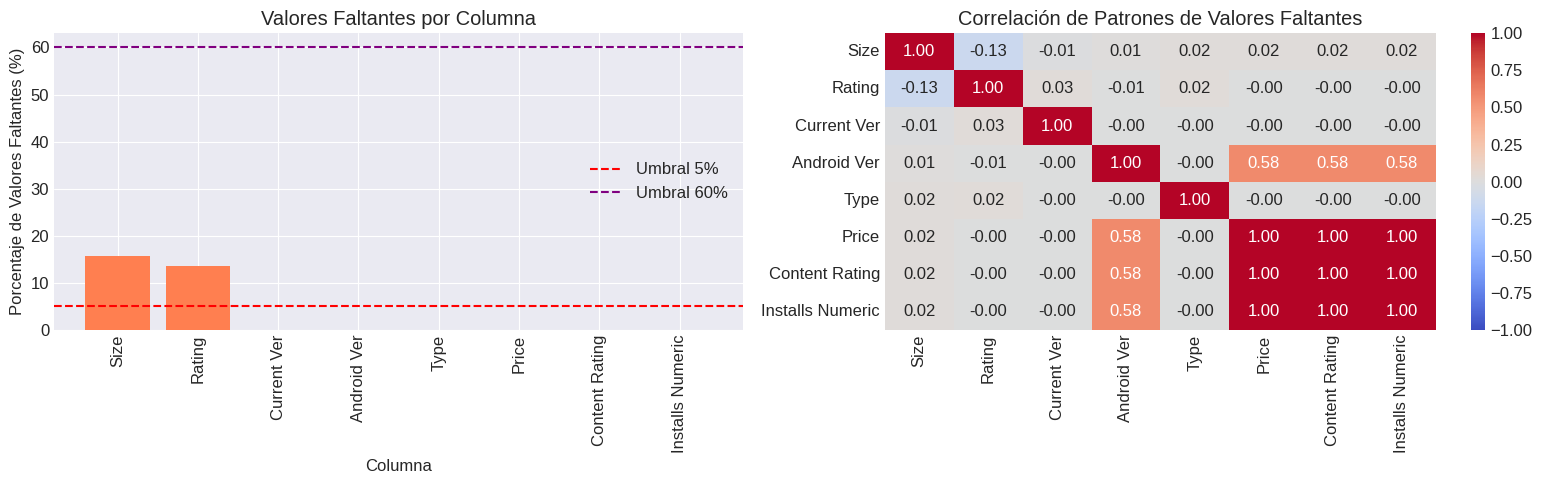

,Columna,Valores_Faltantes,Porcentaje,Tipo_Dato
4,Size,1696,15.64,float64
2,Rating,1474,13.60,float64
11,Current Ver,8,0.07,object
12,Android Ver,3,0.03,object
6,Type,1,0.01,object
7,Price,1,0.01,float64
8,Content Rating,1,0.01,object
13,Installs Numeric,1,0.01,float64


In [6]:
def analyze_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Análisis completo de valores faltantes con visualizaciones."""
    missing_counts = df.isnull().sum()
    missing_pct = (missing_counts / len(df)) * 100

    missing_df = pd.DataFrame({
        'Columna': df.columns,
        'Valores_Faltantes': missing_counts.values,
        'Porcentaje': missing_pct.values,
        'Tipo_Dato': df.dtypes.values
    })

    missing_df = missing_df[missing_df['Valores_Faltantes'] > 0].sort_values('Porcentaje', ascending=False)

    if len(missing_df) == 0:
        print("No hay valores faltantes en el dataset")
        return missing_df

    # Visualización: barras y correlación de patrones de faltantes
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Gráfico de barras de % faltantes
    ax1.bar(missing_df['Columna'], missing_df['Porcentaje'], color='coral')
    ax1.set_xlabel('Columna')
    ax1.set_ylabel('Porcentaje de Valores Faltantes (%)')
    ax1.set_title('Valores Faltantes por Columna')
    ax1.axhline(y=5, color='r', linestyle='--', label='Umbral 5%')
    ax1.axhline(y=60, color='purple', linestyle='--', label='Umbral 60%')
    ax1.tick_params(axis='x', rotation=90)
    ax1.legend()

    # Heatmap de correlación de patrones de faltantes
    mask_df = df[missing_df['Columna'].tolist()].isnull().astype(int)
    if mask_df.shape[1] >= 2:
        corr = mask_df.corr()
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax2)
        ax2.set_title('Correlación de Patrones de Valores Faltantes')
    else:
        ax2.axis('off')
        ax2.set_title('Correlación de faltantes (no aplica: 1 columna)')

    plt.tight_layout()
    plt.show()

    return missing_df

missing_analysis = analyze_missing_values(applications_data)
if missing_analysis is not None and not missing_analysis.empty:
    display(missing_analysis)

## Estadisticas descriptivas y univariadas (númerico)
A partir de la tabla de estadísticas y los gráficos generados para `Rating`, `Reviews`, `Size`, `Price` e `Installs Numeric`, se observan los siguientes puntos clave.

- Rating
  - Media ≈ 4.19 y mediana ≈ 4.30 → ligera cola a la izquierda (más apps con rating alto). Hay un valor imposible (≈19), confirmado en el boxplot/Q-Q como outlier extremo.
  - Outliers: ~5% por IQR, dominados por el valor inválido y algunos ratings bajos.
  - Q-Q plot: desviación frente a normalidad, esperable para una variable acotada [1,5].
  - Implicación/acción: eliminar filas sin `Rating` para modelado; corregir `Rating=19 → NaN` y excluir; no aplicar transformaciones (la escala es ya interpretables).

- Reviews
  - Media ≫ mediana (pico en 0–pocos miles; máximo ≈ 78M) → cola muy larga a la derecha.
  - Boxplot: ~18% outliers por IQR (muchas apps con reseñas muy altas).
  - Q-Q plot: gran desviación de normalidad (heavy tail).
  - Relación con Rating: correlación positiva muy débil (~0.07), tendencia casi plana.
  - Implicación/acción: usar `log1p(Reviews)` para estabilizar la distribución en análisis/modelado; considerar winsorizar p99.9 para vistas tabulares si se desea.

- Size (MB)
  - Media > mediana (≈ 21.5 vs 13) → sesgo a la derecha; valores hasta 100 MB.
  - ~6% outliers por IQR, especialmente en colas altas.
  - Q-Q plot: curvatura en colas; no normal.
  - Relación con Rating: correlación positiva débil (~0.08); señal muy tenue.
  - Implicación/acción: imputar faltantes por `Category × Type` y añadir `size_missing`; opcionalmente probar `log1p(Size)` o binning para robustecer.

- Price (USD)
  - Mediana = 0 (mayoría gratis) y cola a la derecha con máximos altos (≈ 400).
  - ~7% outliers por IQR; Q-Q muestra heavy tail.
  - Relación con Rating: correlación negativa muy débil (~-0.02).
  - Implicación/acción: crear `is_free = (Price == 0)` y, si se usa `Price` continuo, considerar `log1p(Price)` para las pocas apps pagas; validar coherencia `Type=Free ⇒ Price=0`.

- Installs Numeric
  - Media ≫ mediana (100k) con máximo 1e9 → distribución extremadamente sesgada a la derecha.
  - ~7–8% outliers por IQR; Q-Q muy alejado de normalidad.
  - Relación con Rating: correlación débil positiva (~0.05) y tendencia casi plana.
  - Implicación/acción: usar `log1p(Installs Numeric)` o bins ordinales para análisis; verificar coherencia con `Installs` textual.

Recomendaciones transversales
- Eliminar duplicados antes de resumir para evitar sesgos.
- Tratar outliers evidentes no-legítimos (p. ej. `Rating=19`). Para colas largas legítimas (`Reviews`, `Installs Numeric`, `Price`): preferir `log1p` o winsorización solo para visualizaciones.
- Mantener consistencia: `Type=Free ⇒ Price=0`; `Installs Numeric` coherente con el rango de `Installs`.
- Para relaciones con `Rating`, las correlaciones lineales observadas son débiles; la señal puede emerger mejor con interacciones (p. ej., `is_free × installs_bin`) o modelos no lineales.



,count,mean,std,min,25%,50%,75%,max,mad,skew,kurtosis,cv
Rating,9367.00,4.19,0.54,1.00,4.00,4.30,4.50,19.00,0.20,0.60,66.00,0.13
Reviews,10841.00,444111.93,2927628.66,0.00,38.00,2094.00,54768.00,78158306.00,2094.00,16.45,341.09,6.59
Size,9145.00,21.52,22.59,0.01,4.90,13.00,30.00,100.00,9.70,1.56,1.92,1.05
Price,10840.00,1.03,15.95,0.00,0.00,0.00,0.00,400.00,0.00,23.71,578.14,15.53
Installs Numeric,10840.00,15464338.88,85029361.39,0.00,1000.00,100000.00,5000000.00,1000000000.00,99990.00,9.57,100.28,5.50


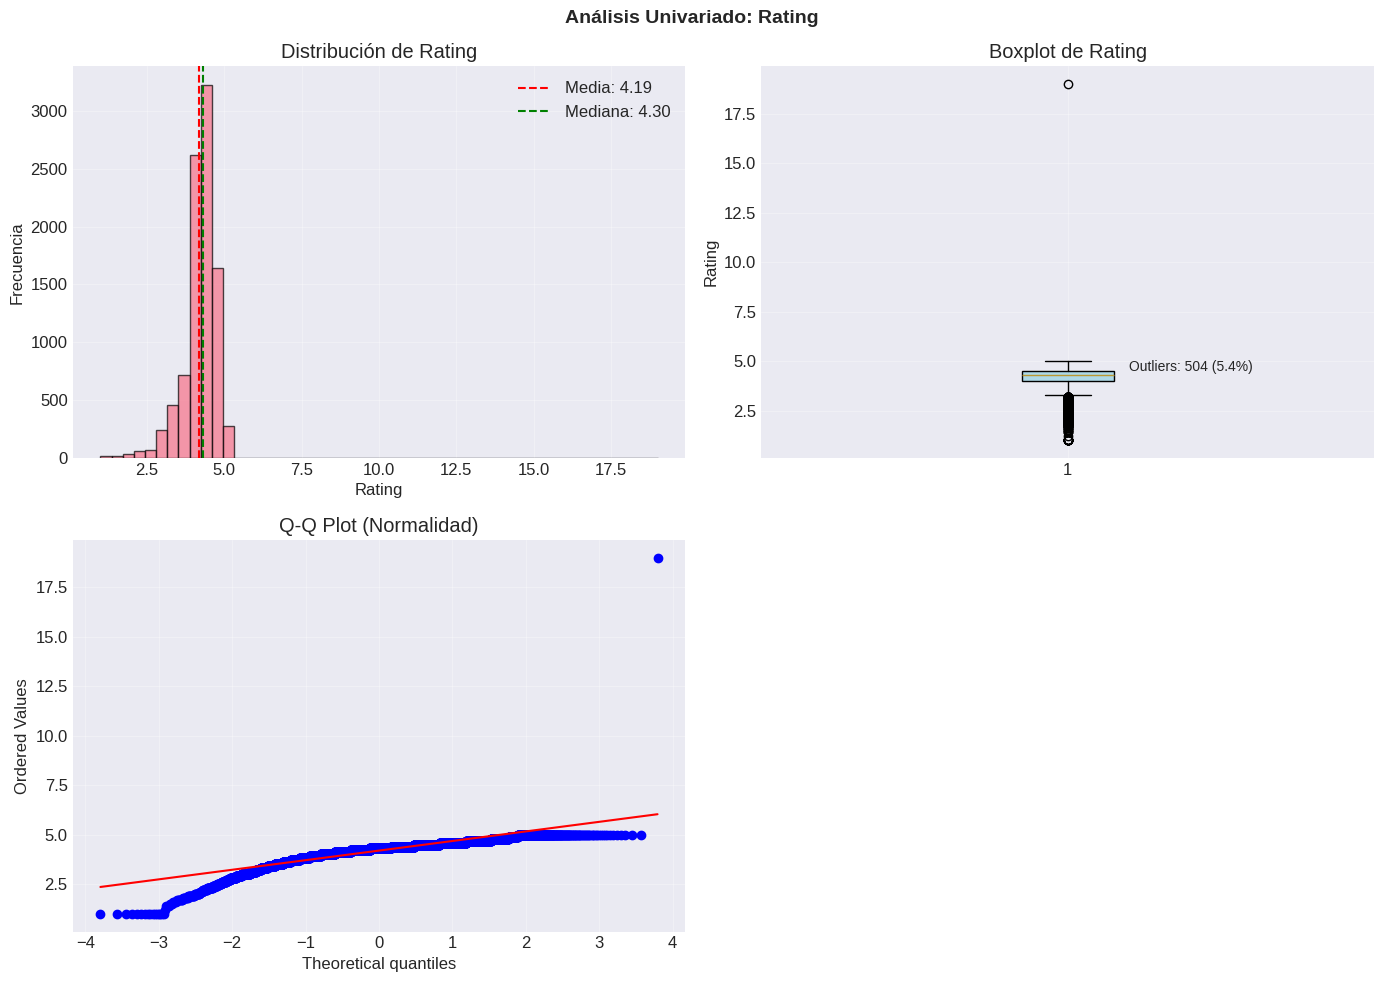

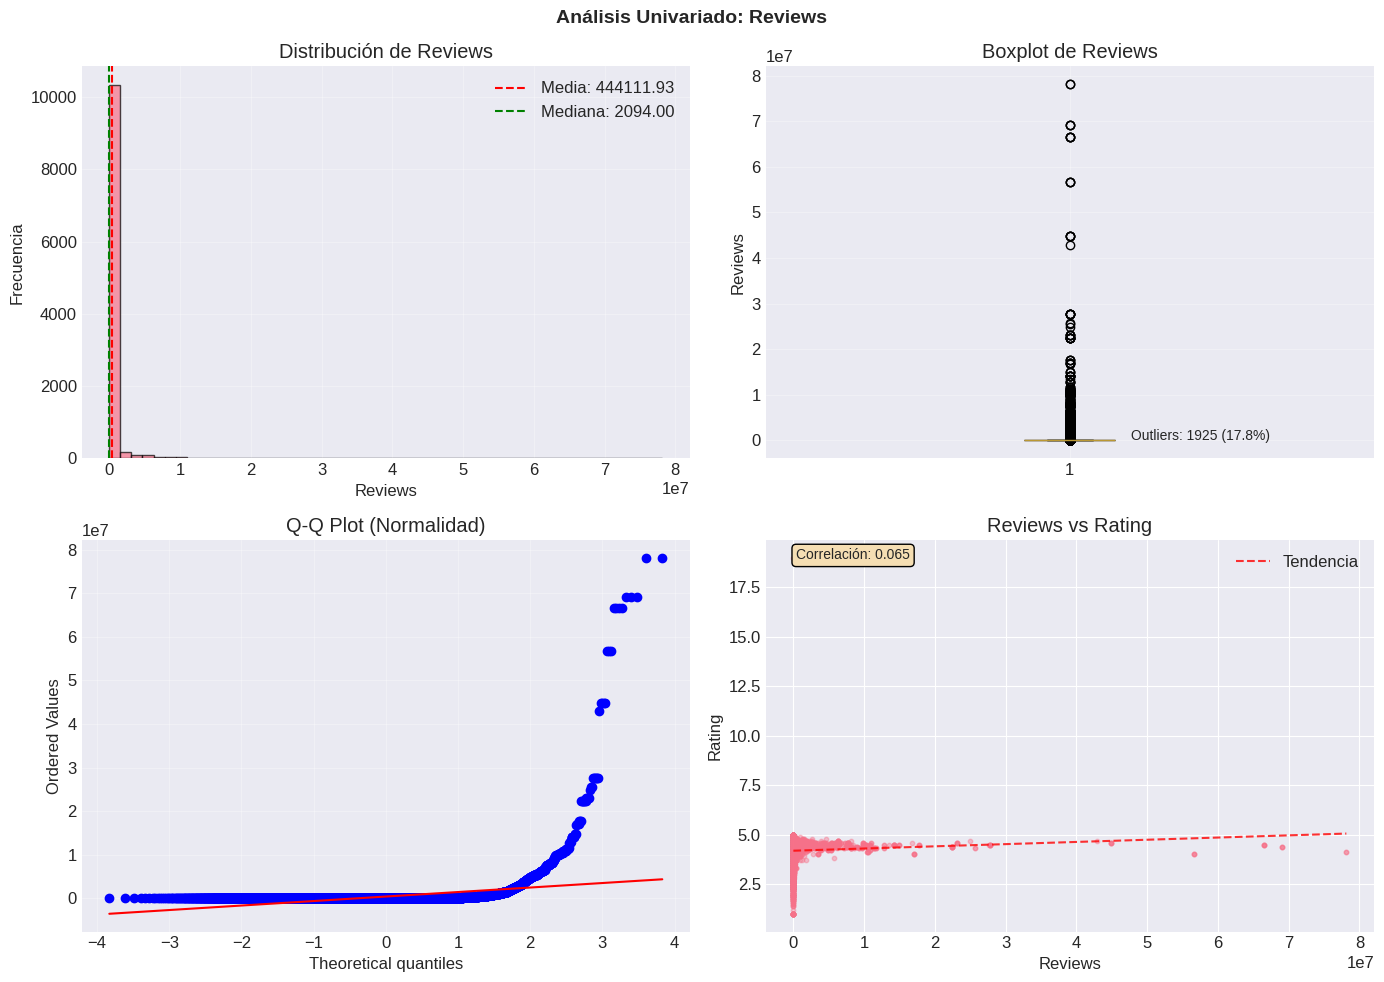

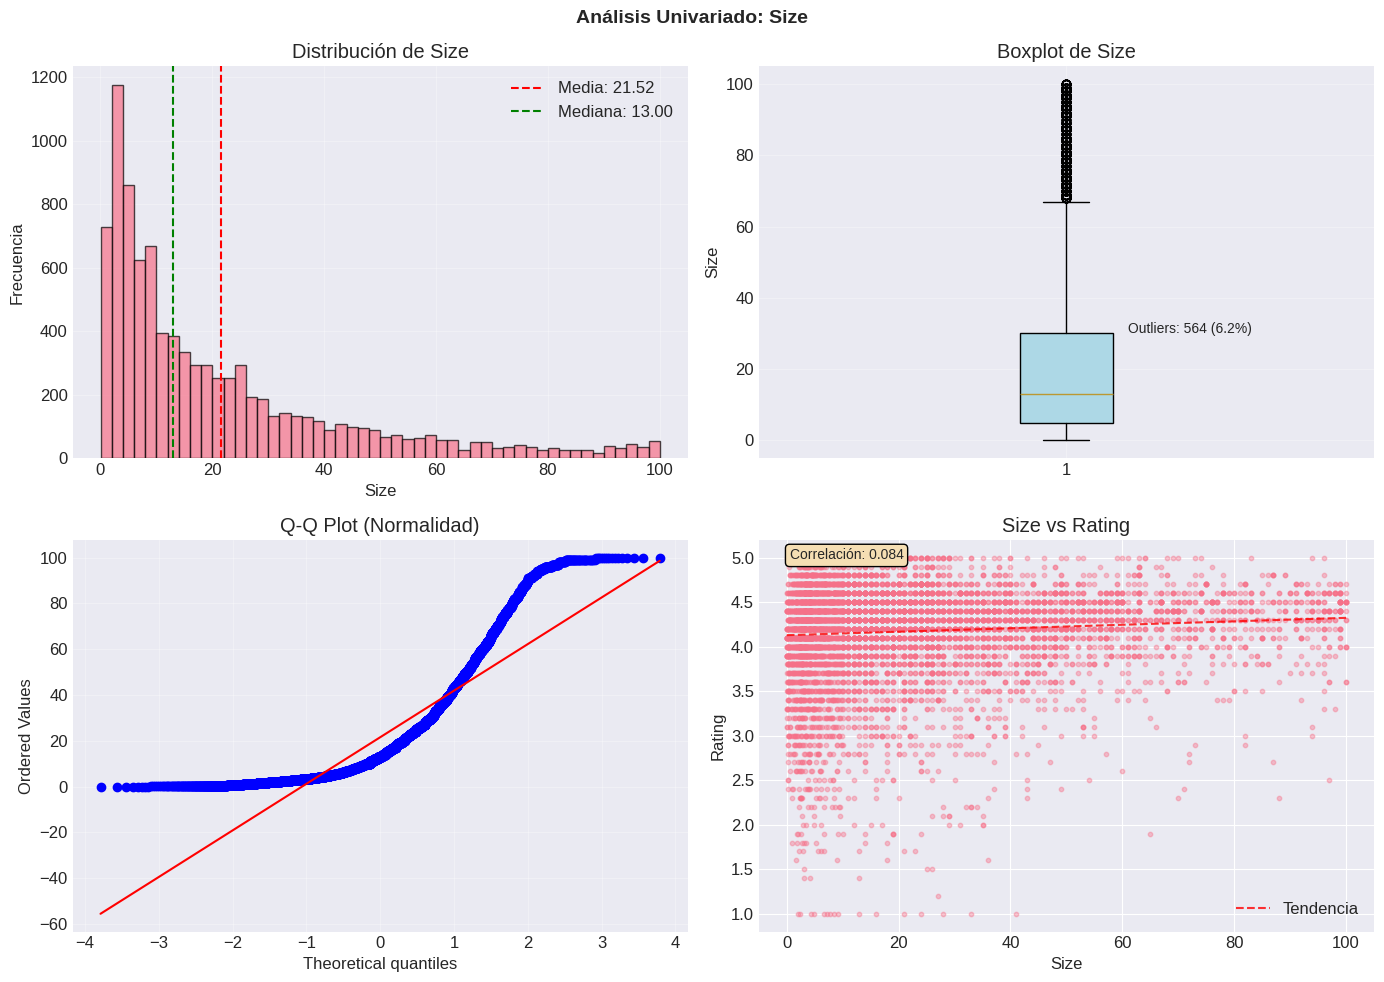

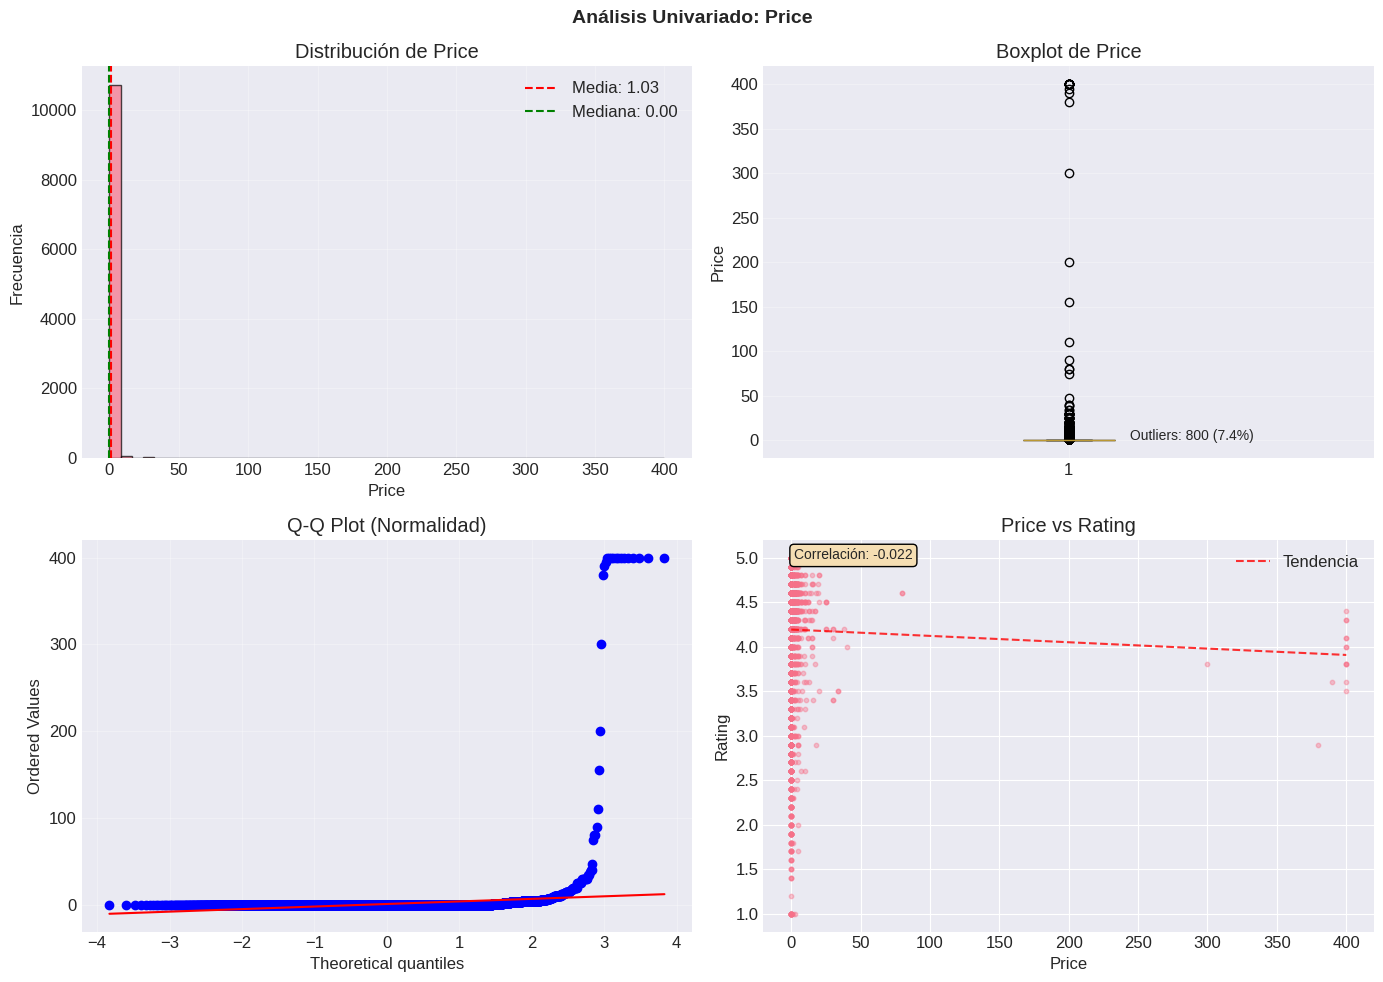

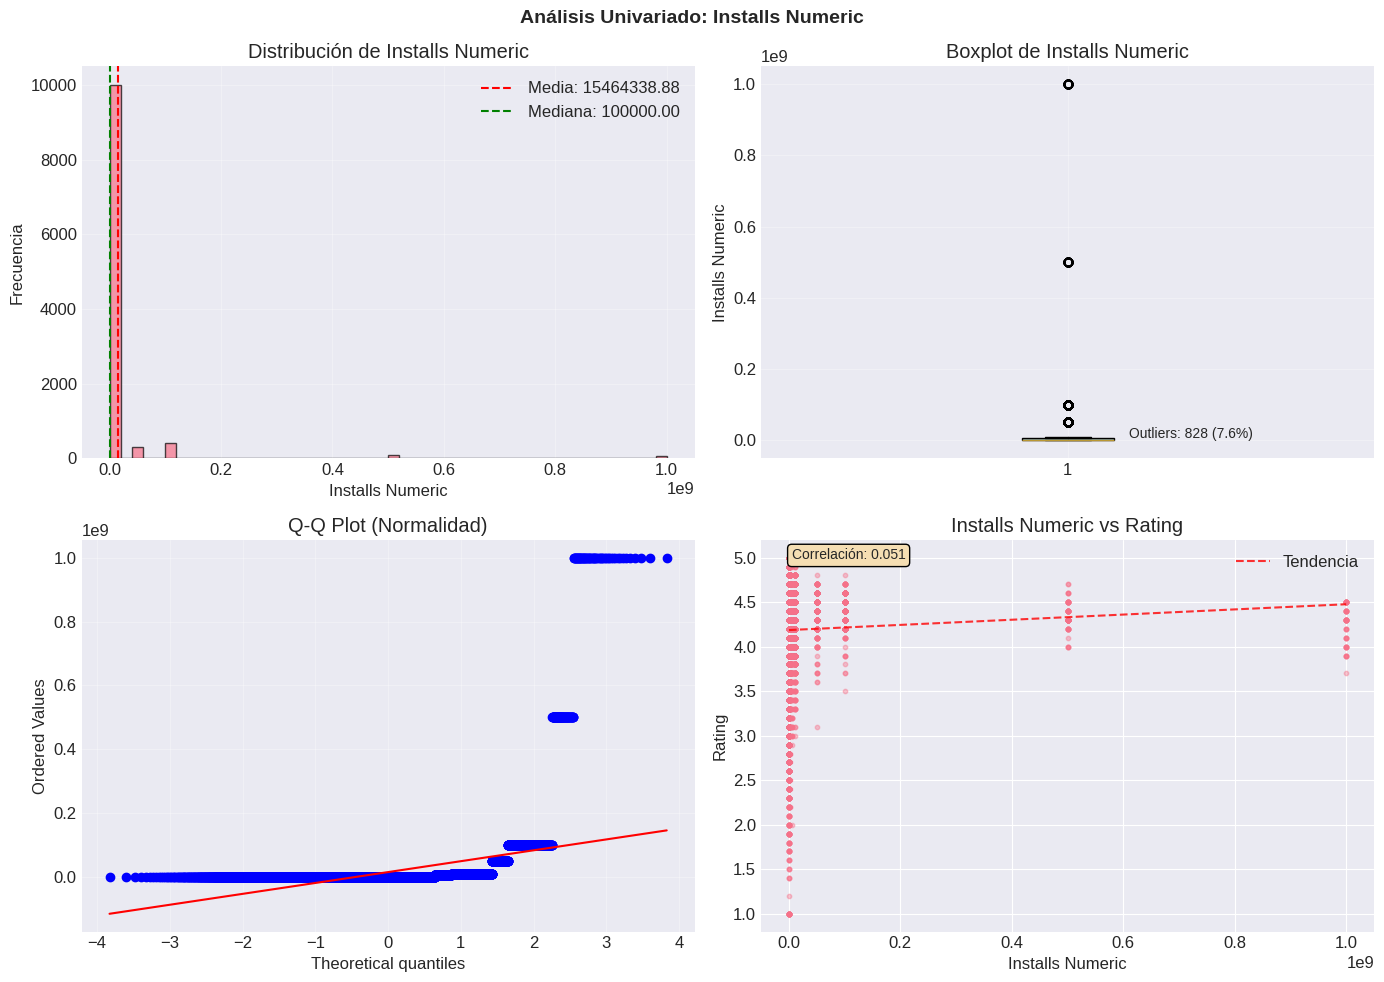

In [7]:
from scipy import stats

# Selección de columnas numéricas relevantes
numeric_cols = [c for c in ['Rating', 'Reviews', 'Size', 'Price', 'Installs Numeric'] if c in applications_data.columns]

# Tabla de estadísticas básicas (media, mediana, std, min, p25, p50, p75, max)
describe_tbl = applications_data[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75]).T

# Métricas adicionales robustas
extra = pd.DataFrame(index=numeric_cols)
extra['mad'] = [stats.median_abs_deviation(applications_data[c].dropna()) for c in numeric_cols]
extra['skew'] = [applications_data[c].skew(skipna=True) for c in numeric_cols]
extra['kurtosis'] = [applications_data[c].kurtosis(skipna=True) for c in numeric_cols]
extra['cv'] = [applications_data[c].std(skipna=True) / applications_data[c].mean(skipna=True) if applications_data[c].mean(skipna=True) not in [0, np.nan] else np.nan for c in numeric_cols]

stats_table = describe_tbl.join(extra)
display(stats_table.round(3))


def univariate_analysis(df: pd.DataFrame, column: str, target: str | None = None):
    """Análisis univariado con histograma, boxplot, Q-Q plot y relación con target."""
    series = df[column].dropna()
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1) Histograma con líneas de media y mediana
    ax1 = axes[0, 0]
    ax1.hist(series, bins=50, edgecolor='black', alpha=0.7)
    ax1.axvline(series.mean(), color='red', linestyle='--', label=f"Media: {series.mean():.2f}")
    ax1.axvline(series.median(), color='green', linestyle='--', label=f"Mediana: {series.median():.2f}")
    ax1.set_title(f"Distribución de {column}")
    ax1.set_xlabel(column)
    ax1.set_ylabel('Frecuencia')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # 2) Boxplot + conteo de outliers (IQR)
    ax2 = axes[0, 1]
    bp = ax2.boxplot(series, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    outliers_mask = (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)
    n_out = int(outliers_mask.sum())
    pct_out = 100 * n_out / len(series) if len(series) else 0
    ax2.set_title(f"Boxplot de {column}")
    ax2.set_ylabel(column)
    ax2.grid(alpha=0.3)
    ax2.text(1.1, Q3, f"Outliers: {n_out} ({pct_out:.1f}%)", fontsize=10)

    # 3) Q-Q plot normal
    ax3 = axes[1, 0]
    stats.probplot(series, dist='norm', plot=ax3)
    ax3.set_title('Q-Q Plot (Normalidad)')
    ax3.grid(alpha=0.3)

    # 4) Relación con target si aplica
    ax4 = axes[1, 1]
    if target is not None and target in df.columns and column != target:
        valid = df[[column, target]].dropna()
        ax4.scatter(valid[column], valid[target], alpha=0.4, s=10)
        ax4.set_xlabel(column)
        ax4.set_ylabel(target)
        ax4.set_title(f"{column} vs {target}")
        # Línea de tendencia (ajuste lineal simple)
        if len(valid) > 1:
            z = np.polyfit(valid[column], valid[target], 1)
            p = np.poly1d(z)
            xs = np.linspace(valid[column].min(), valid[column].max(), 200)
            ax4.plot(xs, p(xs), 'r--', alpha=0.8, label='Tendencia')
            corr = valid[column].corr(valid[target])
            ax4.text(0.05, 0.95, f"Correlación: {corr:.3f}", transform=ax4.transAxes,
                     fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))
            ax4.legend()
    else:
        ax4.axis('off')
        ax4.grid(alpha=0.3)

    plt.suptitle(f"Análisis Univariado: {column}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Ejecutar análisis univariado para cada métrica numérica, relacionando con Rating
for col in numeric_cols:
    univariate_analysis(applications_data, col, target='Rating')

## Análisis Univariado Categórico
- Category
  - Distribución: alta concentración en `FAMILY` (~19%) y `GAME` (~12%). El resto de categorías tienen menor peso individual; el grupo `Others` acumula ~31% del total.
  - Rating por categoría: diferencias moderadas; la **mediana** suele estar entre 4.2–4.4. Algunas categorías muestran desviación estándar mayor (p. ej., `PRODUCTIVITY`, `LIFESTYLE`), indicando más variabilidad de valoración.
  - Implicaciones: riesgo de sesgo por categorías mayoritarias en análisis agregados. Para modelado, conviene usar dummies Top-K o codificación ordinal/target encoding con cuidado (evitar fuga). Agrupar colas largas en `Others` es adecuado para visualización.

- Content Rating
  - Distribución: `Everyone` domina (~79%), seguido por `Teen` (~12%); `Mature 17+` y `Everyone 10+` suman ~9% en conjunto; clases raras casi nulas.
  - Rating por nivel de contenido: medias similares (≈4.1–4.3). `Teen` tiende a mediana 4.3 y variabilidad algo menor; `Mature 17+` muestra algo más de dispersión.
  - Implicaciones: por el fuerte desbalance, esta variable aporta señal limitada por sí sola. Útil como interacción con `Category`/`Genres`.

- Type
  - Distribución: `Free` ≈ 93%, `Paid` ≈ 7% (clase muy desbalanceada); existe un registro anómalo (valor 0) en los gráficos que debe eliminarse/corregirse.
  - Rating por tipo: medias muy cercanas (Free ≈ 4.19, Paid ≈ 4.27). La diferencia es pequeña y probablemente no significativa sin controlar otras variables (p. ej., `Category`).
  - Implicaciones: por el desbalance extremo, conviene usar `is_free` como binaria y, si se modela interacción con `Installs` o `Price`, puede emerger señal. Validar regla `Type=Free ⇒ Price=0`.

- Genres Main (primer género)
  - Distribución: gran cola larga; `Others` concentra ~48%. Entre Top-12, `Tools`, `Entertainment` y `Education` destacan en frecuencia.
  - Rating por género: diferencias pequeñas (medianas ~4.2–4.4), con algunas variaciones en dispersión (p. ej., `Medical` y `Lifestyle` más variables).
  - Implicaciones: por la alta cardinalidad y colas largas, mantener Top-K + `Others` en EDA ayuda a la legibilidad. Para modelado, preferir codificación que reduzca dimensionalidad (Top-K dummies, hashing, o target encoding con validación adecuada).

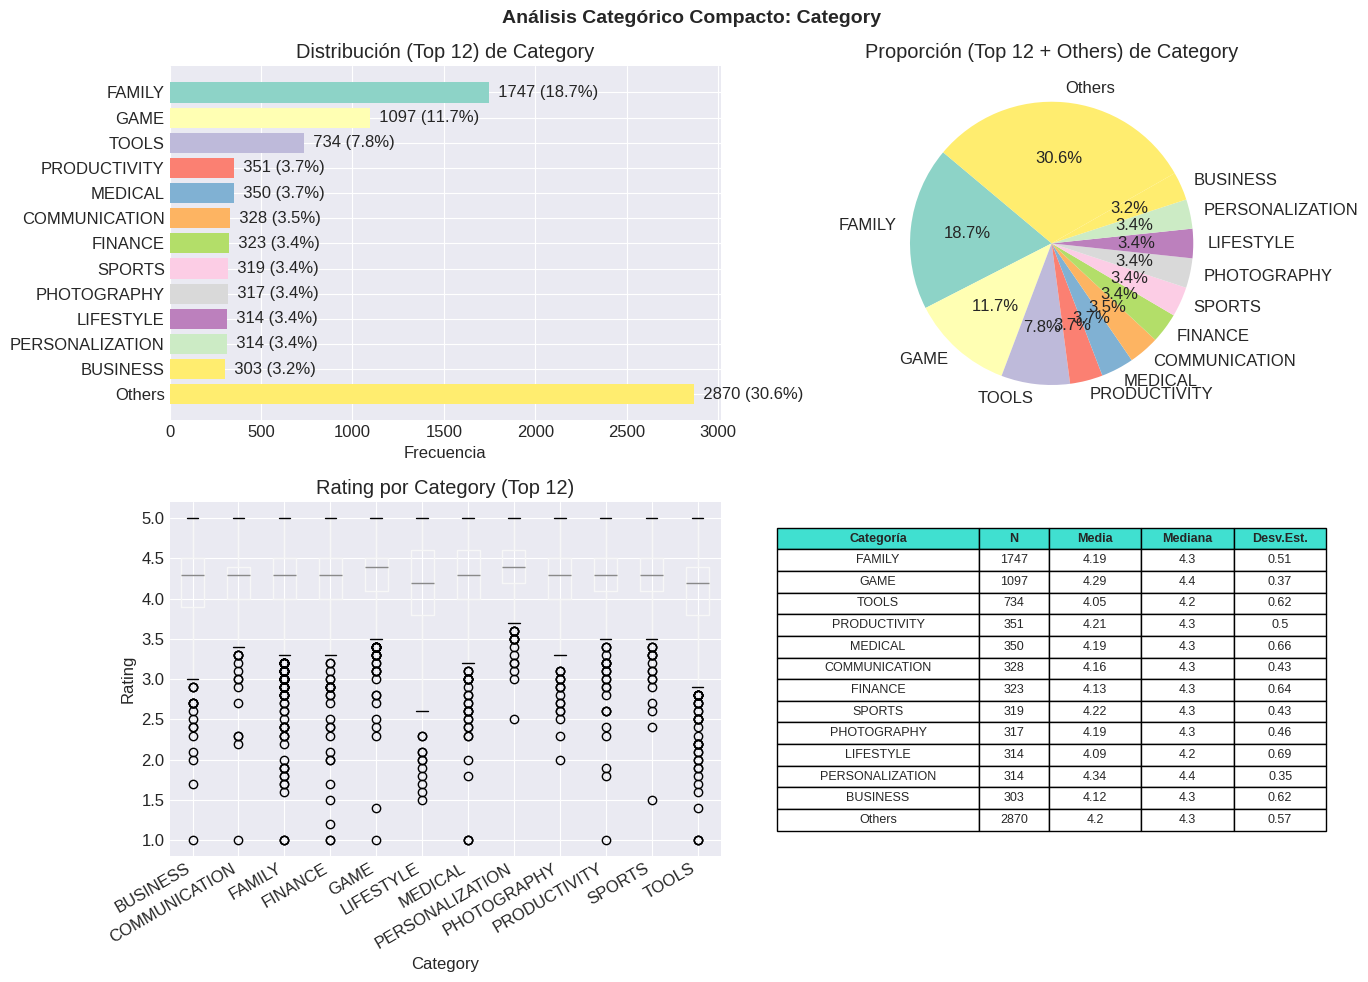

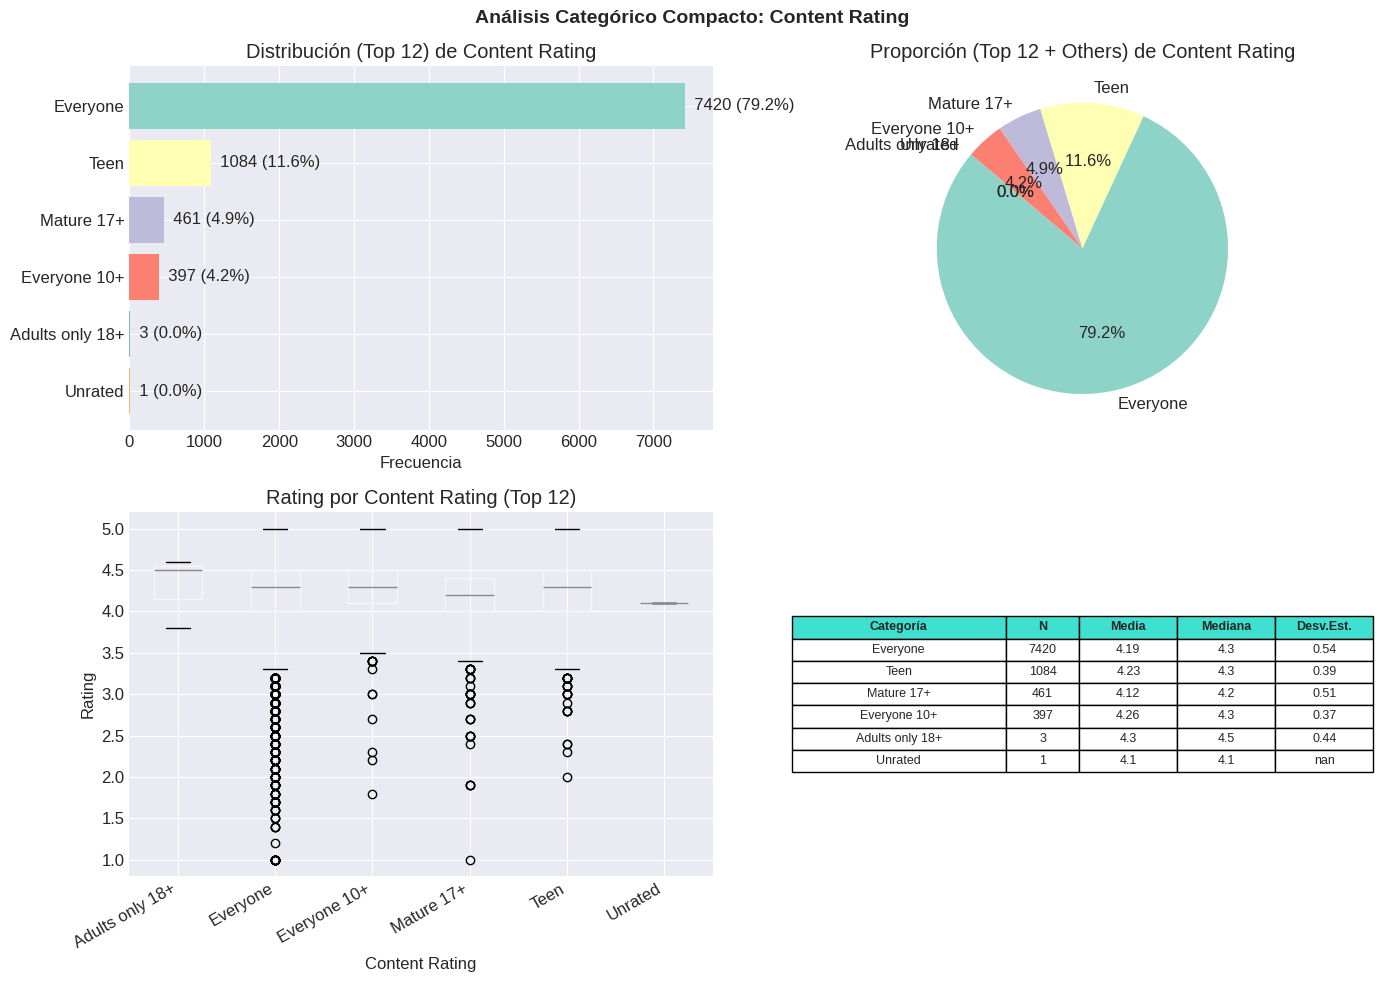

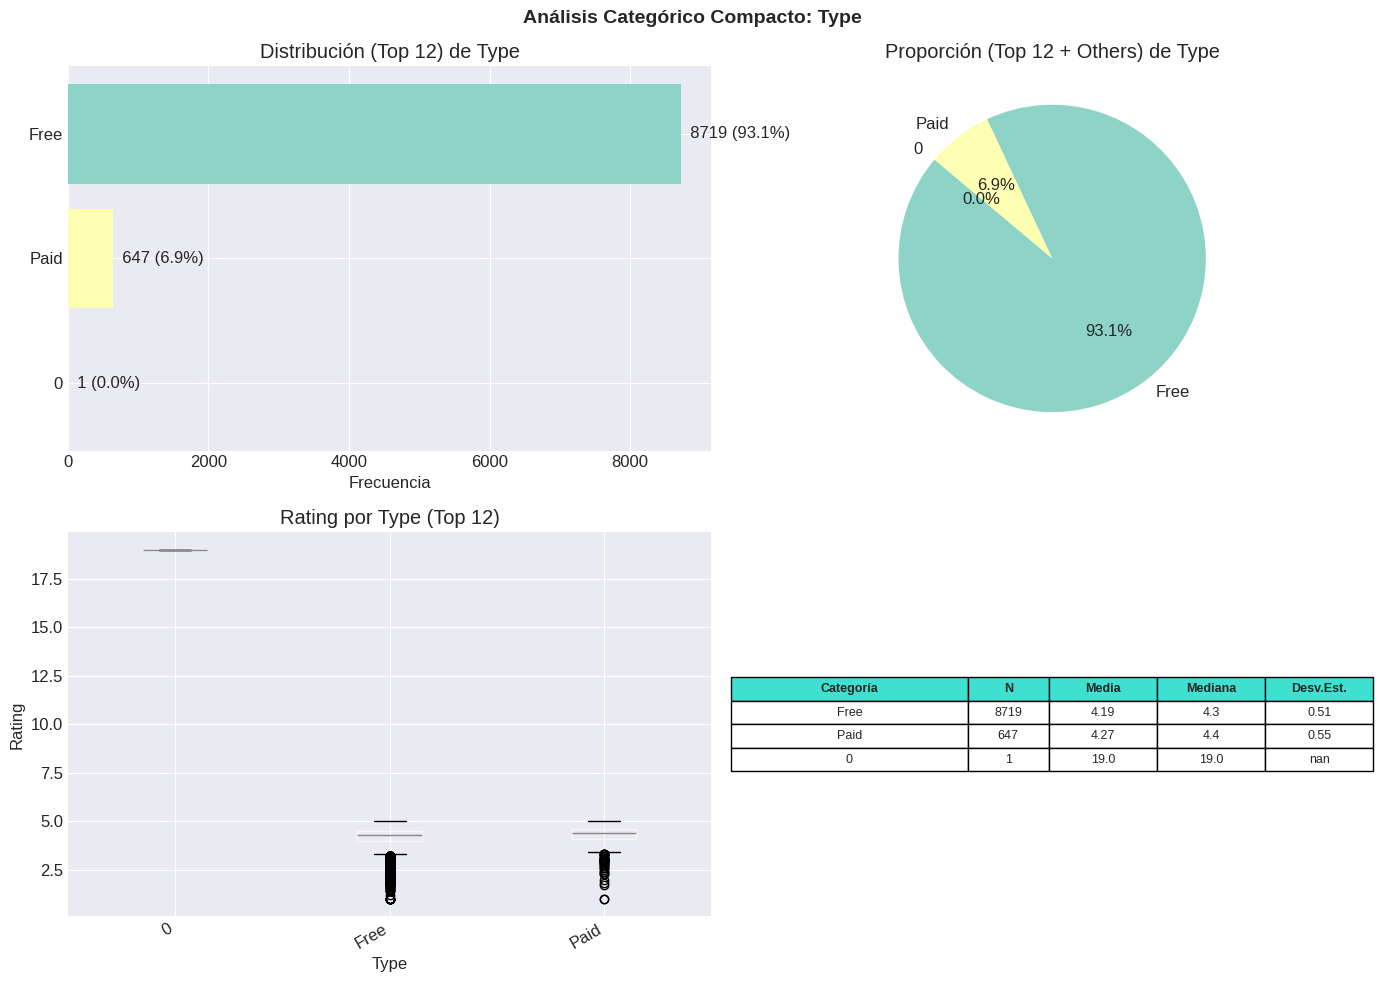

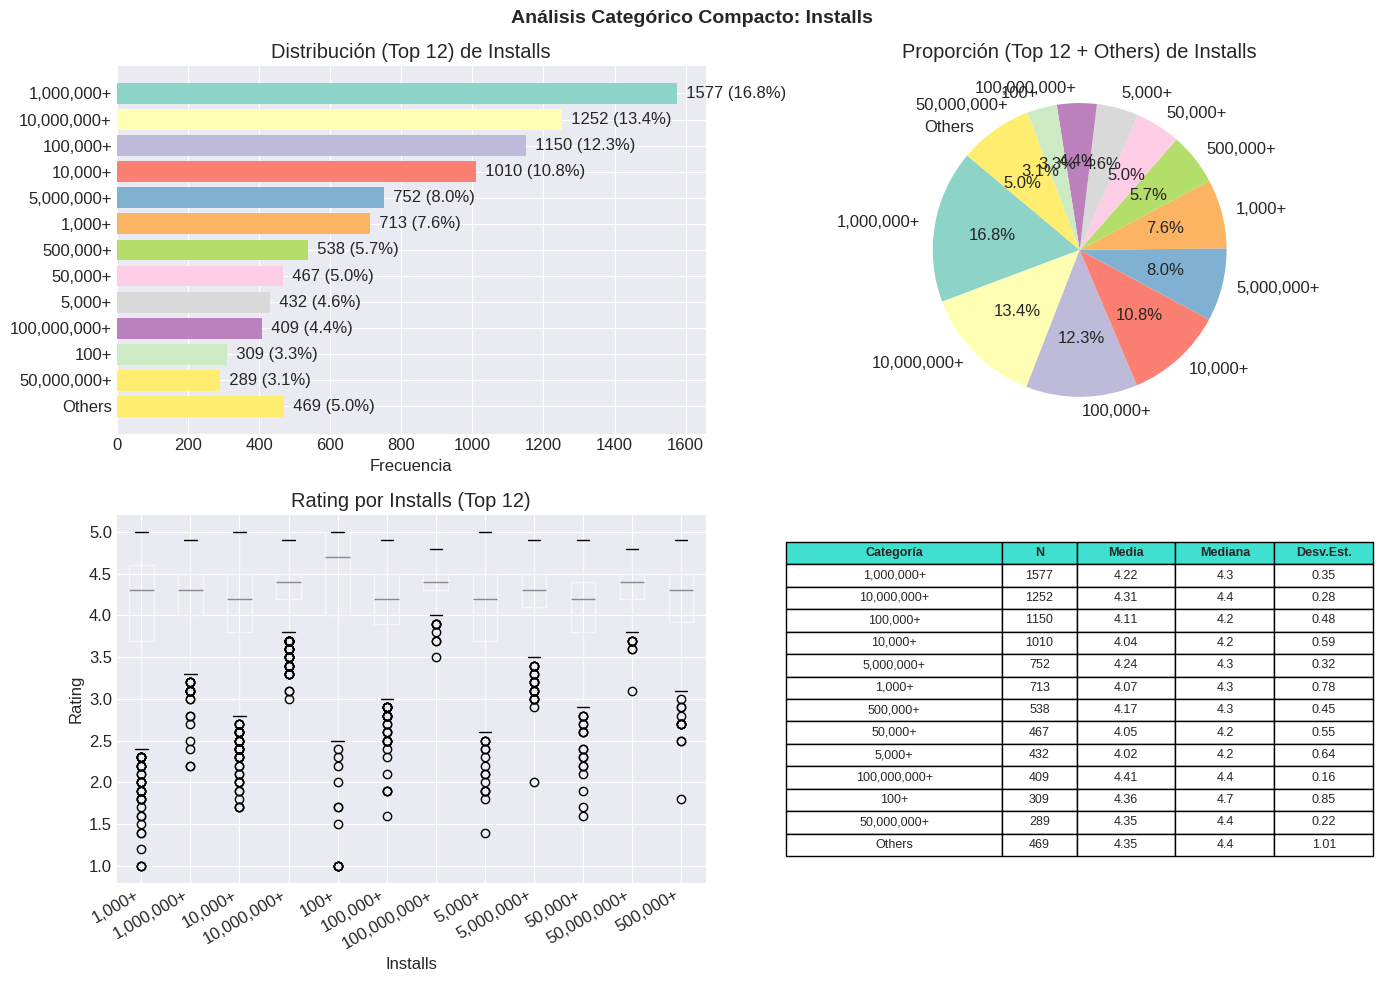

In [8]:
def analyze_categorical_compact(df: pd.DataFrame, cat_col: str, target_col: str, top_n: int = 12):
    """
    Versión compacta para variables con muchas categorías:
    - Ordena por frecuencia, muestra top_n y agrupa el resto en "Others".
    - Barras horizontales, pie chart compacto, boxplot y tabla para top_n.
    """
    data = df[[cat_col, target_col]].dropna(subset=[cat_col, target_col]).copy()
    if data.empty:
        print(f"Sin datos para {cat_col} y {target_col}")
        return

    counts = data[cat_col].value_counts()
    top_cats = counts.head(top_n)
    others_count = counts.iloc[top_n:].sum()

    # Mapeo a top_n + Others
    mapping = {c: c for c in top_cats.index}
    data['__cat__'] = data[cat_col].where(data[cat_col].isin(top_cats.index), other='Others')

    # Recalcular conteos con Others
    counts_compact = data['__cat__'].value_counts()
    order = list(top_cats.index) + (['Others'] if 'Others' in counts_compact.index else [])

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1) Barras horizontales (mejor legibilidad)
    ax1 = axes[0, 0]
    vals = counts_compact.loc[order]
    ax1.barh(range(len(vals)), vals.values, color=plt.cm.Set3(range(len(vals))))
    ax1.set_yticks(range(len(vals)))
    ax1.set_yticklabels(order)
    ax1.invert_yaxis()
    ax1.set_title(f'Distribución (Top {top_n}) de {cat_col}')
    ax1.set_xlabel('Frecuencia')
    for i, v in enumerate(vals.values):
        ax1.text(v, i, f'  {v} ({v/len(data)*100:.1f}%)', va='center')

    # 2) Pie chart compacto
    ax2 = axes[0, 1]
    ax2.pie(vals.values, labels=order, autopct='%1.1f%%', startangle=140,
            colors=plt.cm.Set3(range(len(vals))))
    ax2.set_title(f'Proporción (Top {top_n} + Others) de {cat_col}')

    # 3) Boxplot del target por categoría (solo top_n)
    ax3 = axes[1, 0]
    top_mask = data['__cat__'] != 'Others'
    data_top = data[top_mask]
    data_top.boxplot(column=target_col, by='__cat__', ax=ax3)
    ax3.set_title(f'{target_col} por {cat_col} (Top {top_n})')
    ax3.set_xlabel(cat_col)
    ax3.set_ylabel(target_col)
    plt.sca(ax3)
    plt.xticks(rotation=30, ha='right')

    # 4) Tabla de estadísticas por categoría (solo top_n y Others si existe)
    ax4 = axes[1, 1]
    ax4.axis('off')
    stats_by_cat = data.groupby('__cat__')[target_col].agg(['count', 'mean', 'median', 'std']).loc[order].round(2)
    table = ax4.table(cellText=stats_by_cat.reset_index().values,
                      colLabels=['Categoría', 'N', 'Media', 'Mediana', 'Desv.Est.'],
                      cellLoc='center', loc='center', colWidths=[0.35, 0.12, 0.16, 0.16, 0.16])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.05, 1.25)
    for i in range(5):
        table[(0, i)].set_facecolor('#40E0D0')
        table[(0, i)].set_text_props(weight='bold')

    plt.suptitle(f'Análisis Categórico Compacto: {cat_col}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Ejecutar la versión compacta para las categóricas clave
for cat in [c for c in ['Category', 'Content Rating', 'Type', 'Genres Main', 'Installs'] if c in applications_data.columns]:
    analyze_categorical_compact(applications_data, cat, 'Rating', top_n=12)

## Análisis de correlación entre variables

### Variables con Mayor Relación
- Existe una fuerte correlación positiva entre **Installs Numeric** y **Reviews**:
  - Pearson: 0.64 (relación lineal moderada-fuerte).
  - Spearman: 0.97 (relación monótonica muy fuerte).
- Esto implica que a mayor número de instalaciones, mayor número de reseñas.

### Correlación de Pearson
- En general, las correlaciones de Pearson muestran relaciones más débiles que Spearman, lo cual indica que las relaciones lineales no son tan marcadas.
- **Installs Numeric y Reviews** presentan la correlación lineal más alta (0.64), siendo moderada-fuerte.
- **Size y Reviews** muestran una correlación positiva baja/Débil (0.24).
- El resto de variables (Rating, Price) tienen correlaciones casi nulas con las demás, lo que refleja poca relación lineal.

### Correlación de Spearman
- **Installs Numeric y Reviews** tienen la correlación más fuerte (0.97).
- **Size** muestra correlación moderada con **Reviews** (0.37) y con **Installs Numeric** (0.35).
- **Price** presenta correlaciones negativas con **Reviews** (-0.17) e **Installs Numeric** (-0.24).

### Observaciones Clave
- El número de instalaciones y las reseñas son las variables más relacionadas, lo cual es lógico, ya que más usuarios generan más interacciones.
- El tamaño de la aplicación influye ligeramente en reseñas e instalaciones, pero no de forma determinante.
- El precio no solo carece de relación positiva, sino que parece tener un impacto negativo sobre la popularidad (menos instalaciones y reseñas).

### Conclusión
- **Installs Numeric** y **Reviews** son las métricas más críticas en el dataset de **Google Play Store**, ya que reflejan el éxito y la popularidad de la aplicación.
- **Size** es un factor secundario con cierta relación.

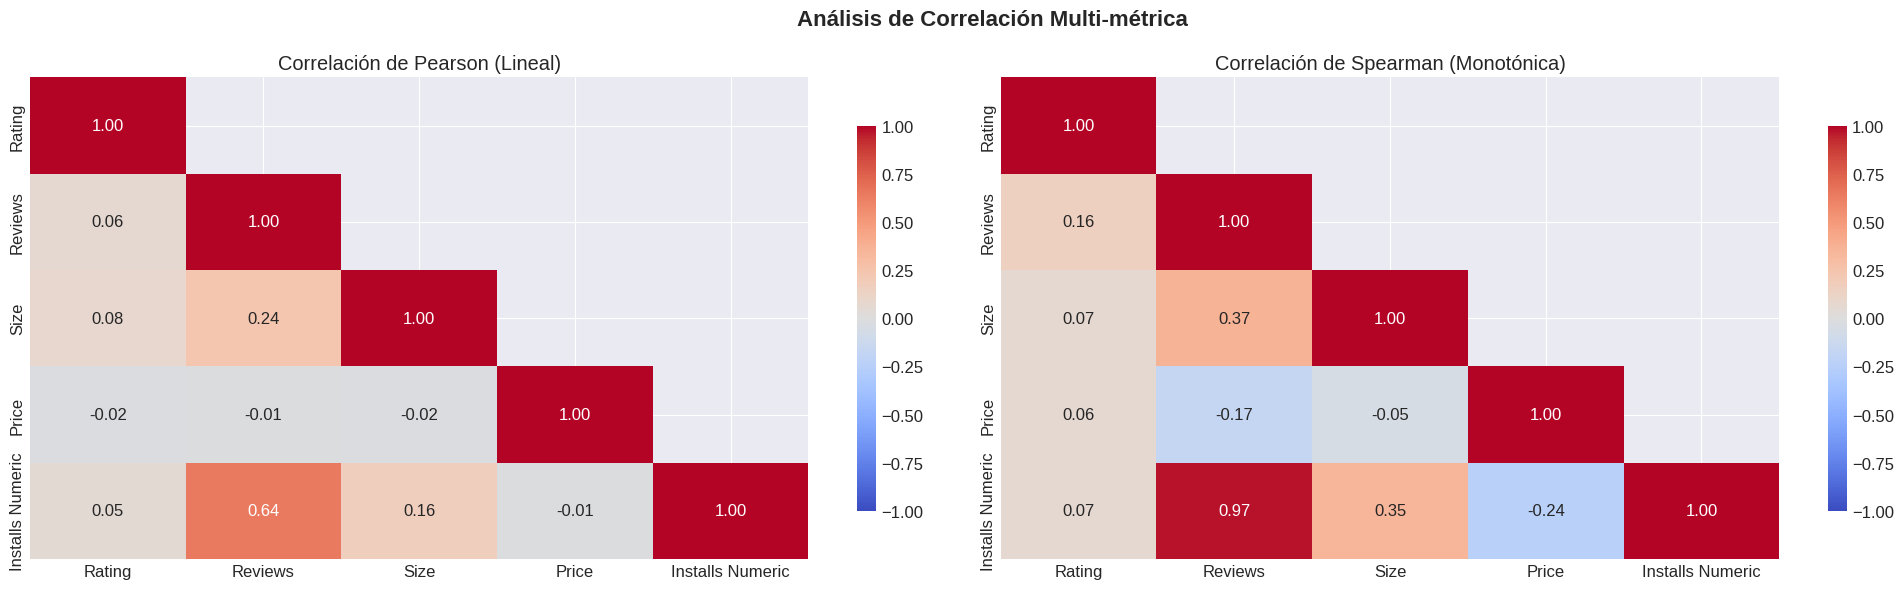


Correlaciones Significativas:

Pearson:
  • Reviews y Installs Numeric: +0.643 (Fuerte Positiva)
  • Installs Numeric y Reviews: +0.643 (Fuerte Positiva)

Spearman:
  • Reviews y Size: +0.367 (Moderada Positiva)
  • Reviews y Installs Numeric: +0.971 (Fuerte Positiva)
  • Size y Reviews: +0.367 (Moderada Positiva)
  • Size y Installs Numeric: +0.348 (Moderada Positiva)
  • Installs Numeric y Reviews: +0.971 (Fuerte Positiva)
  • Installs Numeric y Size: +0.348 (Moderada Positiva)


In [10]:
# Análisis de correlación mejorado para el proyecto de Google Play Store
def correlation_analysis(df):
    """Análisis de correlación con múltiples métricas"""
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    
    # 1. Correlación de Pearson
    corr_pearson = df[numeric_cols].corr(method='pearson')
    mask = np.triu(np.ones_like(corr_pearson), k=1)
    sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f', 
               cmap='coolwarm', center=0, ax=axes[0],
               vmin=-1, vmax=1, cbar_kws={"shrink": 0.8})
    axes[0].set_title('Correlación de Pearson (Lineal)')
    
    # 2. Correlación de Spearman  
    corr_spearman = df[numeric_cols].corr(method='spearman')
    sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f',
               cmap='coolwarm', center=0, ax=axes[1],
               vmin=-1, vmax=1, cbar_kws={"shrink": 0.8})
    axes[1].set_title('Correlación de Spearman (Monotónica)')
    
    plt.suptitle('Análisis de Correlación Multi-métrica', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Tabla de correlaciones importantes
    print("\nCorrelaciones Significativas:")
    print("=" * 50)
    for method, corr_matrix in zip(['Pearson', 'Spearman'], [corr_pearson, corr_spearman]):
        print(f"\n{method}:")
        significant_corr = corr_matrix[(abs(corr_matrix) > 0.3) & (corr_matrix != 1)].stack()
        for (var1, var2), corr in significant_corr.items():
            strength = "Fuerte" if abs(corr) > 0.5 else "Moderada" if abs(corr) > 0.3 else "Débil"
            direction = "Positiva" if corr > 0 else "Negativa"
            print(f"  • {var1} y {var2}: {corr:+.3f} ({strength} {direction})")
    
# Ejecutar el análisis de correlación
correlation_analysis(applications_data)

## Análisis de Outliers (IQR, Z-Score e Isolation Forest)
**Resumen cuantitativo**
- Total de registros analizados: **10,841**.
- Filas marcadas como outlier por método:
  - IQR: **3,489** filas (32.18%) → refleja colas largas especialmente en `Reviews`, `Installs Numeric`, `Price`.
  - Z-Score (> |3|): **654** filas (6.03%) → mucho más selectivo, captura extremos verdaderamente alejados tras estandarización.
  - Isolation Forest (contaminación=10%): **1,084** filas (10.0%) → patrón no lineal de anomalías combinadas.
- Consenso entre métodos:
  - Detectadas por los 3 métodos: **502** filas (casos altamente anómalos).
  - Detectadas exactamente por 2 métodos: **731** filas (anómalas consistentes, revisar antes de decidir acción).

**Variables más afectadas (IQR)**
- `Reviews`: **1,925** outliers → distribución extremadamente sesgada; valores muy altos representan apps masivas (probablemente legítimos).
- `Installs Numeric`: **828** outliers → escalas de descargas masivas (1e7–1e9).
- `Price`: **800** outliers → pocos productos de precio elevado (≥ p75 + 1.5·IQR); revisar si son apps premium legítimas.
- `Size`: **564** outliers → tamaños extremos (muy grandes o inusualmente pequeños).
- `Rating`: **504** outliers → incluye valores extremos bajos y el caso inválido (`Rating=19`).

**Interpretación y criterios**
- Muchos outliers provienen de fenómenos de cola larga típicos (popularidad extrema o modelo freemium/premium).
- No se recomienda eliminar masivamente outliers de `Reviews` o `Installs Numeric` sin antes transformar (`log1p`) o agrupar (binning), para no perder información sobre apps exitosas.
- El valor inválido `Rating` debe eliminars. Otros ratings muy bajos pueden mantenerse (aportan contraste) (perfecto si se encuentran entre 1 y 5).
- Outliers en `Price` podrían segmentarse: gratis (0), bajo costo (0 < p ≤ 10), premium (10 < p ≤ 50), ultra premium (>50).


**Conclusión**
El comportamiento extremo de `Reviews` e `Installs Numeric` refleja la naturaleza desigual del mercado (unas pocas apps concentran gran parte de la atención). Un manejo cuidadoso (transformaciones y flags) preservará información útil sin distorsionar el entrenamiento. Se prioriza limpieza puntual (ratings inválidos) sobre eliminación agresiva de outliers.

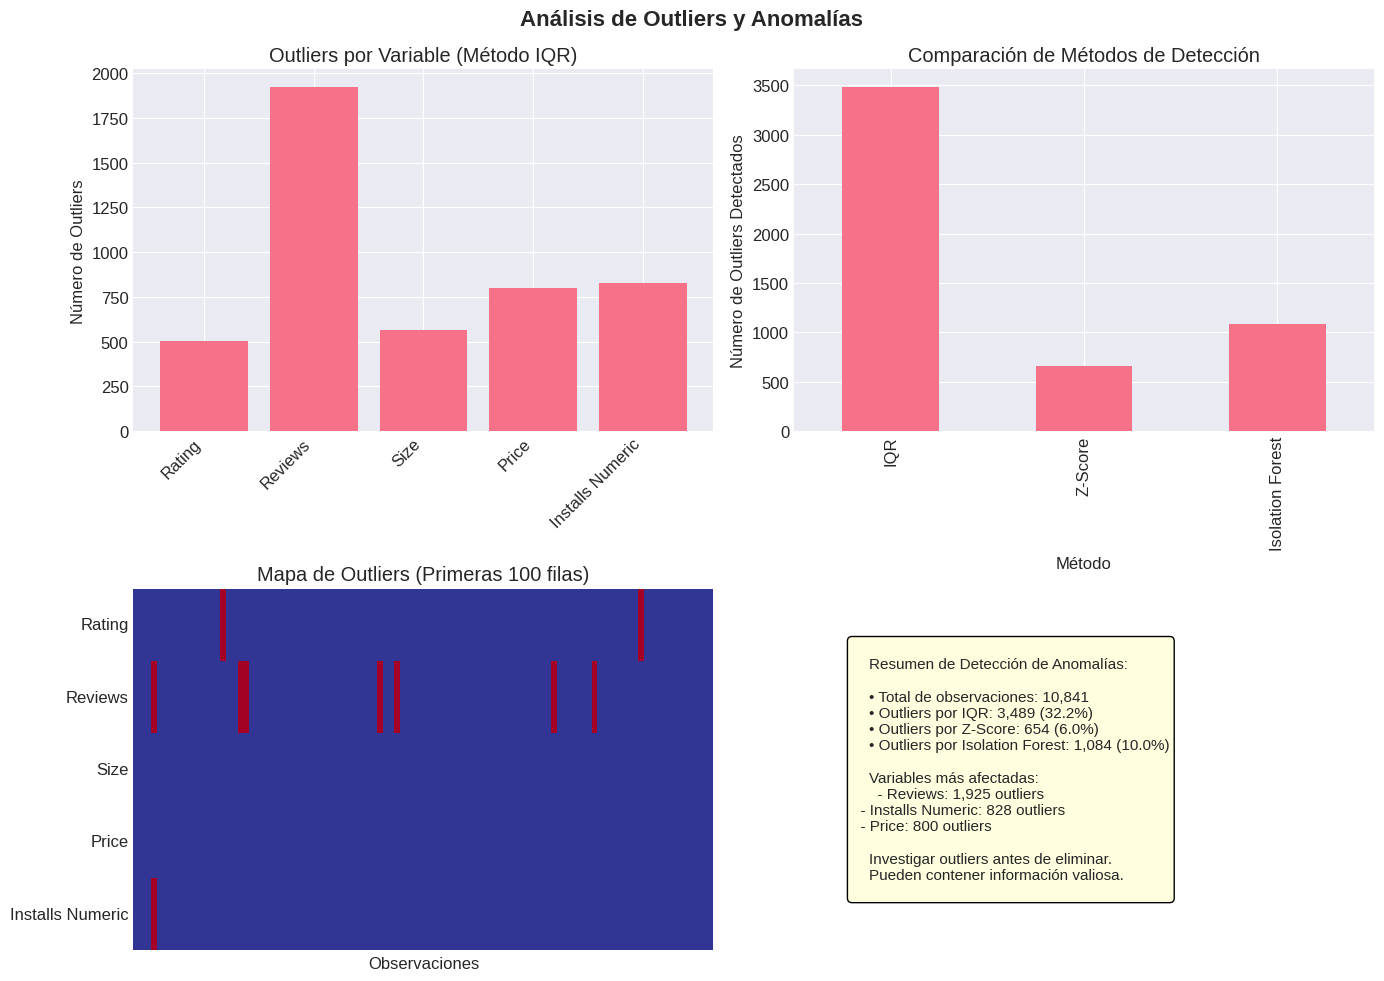

In [11]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def detect_outliers(df):
    """Detección de outliers usando múltiples métodos"""
    
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Método 1: IQR
    outliers_iqr = pd.DataFrame()
    for col in numeric_df.columns:
        Q1 = numeric_df[col].quantile(0.25)
        Q3 = numeric_df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((numeric_df[col] < Q1 - 1.5 * IQR) | 
                   (numeric_df[col] > Q3 + 1.5 * IQR))
        outliers_iqr[col] = outliers
    
    # Método 2: Z-Score
    from scipy import stats
    z_scores = np.abs(stats.zscore(numeric_df.fillna(numeric_df.median())))
    outliers_zscore = (z_scores > 3)
    
    # Método 3: Isolation Forest
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_df.fillna(numeric_df.median()))
    iso_forest = IsolationForest(contamination=0.1, random_state=42)
    outliers_iso = iso_forest.fit_predict(scaled_data) == -1
    
    # Visualización
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Outliers por columna (IQR)
    ax1 = axes[0, 0]
    outlier_counts = outliers_iqr.sum()
    ax1.bar(range(len(outlier_counts)), outlier_counts.values)
    ax1.set_xticks(range(len(outlier_counts)))
    ax1.set_xticklabels(outlier_counts.index, rotation=45, ha='right')
    ax1.set_title('Outliers por Variable (Método IQR)')
    ax1.set_ylabel('Número de Outliers')
    
    # Plot 2: Distribución de outliers por método
    ax2 = axes[0, 1]
    methods_comparison = pd.DataFrame({
        'IQR': outliers_iqr.any(axis=1).sum(),
        'Z-Score': outliers_zscore.any(axis=1).sum(),
        'Isolation Forest': outliers_iso.sum()
    }, index=['Outliers'])
    methods_comparison.T.plot(kind='bar', ax=ax2, legend=False)
    ax2.set_title('Comparación de Métodos de Detección')
    ax2.set_ylabel('Número de Outliers Detectados')
    ax2.set_xlabel('Método')
    
    # Plot 3: Heatmap de outliers
    ax3 = axes[1, 0]
    sample_outliers = outliers_iqr.head(100)
    sns.heatmap(sample_outliers.T, cmap='RdYlBu_r', cbar=False, ax=ax3,
               yticklabels=True, xticklabels=False)
    ax3.set_title('Mapa de Outliers (Primeras 100 filas)')
    ax3.set_xlabel('Observaciones')
    
    # Plot 4: Resumen estadístico
    ax4 = axes[1, 1]
    ax4.axis('off')
    summary_text = f"""
    Resumen de Detección de Anomalías:
    
    • Total de observaciones: {len(df):,}
    • Outliers por IQR: {outliers_iqr.any(axis=1).sum():,} ({outliers_iqr.any(axis=1).sum()/len(df)*100:.1f}%)
    • Outliers por Z-Score: {outliers_zscore.any(axis=1).sum():,} ({outliers_zscore.any(axis=1).sum()/len(df)*100:.1f}%)
    • Outliers por Isolation Forest: {outliers_iso.sum():,} ({outliers_iso.sum()/len(df)*100:.1f}%)
    
    Variables más afectadas:
    {chr(10).join([f'  - {col}: {count:,} outliers' 
                   for col, count in outlier_counts.nlargest(3).items()])}
    
    Investigar outliers antes de eliminar. 
    Pueden contener información valiosa.
    """
    ax4.text(0.1, 0.5, summary_text, transform=ax4.transAxes,
            fontsize=11, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow'))
    
    plt.suptitle('Análisis de Outliers y Anomalías', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return outliers_iqr, outliers_zscore, outliers_iso

# Ejecutar la detección de outliers en el dataset de aplicaciones
outliers_iqr, outliers_zscore, outliers_iso = detect_outliers(applications_data)

# Pipeline de Preparación de Datos (FASE #3 - CRISP-DM)

Esta sección contiene todos los transformadores personalizados para la preparación de datos del dataset de Google Play Store. Los transformadores siguen la interfaz de scikit-learn (BaseEstimator, TransformerMixin) y se pueden encadenar en un pipeline.

## Transformadores Básicos

Los transformadores básicos realizan las operaciones fundamentales de limpieza y validación de datos.

## NumericConverter

Convierte columnas a formato numérico siguiendo reglas específicas del dominio:

**Características principales:**
- Convierte Rating a numérico directamente
- Limpia Reviews eliminando comas y caracteres no numéricos
- Procesa Installs eliminando '+' y comas, creando columna 'Installs Numeric'
- Limpia Price eliminando '$' y caracteres no numéricos
- Convierte Size de formato 'M' y 'k' a MB numérico

In [12]:
class NumericConverter(BaseEstimator, TransformerMixin):
    """
    Convierte columnas a numéricas siguiendo la lógica del proyecto:
    - Rating: directamente a numérico
    - Reviews: elimina comas y caracteres no numéricos
    - Installs: elimina +, comas y crea columna 'Installs Numeric'
    - Price: elimina $ y caracteres no numéricos
    - Size: convierte M y k a MB numérico
    """
    
    def __init__(self, verbose=True):
        self.verbose = verbose
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        df = X.copy()
        
        if self.verbose:
            print("=" * 80)
            print("PASO 0: CONVERSIÓN DE COLUMNAS NUMÉRICAS".center(80))
            print("=" * 80)
        
        # Rating
        if "Rating" in df.columns:
            df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
            if self.verbose:
                print(f"✓ Rating convertido a numérico")
        
        # Reviews: quitar comas y cualquier carácter no numérico/punto
        if "Reviews" in df.columns:
            df["Reviews"] = (
                df["Reviews"].astype(str)
                .str.replace(r"[^\d.]", "", regex=True)
                .pipe(pd.to_numeric, errors="coerce")
            )
            if self.verbose:
                print(f"✓ Reviews convertido a numérico")
        
        # Installs: quitar +, comas y cualquier carácter no numérico/punto
        if "Installs" in df.columns:
            df["Installs Numeric"] = (
                df["Installs"].astype(str)
                .str.replace(r"[^\d.]", "", regex=True)
                .pipe(pd.to_numeric, errors="coerce")
            )
            if self.verbose:
                print(f"✓ Installs convertido a numérico (columna 'Installs Numeric')")
        
        # Price: quitar $ y cualquier carácter no numérico/punto
        if "Price" in df.columns:
            df["Price"] = (
                df["Price"].astype(str)
                .str.replace(r"[^\d.]", "", regex=True)
                .pipe(pd.to_numeric, errors="coerce")
            )
            if self.verbose:
                print(f"✓ Price convertido a numérico")
        
        # Size: convertir M y k/K a MB
        if "Size" in df.columns:
            def parse_size(x):
                if isinstance(x, str):
                    x = x.strip()
                    if x.endswith("M"):
                        return float(x[:-1])
                    elif x.endswith("k") or x.endswith("K"):
                        return float(x[:-1]) / 1024  # KB -> MB
                    else:
                        return np.nan
                return np.nan
            
            df["Size"] = df["Size"].apply(parse_size)
            if self.verbose:
                print(f"✓ Size convertido a MB numérico")
        
        if self.verbose:
            print(f"\nTotal de registros: {len(df):,}")
        
        return df

## DuplicateRemover

Elimina filas duplicadas del DataFrame para asegurar la calidad de los datos.

**Características principales:**
- Identifica y elimina registros duplicados
- Mantiene la primera ocurrencia de cada registro
- Reporta estadísticas sobre duplicados encontrados y eliminados
- Calcula el porcentaje de reducción del dataset

In [13]:
class DuplicateRemover(BaseEstimator, TransformerMixin):
    """
    Elimina filas duplicadas del DataFrame, manteniendo la primera ocurrencia.
    """
    
    def __init__(self, verbose=True):
        self.verbose = verbose
        self.initial_size = None
        self.duplicates_found = None
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        df = X.copy()
        
        if self.verbose:
            print("\n" + "=" * 80)
            print("PASO 1: ELIMINACIÓN DE DUPLICADOS".center(80))
            print("=" * 80)
        
        # Estado inicial
        self.initial_size = len(df)
        self.duplicates_found = df.duplicated().sum()
        
        if self.verbose:
            print(f"\nRegistros antes de eliminar duplicados: {self.initial_size:,}")
            print(f"Duplicados encontrados: {self.duplicates_found:,} ({self.duplicates_found/self.initial_size*100:.2f}%)")
        
        # Eliminar duplicados (manteniendo la primera ocurrencia)
        df = df.drop_duplicates(keep='first')
        
        # Estado final
        if self.verbose:
            print(f"Registros después de eliminar duplicados: {len(df):,}")
            print(f"Filas eliminadas: {self.initial_size - len(df):,}")
            print(f"Reducción: {((self.initial_size - len(df))/self.initial_size*100):.2f}%")
        
        return df

## ImpossibleValuesRemover

Elimina registros con valores imposibles o fuera de rango esperado.

**Características principales:**
- Valida que Rating esté en el rango [1, 5]
- Elimina valores negativos en Reviews, Size, Price e Installs Numeric
- Reporta valores inválidos encontrados por columna
- Mantiene registro de cuántos valores se eliminaron por tipo

In [14]:
class ImpossibleValuesRemover(BaseEstimator, TransformerMixin):
    """
    Elimina registros con valores imposibles:
    - Rating fuera del rango [1, 5]
    - Valores negativos en Reviews, Size, Price, Installs Numeric
    """
    
    def __init__(self, verbose=True):
        self.verbose = verbose
        self.removed_counts = {}
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        df = X.copy()
        
        if self.verbose:
            print("\n" + "=" * 80)
            print("PASO 2: CORRECCIÓN DE VALORES IMPOSIBLES".center(80))
            print("=" * 80)
        
        initial_len = len(df)
        
        # Verificar valores de Rating fuera del rango [1, 5]
        if 'Rating' in df.columns:
            invalid_ratings = ((df['Rating'] < 1) | (df['Rating'] > 5))
            invalid_count = invalid_ratings.sum()
            
            if self.verbose:
                print(f"\nRatings inválidos encontrados: {invalid_count}")
            
            if invalid_count > 0:
                if self.verbose:
                    invalid_values = sorted(df.loc[invalid_ratings, 'Rating'].dropna().unique())
                    print(f"Valores inválidos únicos: {invalid_values}")
                
                # Eliminar registros con valores inválidos
                df = df[~invalid_ratings].copy()
                self.removed_counts['rating'] = invalid_count
                
                if self.verbose:
                    print(f"✓ {invalid_count} registros con Rating inválido eliminados")
            else:
                if self.verbose:
                    print("✓ No se encontraron ratings inválidos")
        
        # Verificar valores negativos en columnas numéricas
        if self.verbose:
            print("\n" + "-" * 80)
            print("Verificando valores negativos en columnas numéricas:")
            print("-" * 80)
        
        numeric_cols = ['Reviews', 'Size', 'Price', 'Installs Numeric']
        for col in numeric_cols:
            if col in df.columns:
                negative_mask = df[col] < 0
                negative_count = negative_mask.sum()
                
                if negative_count > 0:
                    df = df[~negative_mask].copy()
                    self.removed_counts[col] = negative_count
                    if self.verbose:
                        print(f"✓ {col}: {negative_count} valores negativos eliminados")
                else:
                    if self.verbose:
                        print(f"✓ {col}: Sin valores negativos")
        
        if self.verbose:
            total_removed = initial_len - len(df)
            print(f"\nTotal de registros eliminados en este paso: {total_removed}")
            print(f"Registros restantes: {len(df):,}")
        
        return df

## ConsistencyValidator

Valida y corrige la consistencia entre variables relacionadas.

**Características principales:**
- Valida que apps 'Free' tengan Price = 0
- Valida que apps 'Paid' tengan Price > 0
- Corrige inconsistencias automáticamente
- Infiere Type desde Price cuando Type es NaN
- Reporta todas las correcciones realizadas

In [15]:
class ConsistencyValidator(BaseEstimator, TransformerMixin):
    """
    Valida y corrige la consistencia entre variables:
    - Type='Free' debe tener Price=0
    - Type='Paid' debe tener Price>0
    - Infiere Type desde Price cuando Type es NaN
    """
    
    def __init__(self, verbose=True):
        self.verbose = verbose
        self.corrections = {}
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        df = X.copy()
        
        if self.verbose:
            print("\n" + "=" * 80)
            print("PASO 3: VALIDACIÓN DE CONSISTENCIA ENTRE VARIABLES".center(80))
            print("=" * 80)
            print("\nValidando consistencia entre Type y Price:")
            print("-" * 80)
        
        # Casos inconsistentes: Type='Free' pero Price > 0
        free_but_paid = (df['Type'] == 'Free') & (df['Price'] > 0)
        free_but_paid_count = free_but_paid.sum()
        
        if self.verbose:
            print(f"\nApps marcadas como 'Free' pero con Price > 0: {free_but_paid_count}")
        
        if free_but_paid_count > 0:
            df.loc[free_but_paid, 'Type'] = 'Paid'
            self.corrections['free_to_paid'] = free_but_paid_count
            if self.verbose:
                print(f"✓ Corregido: {free_but_paid_count} apps cambiadas de 'Free' a 'Paid'")
        
        # Casos inconsistentes: Type='Paid' pero Price = 0
        paid_but_free = (df['Type'] == 'Paid') & (df['Price'] == 0)
        paid_but_free_count = paid_but_free.sum()
        
        if self.verbose:
            print(f"\nApps marcadas como 'Paid' pero con Price = 0: {paid_but_free_count}")
        
        if paid_but_free_count > 0:
            df.loc[paid_but_free, 'Type'] = 'Free'
            self.corrections['paid_to_free'] = paid_but_free_count
            if self.verbose:
                print(f"✓ Corregido: {paid_but_free_count} apps cambiadas de 'Paid' a 'Free'")
        
        # Inferir Type desde Price cuando Type es NaN
        type_missing = df['Type'].isnull()
        type_missing_count = type_missing.sum()
        
        if type_missing_count > 0:
            if self.verbose:
                print(f"\nType faltante en {type_missing_count} registros")
                print("Infiriendo Type desde Price...")
            
            df.loc[type_missing & (df['Price'] == 0), 'Type'] = 'Free'
            df.loc[type_missing & (df['Price'] > 0), 'Type'] = 'Paid'
            
            remaining_missing = df['Type'].isnull().sum()
            self.corrections['type_inferred'] = type_missing_count - remaining_missing
            
            if self.verbose:
                print(f"✓ Type inferido para {type_missing_count - remaining_missing} apps")
                print(f"Faltantes restantes: {remaining_missing}")
        
        if self.verbose:
            print("\n" + "-" * 80)
            print("Distribución final de Type:")
            print(df['Type'].value_counts())
            print("\n✓ Validación de consistencia completada")
        
        return df

## División y Imputación

Esta sección contiene las clases para dividir el dataset de forma estratificada y realizar imputación de valores faltantes sin data leakage. Notese que para los transformadores anteriores, las modificaciones hechas son correctas, sin dar acceso a información futura y demás para los cambios realizados, con lo que evita data leakage y no tiene ningún problema.

## StratifiedSplitter

Realiza división estratificada del dataset en conjuntos de Train/Val/Test basándose en bins de Rating.

**Características principales:**
- División estratificada por Rating para mantener distribución balanceada
- Crea bins alineados con clasificación binaria (Low ≤4.0, High >4.0)
- Elimina registros sin Rating antes de dividir
- División por defecto: 70% Train, 15% Val, 15% Test
- Reindexación automática para evitar problemas de índices

In [16]:
class StratifiedSplitter:
    """
    Realiza división estratificada del dataset en Train/Val/Test
    basándose en bins de Rating.
    """
    
    def __init__(self, test_size=0.30, val_size=0.50, random_state=42, verbose=True):
        self.test_size = test_size
        self.val_size = val_size
        self.random_state = random_state
        self.verbose = verbose
        self.train = None
        self.val = None
        self.test = None
    
    def split(self, df):
        """
        Divide el dataset en train/val/test de forma estratificada.
        
        Args:
            df: DataFrame limpio
            
        Returns:
            tuple: (train, val, test)
        """
        if self.verbose:
            print("\n" + "=" * 80)
            print("PASO 4: DIVISIÓN ESTRATIFICADA DEL DATASET".center(80))
            print("=" * 80)
        
        # Estado antes de dividir
        if self.verbose:
            print(f"\nDataset después de limpieza básica:")
            print(f"  Total de registros: {len(df):,}")
            print(f"  Rating faltantes: {df['Rating'].isnull().sum():,} ({df['Rating'].isnull().sum()/len(df)*100:.2f}%)")
        
        # 1. ELIMINAR filas sin Rating (no podemos entrenar con ellas)
        df_model = df.dropna(subset=['Rating']).copy()
        
        if self.verbose:
            print(f"\nDespués de eliminar filas sin Rating:")
            print(f"  Registros disponibles para modelado: {len(df_model):,}")
            print(f"  Registros descartados: {len(df) - len(df_model):,}")
        
        # 2. DIVISIÓN ESTRATIFICADA: Train (70%), Temp (30%)
        if self.verbose:
            print("\n" + "-" * 80)
            print("Dividiendo dataset (estratificado por Rating)...")
            print("-" * 80)
        
        # Crear bins de Rating para estratificación ALINEADA con clasificación binaria
        # Umbral en 4.0 para coincidir con target de clasificación: Low (≤4.0) vs High (>4.0)
        df_model['rating_bin'] = pd.cut(
            df_model['Rating'], 
            bins=[0, 4.0, 5], 
            labels=['Low', 'High']
        )
        
        if self.verbose:
            print(f"\nDistribución para estratificación (Rating ≤4.0 = Low, >4.0 = High):")
            print(df_model['rating_bin'].value_counts(normalize=True).mul(100).round(1))
        
        train, temp = train_test_split(
            df_model,
            test_size=self.test_size,
            stratify=df_model['rating_bin'],
            random_state=self.random_state
        )
        
        # 3. Dividir Temp en Val (50%) y Test (50%) → 15% y 15% del total
        val, test = train_test_split(
            temp,
            test_size=self.val_size,
            stratify=temp['rating_bin'],
            random_state=self.random_state
        )
        
        # Eliminar columna auxiliar de binning
        train = train.drop(columns=['rating_bin'])
        val = val.drop(columns=['rating_bin'])
        test = test.drop(columns=['rating_bin'])
        
        # Reindexar para evitar problemas
        train = train.reset_index(drop=True)
        val = val.reset_index(drop=True)
        test = test.reset_index(drop=True)
        
        if self.verbose:
            print(f"\n✓ División completada:")
            print(f"  Train: {len(train):,} registros ({len(train)/len(df_model)*100:.1f}%)")
            print(f"  Val:   {len(val):,} registros ({len(val)/len(df_model)*100:.1f}%)")
            print(f"  Test:  {len(test):,} registros ({len(test)/len(df_model)*100:.1f}%)")
        
        self.train = train
        self.val = val
        self.test = test
        
        return train, val, test

## NoLeakageImputer

Imputa valores faltantes sin data leakage, calculando estadísticas solo con el conjunto de entrenamiento. Notese que fit se hace con train, mientras que transform con las estadisticas calculadas a partir de train. Asegurandonos, con esta regla de oro, evitar data leakage.

**Características principales:**
- Calcula estadísticas (medianas, modas) SOLO con train
- Aplica las mismas estadísticas a val y test
- Crea flags de faltantes ANTES de imputar para trazabilidad
- Imputación por grupos (Category, Type) con fallback a valores globales
- Maneja Size, Content Rating, Android Ver, Current Ver y Price

In [17]:
class NoLeakageImputer:
    """
    Imputa valores faltantes SIN data leakage:
    1. Calcula estadísticas SOLO con train
    2. Aplica las mismas estadísticas a val y test
    3. Crea flags de faltantes ANTES de imputar
    """
    
    def __init__(self, verbose=True):
        self.verbose = verbose
        # Diccionarios para almacenar estadísticas de train
        self.size_medians = None
        self.size_global_median = None
        self.content_rating_modes = None
        self.content_rating_global_mode = None
        self.android_ver_modes = None
        self.android_ver_global_mode = None
        self.current_ver_modes = None
        self.current_ver_global_mode = None
        self.price_medians_paid = None
        self.price_global_median_paid = None
    
    def fit(self, train_df):
        """
        Calcula todas las estadísticas usando SOLO train.
        
        Args:
            train_df: DataFrame de entrenamiento
        """
        if self.verbose:
            print("\n" + "=" * 80)
            print("PASO 5: IMPUTACIÓN DE VALORES FALTANTES (Sin Data Leakage)".center(80))
            print("=" * 80)
            print("\nMETODOLOGÍA:")
            print("  1. Calcular estadísticas SOLO con train")
            print("  2. Aplicar las mismas estadísticas a val y test")
            print("  3. Crear flags de faltantes ANTES de imputar")
            print("=" * 80)
        
        # SIZE: Medianas por Category × Type
        self.size_medians = train_df.groupby(['Category', 'Type'])['Size'].median()
        self.size_global_median = train_df['Size'].median()
        if self.verbose:
            print(f"\n✓ SIZE: {len(self.size_medians)} medianas calculadas")
        
        # CONTENT RATING: Moda por Category
        self.content_rating_modes = train_df.groupby('Category')['Content Rating'].agg(
            lambda x: x.mode()[0] if not x.mode().empty else None
        )
        self.content_rating_global_mode = train_df['Content Rating'].mode()[0]
        if self.verbose:
            print(f"✓ CONTENT RATING: {len(self.content_rating_modes)} modas calculadas")
        
        # ANDROID VER: Moda por Category
        self.android_ver_modes = train_df.groupby('Category')['Android Ver'].agg(
            lambda x: x.mode()[0] if not x.mode().empty else None
        )
        self.android_ver_global_mode = train_df['Android Ver'].mode()[0]
        if self.verbose:
            print(f"✓ ANDROID VER: {len(self.android_ver_modes)} modas calculadas")
        
        # CURRENT VER: Moda por Category
        self.current_ver_modes = train_df.groupby('Category')['Current Ver'].agg(
            lambda x: x.mode()[0] if not x.mode().empty else None
        )
        self.current_ver_global_mode = train_df['Current Ver'].mode()[0]
        if self.verbose:
            print(f"✓ CURRENT VER: {len(self.current_ver_modes)} modas calculadas")
        
        # PRICE: Medianas para apps Paid por Category
        self.price_medians_paid = train_df[train_df['Type'] == 'Paid'].groupby('Category')['Price'].median()
        self.price_global_median_paid = train_df[train_df['Type'] == 'Paid']['Price'].median()
        if self.verbose:
            print(f"✓ PRICE: {len(self.price_medians_paid)} medianas calculadas para Paid apps")
        
        return self
    
    def transform(self, train_df, val_df, test_df):
        """
        Aplica imputación a train, val y test usando estadísticas de train.
        
        Args:
            train_df, val_df, test_df: DataFrames a imputar
            
        Returns:
            tuple: (train, val, test) imputados
        """
        # Crear copias
        train = train_df.copy()
        val = val_df.copy()
        test = test_df.copy()
        
        # ==============================================================================
        # CREAR FLAGS DE FALTANTES (antes de imputar)
        # ==============================================================================
        if self.verbose:
            print("\n" + "-" * 80)
            print("Creando flags de valores faltantes...")
            print("-" * 80)
        
        for df in [train, val, test]:
            df['size_missing'] = df['Size'].isnull().astype(int)
            df['content_rating_missing'] = df['Content Rating'].isnull().astype(int)
            df['android_ver_missing'] = df['Android Ver'].isnull().astype(int)
            df['current_ver_missing'] = df['Current Ver'].isnull().astype(int)
            df['price_missing'] = df['Price'].isnull().astype(int)
        
        if self.verbose:
            print("✓ Flags creados en train, val y test")
        
        # ==============================================================================
        # 1. SIZE: Imputar con medianas precalculadas
        # ==============================================================================
        if self.verbose:
            print("\n" + "-" * 80)
            print("Imputando SIZE (mediana por Category × Type)")
            print("-" * 80)
        
        for df in [train, val, test]:
            df = self._impute_size(df)
        
        if self.verbose:
            print(f"✓ Size imputado")
            print(f"   Train faltantes: {train['Size'].isnull().sum()}")
            print(f"   Val faltantes: {val['Size'].isnull().sum()}")
            print(f"   Test faltantes: {test['Size'].isnull().sum()}")
        
        # ==============================================================================
        # 2. CONTENT RATING: Imputar con modas precalculadas
        # ==============================================================================
        if self.verbose:
            print("\n" + "-" * 80)
            print("Imputando CONTENT RATING (moda por Category)")
            print("-" * 80)
        
        train = self._impute_content_rating(train)
        val = self._impute_content_rating(val)
        test = self._impute_content_rating(test)
        
        if self.verbose:
            print(f"✓ Content Rating imputado")
        
        # ==============================================================================
        # 3. ANDROID VER: Imputar con modas precalculadas
        # ==============================================================================
        if self.verbose:
            print("\n" + "-" * 80)
            print("Imputando ANDROID VER (moda por Category)")
            print("-" * 80)
        
        train = self._impute_android_ver(train)
        val = self._impute_android_ver(val)
        test = self._impute_android_ver(test)
        
        if self.verbose:
            print(f"✓ Android Ver imputado")
        
        # ==============================================================================
        # 4. CURRENT VER: Imputar con modas precalculadas
        # ==============================================================================
        if self.verbose:
            print("\n" + "-" * 80)
            print("Imputando CURRENT VER (moda por Category)")
            print("-" * 80)
        
        train = self._impute_current_ver(train)
        val = self._impute_current_ver(val)
        test = self._impute_current_ver(test)
        
        if self.verbose:
            print(f"✓ Current Ver imputado")
        
        # ==============================================================================
        # 5. PRICE: 0 si Free, mediana por Category si Paid
        # ==============================================================================
        if self.verbose:
            print("\n" + "-" * 80)
            print("Imputando PRICE (0 si Free, mediana por Category si Paid)")
            print("-" * 80)
        
        train = self._impute_price(train)
        val = self._impute_price(val)
        test = self._impute_price(test)
        
        if self.verbose:
            print(f"✓ Price imputado")
        
        # ==============================================================================
        # RESUMEN FINAL
        # ==============================================================================
        if self.verbose:
            print("\n" + "=" * 80)
            print("IMPUTACIÓN COMPLETADA SIN DATA LEAKAGE")
            print("=" * 80)
            print("\nValores faltantes restantes:")
            
            for name, df in [('Train', train), ('Val', val), ('Test', test)]:
                missing = df.isnull().sum()
                missing = missing[missing > 0]
                if len(missing) == 0:
                    print(f"  {name}: Sin valores faltantes")
                else:
                    print(f"  {name}: {missing.to_dict()}")
            
            print("\nFlags de trazabilidad creados:")
            print("  - size_missing")
            print("  - content_rating_missing")
            print("  - android_ver_missing")
            print("  - current_ver_missing")
            print("  - price_missing")
        
        return train, val, test
    
    def fit_transform(self, train_df, val_df, test_df):
        """Fit y transform en un solo paso"""
        self.fit(train_df)
        return self.transform(train_df, val_df, test_df)
    
    # Métodos auxiliares de imputación
    def _impute_size(self, df):
        """Imputa Size usando medianas precalculadas"""
        for idx, row in df[df['Size'].isnull()].iterrows():
            cat, typ = row['Category'], row['Type']
            if (cat, typ) in self.size_medians.index:
                df.loc[idx, 'Size'] = self.size_medians.loc[(cat, typ)]
            else:
                df.loc[idx, 'Size'] = self.size_global_median
        return df
    
    def _impute_content_rating(self, df):
        """Imputa Content Rating usando modas precalculadas"""
        for idx, row in df[df['Content Rating'].isnull()].iterrows():
            cat = row['Category']
            if cat in self.content_rating_modes.index and pd.notna(self.content_rating_modes.loc[cat]):
                df.loc[idx, 'Content Rating'] = self.content_rating_modes.loc[cat]
            else:
                df.loc[idx, 'Content Rating'] = self.content_rating_global_mode
        return df
    
    def _impute_android_ver(self, df):
        """Imputa Android Ver usando modas precalculadas"""
        for idx, row in df[df['Android Ver'].isnull()].iterrows():
            cat = row['Category']
            if cat in self.android_ver_modes.index and pd.notna(self.android_ver_modes.loc[cat]):
                df.loc[idx, 'Android Ver'] = self.android_ver_modes.loc[cat]
            else:
                df.loc[idx, 'Android Ver'] = self.android_ver_global_mode
        return df
    
    def _impute_current_ver(self, df):
        """Imputa Current Ver usando modas precalculadas"""
        for idx, row in df[df['Current Ver'].isnull()].iterrows():
            cat = row['Category']
            if cat in self.current_ver_modes.index and pd.notna(self.current_ver_modes.loc[cat]):
                df.loc[idx, 'Current Ver'] = self.current_ver_modes.loc[cat]
            else:
                df.loc[idx, 'Current Ver'] = self.current_ver_global_mode
        return df
    
    def _impute_price(self, df):
        """Imputa Price (0 si Free, mediana si Paid)"""
        # Free apps → 0
        mask_free = (df['Type'] == 'Free') & df['Price'].isnull()
        df.loc[mask_free, 'Price'] = 0
        
        # Paid apps → mediana por Category
        for idx, row in df[(df['Type'] == 'Paid') & df['Price'].isnull()].iterrows():
            cat = row['Category']
            if cat in self.price_medians_paid.index and pd.notna(self.price_medians_paid.loc[cat]):
                df.loc[idx, 'Price'] = self.price_medians_paid.loc[cat]
            else:
                df.loc[idx, 'Price'] = self.price_global_median_paid
        return df

## NumericTransformer

Aplica transformaciones logarítmicas y crea variables binarias para mejorar la distribución de las variables numéricas y capturar patrones no lineales. Se realiza individualmente por train, validation y test para evitar data leakage.

**Características principales:**
- Transformaciones logarítmicas: Reviews, Installs, Size
- Variables binarias: is_free, is_large_app, has_high_installs, is_top_category, is_everyone_rated, large_and_popular
- Reduce el impacto de outliers y mejora la normalidad de las distribuciones

In [18]:
class NumericTransformer(BaseEstimator, TransformerMixin):
    """
    Aplica transformaciones logarítmicas y crea variables binarias.
    - Log-transformaciones: Reviews, Installs Numeric, Size
    - Variables binarias basadas en reglas fijas
    """
    
    def __init__(self, verbose=True):
        self.verbose = verbose
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        df = X.copy()
        
        if self.verbose:
            print("\n" + "=" * 80)
            print("PASO 6: TRANSFORMACIONES DE VARIABLES NUMÉRICAS".center(80))
            print("=" * 80)
        
        # ==============================================================================
        # 1. LOG-TRANSFORMACIONES
        # ==============================================================================
        if self.verbose:
            print("\nAplicando transformaciones logarítmicas...")
            print("-" * 80)
        
        df['Reviews_log'] = np.log1p(df['Reviews'])
        df['Installs_log'] = np.log1p(df['Installs Numeric'])
        df['Size_log'] = np.log1p(df['Size'])
        
        if self.verbose:
            print(f"✓ Reviews_log: Media {df['Reviews_log'].mean():.2f}, Mediana {df['Reviews_log'].median():.2f}")
            print(f"✓ Installs_log: Media {df['Installs_log'].mean():.2f}, Mediana {df['Installs_log'].median():.2f}")
            print(f"✓ Size_log: Media {df['Size_log'].mean():.2f}, Mediana {df['Size_log'].median():.2f}")
        
        # ==============================================================================
        # 2. VARIABLES BINARIAS
        # ==============================================================================
        if self.verbose:
            print("\n" + "-" * 80)
            print("Creando variables binarias...")
            print("-" * 80)
        
        df['is_free'] = (df['Type'] == 'Free').astype(int)
        df['is_large_app'] = (df['Size'] > 50).astype(int)
        df['has_high_installs'] = (df['Installs Numeric'] > 1000000).astype(int)
        df['is_top_category'] = df['Category'].isin(['FAMILY', 'GAME']).astype(int)
        df['is_everyone_rated'] = (df['Content Rating'] == 'Everyone').astype(int)
        df['large_and_popular'] = (df['is_large_app'] & df['has_high_installs']).astype(int)
        
        if self.verbose:
            print(f"✓ is_free: {df['is_free'].sum()} ({df['is_free'].mean()*100:.1f}%)")
            print(f"✓ is_large_app: {df['is_large_app'].sum()} ({df['is_large_app'].mean()*100:.1f}%)")
            print(f"✓ has_high_installs: {df['has_high_installs'].sum()} ({df['has_high_installs'].mean()*100:.1f}%)")
            print(f"✓ is_top_category: {df['is_top_category'].sum()} ({df['is_top_category'].mean()*100:.1f}%)")
            print(f"✓ is_everyone_rated: {df['is_everyone_rated'].sum()} ({df['is_everyone_rated'].mean()*100:.1f}%)")
            print(f"✓ large_and_popular: {df['large_and_popular'].sum()} ({df['large_and_popular'].mean()*100:.1f}%)")
        
        if self.verbose:
            print("\n✓ Transformaciones numéricas completadas")
        
        return df

## FeatureEngineer

Crea variables derivadas sin data leakage, utilizando estadísticas calculadas solo con el conjunto de entrenamiento.

**Características principales:**
- Ratios y métricas derivadas: review_rate, size_per_install, market_penetration
- Features de temporalidad: days_since_update, update_recency, is_recently_updated
- Popularity score normalizado con estadísticas de train
- Features de categorización avanzada y análisis del nombre de la app
- Extracción de versión mínima de Android

In [19]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Crea variables derivadas sin data leakage:
    - Ratios y métricas derivadas
    - Fecha de actualización y recency
    - Popularity score normalizado con estadísticas de train
    """
    
    def __init__(self, reference_date='2025-10-02', verbose=True):
        self.reference_date = pd.to_datetime(reference_date)
        self.verbose = verbose
        self.installs_min = None
        self.installs_max = None
        self.reviews_min = None
        self.reviews_max = None
        self._is_fitted = False
    
    def fit(self, X, y=None):
        """Calcula estadísticas solo de train para normalización"""
        self.installs_min = X['Installs Numeric'].min()
        self.installs_max = X['Installs Numeric'].max()
        self.reviews_min = X['Reviews'].min()
        self.reviews_max = X['Reviews'].max()
        
        # Calcular quantiles para popularity_tier (evitar data leakage)
        self.installs_quantiles = [0] + X['Installs Numeric'].quantile([0.2, 0.4, 0.6, 0.8, 1.0]).tolist()
        
        # Calcular quantiles para days_since_update (evitar data leakage)
        # Primero procesar fechas para obtener days_since_update
        temp_df = X.copy()
        temp_df['Last Updated Parsed'] = temp_df['Last Updated'].apply(self._parse_date_flexible)
        temp_df['days_since_update'] = (self.reference_date - temp_df['Last Updated Parsed']).dt.days
        valid_days = temp_df['days_since_update'].dropna()
        
        if len(valid_days) > 0:
            percentiles = [0, 0.2, 0.4, 0.6, 0.8, 0.95, 1.0]
            self.days_quantiles = valid_days.quantile(percentiles).tolist()
            self.days_quantiles[0] = -1  # Para incluir valores negativos
            self.days_quantiles[-1] = 10000  # Para valores muy altos
        else:
            # Fallback con bins fijos
            self.days_quantiles = [-1, 30, 90, 365, 730, 10000]
        
        if self.verbose:
            print(f"\n✓ Estadísticas de train almacenadas para normalización:")
            print(f"  Installs: [{self.installs_min:.0f}, {self.installs_max:.0f}]")
            print(f"  Reviews: [{self.reviews_min:.0f}, {self.reviews_max:.0f}]")
            print(f"  Installs quantiles: {self.installs_quantiles}")
            print(f"  Days quantiles: {self.days_quantiles}")

        self._is_fitted = True
        return self
    
    def _parse_date_flexible(self, date_str):
        """Método auxiliar para parsear fechas con múltiples formatos"""
        if pd.isna(date_str):
            return pd.NaT
        
        # Intentar diferentes formatos comunes
        date_formats = [
            '%B %d, %Y',      # "January 15, 2018"
            '%b %d, %Y',      # "Jan 15, 2018" 
            '%d-%b-%y',       # "15-Jan-18"
            '%Y-%m-%d',       # "2018-01-15"
            '%m/%d/%Y',       # "01/15/2018"
            '%d/%m/%Y'        # "15/01/2018"
        ]
        
        for fmt in date_formats:
            try:
                return pd.to_datetime(date_str, format=fmt)
            except:
                continue
        
        # Si ningún formato funciona, usar pd.to_datetime con inferencia
        try:
            return pd.to_datetime(date_str, infer_datetime_format=True)
        except:
            return pd.NaT
    
    def transform(self, X):
        if not self._is_fitted:
            raise ValueError("Debe llamar fit() antes de transform()")

        df = X.copy()
        
        if self.verbose:
            print("\n" + "=" * 80)
            print("PASO 7: FEATURE ENGINEERING".center(80))
            print("=" * 80)
        
        # ==============================================================================
        # 1. RATIOS Y MÉTRICAS DERIVADAS MEJORADAS
        # ==============================================================================
        if self.verbose:
            print("\nCreando ratios y métricas derivadas...")
            print("-" * 80)
        
        # Ratios básicos
        df['review_rate'] = df['Reviews'] / (df['Installs Numeric'] + 1)
        df['size_per_install'] = df['Size'] / (df['Installs Numeric'] + 1)
        
        # CORREGIDO: usar max de train para evitar data leakage
        df['market_penetration'] = df['Installs Numeric'] / self.installs_max

        
        # Métricas de competitividad
        df['price_competitiveness'] = 1 / (df['Price'] + 0.01)  # Inverso del precio
        
        # Features de temporalidad mejoradas (se crearán después del procesamiento de fechas)
        
        # Features de categorización avanzada
        df['is_premium_category'] = df['Category'].isin(['FINANCE', 'PRODUCTIVITY', 'BUSINESS']).astype(int)
        df['is_entertainment_category'] = df['Category'].isin(['GAME', 'ENTERTAINMENT', 'SOCIAL']).astype(int)
        df['is_utility_category'] = df['Category'].isin(['TOOLS', 'COMMUNICATION', 'PHOTOGRAPHY']).astype(int)

        # Features del nombre de la app (señal ligera y barata)
        if 'App' in df.columns:
            app_series = df['App'].astype(str)
            df['app_name_length'] = app_series.str.len().fillna(0).astype(int)
            df['app_name_word_count'] = app_series.str.split().str.len().fillna(0).astype(int)
            # Presencia de dígitos en el nombre
            df['app_name_has_digit'] = app_series.str.contains(r"\d", regex=True).fillna(False).astype(int)
        
        # Features de tamaño relativo
        # Eliminado: 'size_category' (baja importancia en clasificación binaria)
        # Anteriormente: pd.cut(Size) -> ['Tiny','Small','Medium','Large','Huge']
        # df['size_category'] = pd.cut(df['Size'], bins=[0, 10, 50, 100, 1000, float('inf')], labels=['Tiny', 'Small', 'Medium', 'Large', 'Huge'])
        
        # Features de popularidad relativa - CORREGIDO: usar estadísticas de train
        # Eliminado: 'popularity_tier' (baja importancia y redundante con Installs_log/popularity_score)
        # df['popularity_tier'] = pd.cut(
        #     df['Installs Numeric'], 
        #     bins=self.installs_quantiles, 
        #     labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
        #     include_lowest=True
        # )
        
        if self.verbose:
            print(f"✓ review_rate: Media {df['review_rate'].mean():.6f}")
            print(f"✓ size_per_install: Media {df['size_per_install'].mean():.6f}")
        
        # ==============================================================================
        # 2. FECHA DE ACTUALIZACIÓN
        # ==============================================================================
        if self.verbose:
            print("\n" + "-" * 80)
            print("Procesando fecha de actualización...")
            print("-" * 80)
        
        df['Last Updated Parsed'] = df['Last Updated'].apply(self._parse_date_flexible)
        df['days_since_update'] = (self.reference_date - df['Last Updated Parsed']).dt.days
        
        # CORREGIDO: Usar bins predefinidos para evitar data leakage
        # No usar estadísticas del dataset actual
        df['update_recency'] = pd.cut(
            df['days_since_update'],
            bins=self.days_quantiles,
            labels=['Very Recent', 'Recent', 'Moderate', 'Old', 'Very Old', 'Ancient'],
            include_lowest=True
        ) 
        
        # Añadir features de temporalidad después del procesamiento de fechas
        df['is_recently_updated'] = (df['days_since_update'] <= 90).astype(int)
        df['update_frequency_score'] = 1 / (df['days_since_update'] + 1)  # Más reciente = mayor score
        
        if self.verbose:
            print(f"✓ days_since_update: Media {df['days_since_update'].mean():.0f} días")
            print(f"✓ update_recency creada (6 categorías)")
            print(f"✓ is_recently_updated: {df['is_recently_updated'].sum()} apps recientes")
            print(f"✓ update_frequency_score: Media {df['update_frequency_score'].mean():.6f}")
        
        # ==============================================================================
        # 3. POPULARITY SCORE (normalizado con estadísticas de train)
        # ==============================================================================
        if self.verbose:
            print("\n" + "-" * 80)
            print("Calculando popularity score...")
            print("-" * 80)
        
        installs_norm = (df['Installs Numeric'] - self.installs_min) / (self.installs_max - self.installs_min)
        reviews_norm = (df['Reviews'] - self.reviews_min) / (self.reviews_max - self.reviews_min)
        df['popularity_score'] = (installs_norm * 0.7 + reviews_norm * 0.3) * 100
        
        if self.verbose:
            print(f"✓ popularity_score: Media {df['popularity_score'].mean():.2f}")
        
        # 3.1 ANDROID VERSION: extraer versión mínima como número y flag >= 4.1
        if 'Android Ver' in df.columns:
            def _extract_android_min(v):
                if pd.isna(v):
                    return np.nan
                # Buscar primer número tipo 4, 4.1, 5.0
                m = re.search(r"(\d+(?:\.\d+)?)", str(v))
                if m:
                    try:
                        return float(m.group(1))
                    except:
                        return np.nan
                return np.nan
            df['android_min_version'] = df['Android Ver'].apply(_extract_android_min).fillna(0.0)
            df['android_ge_4_1'] = (df['android_min_version'] >= 4.1).fillna(False).astype(int)

        # ==============================================================================
        # 4. ELIMINAR COLUMNAS REDUNDANTES
        # ==============================================================================
        if self.verbose:
            print("\n" + "-" * 80)
            print("Eliminando columnas redundantes...")
            print("-" * 80)
        
        redundant_cols = [
            'Reviews', 'Installs Numeric', 'Size', 'Installs', 'Genres', 
            'Last Updated', 'Last Updated Parsed', 'Current Ver', 'Android Ver', 
            'days_since_update',
            # Eliminaciones para simplificar y evitar dummies de baja señal
            'Type',               # reemplazado por is_free (binaria)
            'size_category',      # baja importancia
            'popularity_tier'     # baja importancia
        ]
        
        cols_to_drop = [col for col in redundant_cols if col in df.columns]
        df = df.drop(columns=cols_to_drop)
        
        if self.verbose:
            print(f"✓ {len(cols_to_drop)} columnas eliminadas: {cols_to_drop}")
        
        # ==============================================================================
        # 5. ELIMINAR DUPLICADOS
        # ==============================================================================
        if self.verbose:
            print("\n" + "-" * 80)
            print("Eliminando duplicados...")
            print("-" * 80)
        
        initial_len = len(df)
        df = df.drop_duplicates(ignore_index=True)
        
        if self.verbose:
            print(f"✓ Duplicados eliminados: {initial_len - len(df)}")
            print(f"  Registros finales: {len(df):,}")
        
        if self.verbose:
            print("\n✓ Feature engineering completado")
        
        return df

## SentimentFeatureExtractor

Extrae features de análisis de sentimientos de reviews a nivel de app, sin data leakage.

**Características principales:**
- Distribución de sentimientos: positive_ratio, negative_ratio, neutral_ratio
- Estadísticas de polaridad: mean, median, std, min, max, range
- Estadísticas de subjetividad: mean, median, std
- Sentiment strength: positive_strength, negative_strength
- Métricas de volumen: total_reviews_sentiment, opinion_variance, extreme_polarity_ratio
- Calcula estadísticas solo con reviews de apps en train para evitar data leakage

In [21]:
class SentimentFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Extrae features de sentiment analysis a nivel de app SIN DATA LEAKAGE.
    
    CORRECCIÓN DE DATA LEAKAGE:
    - fit(X_train): Calcula estadísticas solo con reviews de apps en train
    - transform(X): Aplica esas estadísticas a cualquier conjunto (train/val/test)
    
    Para cada app calcula:
    - Distribución de sentimientos (positive/negative/neutral)
    - Estadísticas de polaridad y subjetividad
    - Métricas de volumen de reviews
    - Sentiment strength
    
    Ejemplo de uso:
        >>> extractor = SentimentFeatureExtractor('reviews.csv', verbose=True)
        >>> extractor.fit(X_train)  # Solo con train
        >>> train_with_sentiment = extractor.transform(X_train)
        >>> val_with_sentiment = extractor.transform(X_val)
        >>> test_with_sentiment = extractor.transform(X_test)
    """
    
    def __init__(self, reviews_path: str, verbose: bool = True):
        """
        Args:
            reviews_path: Ruta al archivo CSV de reviews
            verbose: Mostrar información detallada
        """
        self.reviews_path = reviews_path
        self.verbose = verbose
        self.sentiment_features = None  # Estadísticas calculadas con train
        self._is_fitted = False
        self.reviews_df = None  # Reviews completas (para transform)
    
    def fit(self, X, y=None):
        """
        Calcula features de sentiment SOLO para apps en X (train).
        
        Args:
            X: DataFrame con columna 'App' (solo train)
            y: Target (no utilizado)
            
        Returns:
            self
        """
        if self.verbose:
            print("\n" + "=" * 80)
            print(" EXTRAYENDO FEATURES DE SENTIMENT (SIN DATA LEAKAGE) ".center(80, "="))
            print("=" * 80)
        
        # Cargar reviews COMPLETAS (necesarias para transform en val/test)
        try:
            self.reviews_df = pd.read_csv(self.reviews_path)
            if self.verbose:
                print(f"\n✓ Reviews cargados: {len(self.reviews_df):,} filas")
                print(f"  Columnas: {list(self.reviews_df.columns)}")
        except FileNotFoundError:
            raise FileNotFoundError(f"Archivo de reviews no encontrado: {self.reviews_path}")
        
        # Validar columnas requeridas
        required_cols = ['App', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']
        missing_cols = [col for col in required_cols if col not in self.reviews_df.columns]
        if missing_cols:
            raise ValueError(f"Columnas faltantes en reviews: {missing_cols}")
        
        # ====================================================================
        # CORRECCIÓN DE DATA LEAKAGE: Filtrar reviews SOLO de apps en train
        # ====================================================================
        train_apps = set(X['App'].unique())
        reviews_train_only = self.reviews_df[self.reviews_df['App'].isin(train_apps)].copy()
        
        if self.verbose:
            print(f"\n✓ Apps en train: {len(train_apps):,}")
            print(f"  Reviews de apps en train: {len(reviews_train_only):,} ({len(reviews_train_only)/len(self.reviews_df)*100:.1f}%)")
            print(f"  Reviews de apps NO en train (ignoradas): {len(self.reviews_df) - len(reviews_train_only):,}")
        
        # Filtrar reviews válidos (no NaN en sentiment)
        reviews_valid = reviews_train_only.dropna(subset=['Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity'])
        
        if self.verbose:
            print(f"\n✓ Reviews válidos (con sentiment): {len(reviews_valid):,} ({len(reviews_valid)/len(reviews_train_only)*100:.1f}%)")
            print(f"  Removidos (NaN): {len(reviews_train_only) - len(reviews_valid):,}")
        
        # Agrupar por App y calcular features (SOLO CON TRAIN)
        if self.verbose:
            print("\nCalculando features de sentiment por app (solo train)...")
            print("-" * 80)
        
        sentiment_agg = []
        
        for app_name, group in reviews_valid.groupby('App'):
            features = self._calculate_sentiment_features(app_name, group)
            sentiment_agg.append(features)
        
        # Crear DataFrame con features de sentiment
        self.sentiment_features = pd.DataFrame(sentiment_agg)
        
        if self.verbose:
            print(f"\n✓ Features de sentiment calculadas para {len(self.sentiment_features):,} apps (train)")
            print(f"  Features por app: {len(self.sentiment_features.columns) - 1}")
            print(f"\nEjemplo de features calculadas (primeras 3 apps):")
            display_cols = ['App', 'positive_ratio', 'negative_ratio', 'polarity_mean', 
                           'polarity_std', 'negative_strength', 'total_reviews_sentiment']
            print(self.sentiment_features[display_cols].head(3).to_string(index=False))
            
            # Estadísticas de las features
            print(f"\n📊 Estadísticas de sentiment features:")
            print(f"  Total features: {len(self.sentiment_features.columns) - 1}")
            print(f"  Positive ratio: mean={self.sentiment_features['positive_ratio'].mean():.3f}")
            print(f"  Negative ratio: mean={self.sentiment_features['negative_ratio'].mean():.3f}")
            print(f"  Polarity mean: mean={self.sentiment_features['polarity_mean'].mean():.3f}, std={self.sentiment_features['polarity_mean'].std():.3f}")
            print(f"  Total reviews per app: mean={self.sentiment_features['total_reviews_sentiment'].mean():.1f}")
        
        self._is_fitted = True
        return self
    
    def _calculate_sentiment_features(self, app_name, group):
        """Calcula todas las features de sentiment para una app"""
        features = {'App': app_name}
        
        # ================================================================
        # 1. DISTRIBUCIÓN DE SENTIMIENTOS (3 features)
        # ================================================================
        sentiment_counts = group['Sentiment'].value_counts(normalize=True)
        features['positive_ratio'] = sentiment_counts.get('Positive', 0)
        features['negative_ratio'] = sentiment_counts.get('Negative', 0)
        features['neutral_ratio'] = sentiment_counts.get('Neutral', 0)
        
        # ================================================================
        # 2. ESTADÍSTICAS DE POLARIDAD (6 features)
        # ================================================================
        polarity = group['Sentiment_Polarity']
        features['polarity_mean'] = polarity.mean()
        features['polarity_median'] = polarity.median()
        features['polarity_std'] = polarity.std()
        features['polarity_min'] = polarity.min()
        features['polarity_max'] = polarity.max()
        features['polarity_range'] = polarity.max() - polarity.min()
        
        # ================================================================
        # 3. SUBJETIVIDAD (3 features)
        # ================================================================
        subjectivity = group['Sentiment_Subjectivity']
        features['subjectivity_mean'] = subjectivity.mean()
        features['subjectivity_median'] = subjectivity.median()
        features['subjectivity_std'] = subjectivity.std()
        
        # ================================================================
        # 4. SENTIMENT STRENGTH (2 features)
        # ================================================================
        positive_reviews = group[group['Sentiment'] == 'Positive']
        features['positive_strength'] = positive_reviews['Sentiment_Polarity'].mean() if len(positive_reviews) > 0 else 0
        
        negative_reviews = group[group['Sentiment'] == 'Negative']
        features['negative_strength'] = abs(negative_reviews['Sentiment_Polarity'].mean()) if len(negative_reviews) > 0 else 0
        
        # ================================================================
        # 5. FEATURES ADICIONALES (3 features)
        # ================================================================
        features['total_reviews_sentiment'] = len(group)
        features['opinion_variance'] = polarity.var()
        features['extreme_polarity_ratio'] = ((abs(polarity) > 0.5).sum() / len(polarity)) if len(polarity) > 0 else 0
        
        return features
    
    def transform(self, X):
        """
        Aplica features de sentiment calculadas con train a cualquier conjunto.
        
        Para apps en train: Usa las estadísticas calculadas
        Para apps nuevas (val/test): Calcula features con sus propias reviews
        
        Args:
            X: DataFrame con columna 'App'
            
        Returns:
            DataFrame con features de sentiment agregadas
        """
        if not self._is_fitted:
            raise ValueError("Debe llamar fit() antes de transform()")
        
        df = X.copy()
        
        # Para apps que YA tienen features calculadas (estaban en train)
        df = df.merge(self.sentiment_features, on='App', how='left')
        
        # Para apps NUEVAS (val/test): calcular features con sus reviews
        apps_without_sentiment = df[df[self.sentiment_features.columns[1]].isna()]['App'].unique()
        
        if len(apps_without_sentiment) > 0 and self.verbose:
            print(f"\nApps nuevas sin sentiment features: {len(apps_without_sentiment)} ({len(apps_without_sentiment)/len(df['App'].unique())*100:.1f}%)")
            print(f"   → Se calcularán features con reviews de estas apps")
        
        # Calcular features para apps nuevas
        if len(apps_without_sentiment) > 0:
            new_apps_reviews = self.reviews_df[self.reviews_df['App'].isin(apps_without_sentiment)].copy()
            new_apps_reviews = new_apps_reviews.dropna(subset=['Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity'])
            
            new_sentiment_agg = []
            for app_name, group in new_apps_reviews.groupby('App'):
                features = self._calculate_sentiment_features(app_name, group)
                new_sentiment_agg.append(features)
            
            if len(new_sentiment_agg) > 0:
                new_sentiment_df = pd.DataFrame(new_sentiment_agg)
                
                # Actualizar df con las nuevas features
                for idx, row in df[df['App'].isin(apps_without_sentiment)].iterrows():
                    app_name = row['App']
                    if app_name in new_sentiment_df['App'].values:
                        app_features = new_sentiment_df[new_sentiment_df['App'] == app_name].iloc[0]
                        for col in new_sentiment_df.columns:
                            if col != 'App':
                                df.at[idx, col] = app_features[col]
        
        # Apps sin reviews de sentiment: imputar con valores conservadores
        sentiment_cols = self.sentiment_features.columns.drop('App').tolist()
        apps_still_missing = df[df[sentiment_cols[0]].isna()]['App'].nunique()
        
        if apps_still_missing > 0 and self.verbose:
            print(f"\nApps sin reviews de sentiment: {apps_still_missing}")
            print(f"   → Se imputarán con valores por defecto")
        
        # Valores por defecto (representan "sin información de sentiment")
        default_values = {
            # Distribución neutra (3 features)
            'positive_ratio': 0.33,
            'negative_ratio': 0.33,
            'neutral_ratio': 0.34,
            # Polaridad neutra (6 features)
            'polarity_mean': 0.0,
            'polarity_median': 0.0,
            'polarity_std': 0.3,
            'polarity_min': -0.5,
            'polarity_max': 0.5,
            'polarity_range': 1.0,
            # Subjetividad moderada (3 features)
            'subjectivity_mean': 0.5,
            'subjectivity_median': 0.5,
            'subjectivity_std': 0.3,
            # Sin fuerza de sentimientos (2 features)
            'positive_strength': 0.0,
            'negative_strength': 0.0,
            # Características adicionales (3 features)
            'total_reviews_sentiment': 0,
            'opinion_variance': 0.09,
            'extreme_polarity_ratio': 0.0
        }
        
        for col in sentiment_cols:
            if col in default_values:
                df[col] = df[col].fillna(default_values[col])
        
        # Crear feature adicional: ratio de reviews con sentiment vs Reviews totales
        if 'Reviews' in df.columns:
            df['reviews_with_sentiment_ratio'] = df['total_reviews_sentiment'] / (df['Reviews'] + 1)
            if self.verbose:
                print(f"\n✓ Feature adicional creada: reviews_with_sentiment_ratio")
                print(f"  Mean: {df['reviews_with_sentiment_ratio'].mean():.4f}")
        
        if self.verbose:
            print(f"\n✓ Sentiment features agregadas al DataFrame")
            print(f"  Shape final: {df.shape}")
            total_features = len(sentiment_cols) + (1 if 'Reviews' in df.columns else 0)
            print(f"  Features de sentiment: {total_features}")
        
        return df
    
    def get_feature_names(self):
        """Retorna lista de nombres de features generadas"""
        if not self._is_fitted:
            raise ValueError("Debe llamar fit() primero")
        
        feature_names = self.sentiment_features.columns.drop('App').tolist()
        feature_names.append('reviews_with_sentiment_ratio')
        return feature_names

## RareCategoryHandler

Maneja categorías raras en variables categóricas:
- Agrupa categorías con frecuencia menor al threshold en "Other"
- Elimina categorías específicas de Content Rating
- Evita data leakage calculando estadísticas solo con train

**Características principales:**
- Identifica categorías principales en train
- Agrupa categorías raras en "Other"
- Elimina categorías problemáticas ("Adults only 18+", "Unrated")

In [22]:
class RareCategoryHandler(BaseEstimator, TransformerMixin):
    """
    Maneja categorías raras en variables categóricas:
    - Agrupa categorías con frecuencia < threshold en 'Other'
    - Elimina categorías específicas de Content Rating
    """
    
    def __init__(self, category_threshold=70, verbose=True):
        self.category_threshold = category_threshold
        self.verbose = verbose
        self.main_categories = None
    
    def fit(self, X, y=None):
        """Identifica categorías principales en train"""
        freq_train = X['Category'].value_counts()
        self.main_categories = set(freq_train[freq_train >= self.category_threshold].index.tolist())
        
        if self.verbose:
            print(f"\n✓ Categorías principales identificadas: {len(self.main_categories)}")
            print(f"  Threshold: {self.category_threshold} ocurrencias")
        
        return self
    
    def transform(self, X):
        df = X.copy()
        
        if self.verbose:
            print("\n" + "=" * 80)
            print("PASO 8: MANEJO DE CATEGORÍAS RARAS".center(80))
            print("=" * 80)
        
        # ==============================================================================
        # 1. CATEGORY: Agrupar raras en 'Other'
        # ==============================================================================
        if self.verbose:
            print("\nAgrupando categorías raras en 'Other'...")
            print("-" * 80)
        
        initial_unique = df['Category'].nunique()
        df['Category'] = df['Category'].apply(lambda x: x if x in self.main_categories else 'Other')
        final_unique = df['Category'].nunique()
        
        if self.verbose:
            other_count = (df['Category'] == 'Other').sum()
            other_pct = other_count / len(df) * 100
            print(f"✓ Categorías únicas: {initial_unique} → {final_unique}")
            print(f"✓ Registros en 'Other': {other_count} ({other_pct:.1f}%)")
        
        # ==============================================================================
        # 2. CONTENT RATING: Eliminar categorías problemáticas
        # ==============================================================================
        if self.verbose:
            print("\n" + "-" * 80)
            print("Eliminando categorías problemáticas de Content Rating...")
            print("-" * 80)
        
        initial_len = len(df)
        df = df[~df['Content Rating'].isin(['Adults only 18+', 'Unrated'])].copy()
        df = df.reset_index(drop=True)
        
        if self.verbose:
            print(f"✓ Registros eliminados: {initial_len - len(df)}")
            print(f"✓ Registros finales: {len(df):,}")
            print(f"\nDistribución de Content Rating:")
            print(df['Content Rating'].value_counts())
        
        if self.verbose:
            print("\n✓ Manejo de categorías raras completado")
        
        return df

## MutualInfoSelector

Selecciona variables basándose en información mutua con el target:
- Calcula MI scores solo con train
- Elimina variables con MI < threshold
- Genera visualización de importancia

**Características principales:**
- Análisis de relevancia mediante información mutua
- Identificación de variables con baja señal
- Evita data leakage calculando estadísticas solo con train

In [23]:
class MutualInfoSelector(BaseEstimator, TransformerMixin):
    """
    Selecciona variables basándose en información mutua con el target.
    - Calcula MI scores solo con train
    - Elimina variables con MI < threshold
    - Genera visualización de importancia
    """
    
    def __init__(self, target='Rating', mi_threshold=0.005, random_state=42, verbose=True, plot=False):
        self.target = target
        self.mi_threshold = mi_threshold
        self.random_state = random_state
        self.verbose = verbose
        self.plot = plot
        self.selected_vars = None
        self.mi_scores = None
        self.low_mi_vars = None
    
    def fit(self, X, y=None):
        """Calcula información mutua solo con train"""
        from sklearn.feature_selection import mutual_info_regression
        
        if self.verbose:
            print("\n" + "=" * 80)
            print("PASO 9: ANÁLISIS DE RELEVANCIA (INFORMACIÓN MUTUA)".center(80))
            print("=" * 80)
        
        # Seleccionar solo columnas numéricas (excluyendo target)
        ignore_cols = [self.target]
        X_cols = [
            col for col in X.columns
            if col not in ignore_cols
            and pd.api.types.is_numeric_dtype(X[col])
        ]
        
        if self.verbose:
            print(f"\nVariables numéricas analizadas: {len(X_cols)}")
        
        # Preparar datos
        X_numeric = X[X_cols].copy()
        y_target = X[self.target]
        
        # Calcular información mutua
        mi_scores = mutual_info_regression(X_numeric, y_target, random_state=self.random_state)
        self.mi_scores = pd.DataFrame({
            'Variable': X_cols, 
            'MI_Score': mi_scores
        }).sort_values('MI_Score', ascending=False)
        
        # Identificar variables con baja MI
        self.low_mi_vars = self.mi_scores[self.mi_scores['MI_Score'] < self.mi_threshold]['Variable'].tolist()
        self.selected_vars = self.mi_scores[self.mi_scores['MI_Score'] >= self.mi_threshold]['Variable'].tolist()
        
        if self.verbose:
            print(f"\n✓ Información mutua calculada")
            print(f"\nTop 10 variables más relevantes:")
            print(self.mi_scores.head(10).to_string(index=False))
            
            print(f"\n\nVariables con baja información mutua (<{self.mi_threshold}):")
            for v in self.low_mi_vars:
                mi_val = self.mi_scores[self.mi_scores['Variable'] == v]['MI_Score'].values[0]
                print(f"  - {v}: {mi_val:.4f}")
            
            print(f"\n✓ Variables seleccionadas: {len(self.selected_vars)}")
            print(f"✓ Variables eliminadas: {len(self.low_mi_vars)}")
        
        # Visualización
        if self.plot:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(10, 6))
            plt.barh(self.mi_scores['Variable'], self.mi_scores['MI_Score'], color='teal')
            plt.xlabel('Información Mutua con Rating')
            plt.title('Importancia de Variables (Información Mutua)')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()
        
        return self
    
    def transform(self, X):
        """Elimina variables con baja información mutua"""
        df = X.copy()
        
        # Eliminar variables con MI baja
        cols_to_drop = [col for col in self.low_mi_vars if col in df.columns]
        if cols_to_drop:
            df = df.drop(columns=cols_to_drop)
            
            if self.verbose:
                print(f"\n✓ Variables eliminadas por baja MI: {len(cols_to_drop)}")
        
        return df

## MulticollinearityRemover

Detecta y elimina variables con alta multicolinealidad:
- Calcula matriz de correlación con train
- Identifica pares con |corr| > threshold
- Elimina variables predefinidas por análisis previo

**Características principales:**
- Análisis de correlación entre variables
- Identificación de pares con alta multicolinealidad
- Evita data leakage calculando estadísticas solo con train

In [24]:
class MulticollinearityRemover(BaseEstimator, TransformerMixin):
    """
    Detecta y elimina variables con alta multicolinealidad.
    - Calcula matriz de correlación con train
    - Identifica pares con |corr| > threshold
    - Elimina variables predefinidas por análisis previo
    """
    
    def __init__(self, corr_threshold=0.8, vars_to_remove=None, verbose=True, plot=False):
        self.corr_threshold = corr_threshold
        self.vars_to_remove = vars_to_remove or ['Installs_log']  # Default basado en análisis
        self.verbose = verbose
        self.plot = plot
        self.corr_matrix = None
        self.high_corr_pairs = []
    
    def fit(self, X, y=None):
        """Analiza multicolinealidad solo con train"""
        if self.verbose:
            print("\n" + "=" * 80)
            print("PASO 10: ANÁLISIS DE MULTICOLINEALIDAD".center(80))
            print("=" * 80)
        
        # Seleccionar solo variables numéricas
        numeric_cols = [col for col in X.columns if pd.api.types.is_numeric_dtype(X[col])]
        
        # CORREGIDO: Calcular matriz de correlación SOLO con train
        self.corr_matrix = X[numeric_cols].corr(method='pearson')
        
        # Identificar pares con alta correlación
        if self.verbose:
            print(f"\nPares de variables con alta correlación (|corr| > {self.corr_threshold}):")
        
        high_corr = self.corr_matrix.where(np.triu(np.ones(self.corr_matrix.shape), k=1).astype(bool))
        for col in high_corr.columns:
            for idx in high_corr.index:
                corr_val = high_corr.loc[idx, col]
                if abs(corr_val) > self.corr_threshold:
                    self.high_corr_pairs.append((idx, col, corr_val))
                    if self.verbose:
                        print(f"  • {idx} y {col}: {corr_val:+.2f}")
        
        if not self.high_corr_pairs and self.verbose:
            print("  No se encontraron pares con alta correlación")
        
        # Visualización
        if self.plot:
            import matplotlib.pyplot as plt
            import seaborn as sns
            
            plt.figure(figsize=(12, 8))
            sns.heatmap(self.corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                       center=0, vmin=-1, vmax=1)
            plt.title('Matriz de Correlación (Pearson) - Multicolinealidad')
            plt.tight_layout()
            plt.show()
        
        if self.verbose:
            print(f"\n✓ Variables a eliminar por multicolinealidad: {self.vars_to_remove}")
        
        return self
    
    def transform(self, X):
        """Elimina variables con alta multicolinealidad"""
        df = X.copy()
        
        # Eliminar variables identificadas
        cols_to_drop = [col for col in self.vars_to_remove if col in df.columns]
        if cols_to_drop:
            df = df.drop(columns=cols_to_drop)
            
            if self.verbose:
                print(f"\n✓ Variables eliminadas: {cols_to_drop}")
                print(f"✓ Columnas restantes: {len(df.columns)}")
        
        return df

## OneHotEncoder

Aplica one-hot encoding a variables categóricas sin data leakage:
- Identifica columnas categóricas en train
- Crea dummies y almacena columnas resultantes
- Alinea val/test con las mismas columnas de train

**Características principales:**
- Codificación one-hot de variables categóricas
- Alineación de columnas entre train/val/test
- Evita data leakage usando estructura de train

In [25]:
class OneHotEncoder(BaseEstimator, TransformerMixin):
    """
    Aplica one-hot encoding a variables categóricas sin data leakage.
    - Identifica columnas categóricas en train
    - Crea dummies y almacena columnas resultantes
    - Alinea val/test con las mismas columnas de train
    """
    
    def __init__(self, exclude_cols=None, drop_first=False, verbose=True):
        self.exclude_cols = exclude_cols or ['App']
        self.drop_first = drop_first
        self.verbose = verbose
        self.cat_cols = None
        self.dummy_cols = None
        self.final_cols = None
    
    def fit(self, X, y=None):
        """Identifica columnas categóricas y estructura de dummies en train"""
        if self.verbose:
            print("\n" + "=" * 80)
            print("PASO 11: ONE-HOT ENCODING".center(80))
            print("=" * 80)
        
        # Identificar columnas categóricas
        self.cat_cols = [
            c for c in X.columns
            if (X[c].dtype == 'object' or str(X[c].dtype) == 'category')
            and c not in self.exclude_cols
        ]
        
        if self.verbose:
            print(f"\nColumnas categóricas identificadas: {len(self.cat_cols)}")
            for col in self.cat_cols:
                print(f"  - {col}: {X[col].nunique()} categorías únicas")
        
        # Crear dummies en train
        train_dummies = pd.get_dummies(X, columns=self.cat_cols, drop_first=self.drop_first)
        
        # Identificar nuevas columnas dummy
        self.dummy_cols = [col for col in train_dummies.columns 
                          if col not in X.columns or col in self.cat_cols]
        
        # Almacenar columnas finales
        self.final_cols = train_dummies.columns.tolist()
        
        if self.verbose:
            print(f"\n✓ Columnas dummy creadas: {len(self.dummy_cols)}")
            print(f"✓ Total de columnas después de encoding: {len(self.final_cols)}")
        
        return self
    
    def transform(self, X):
        """Aplica one-hot encoding y alinea columnas con train"""
        # Crear dummies
        df_dummies = pd.get_dummies(X, columns=self.cat_cols, drop_first=self.drop_first)
        
        # Agregar columnas faltantes (con 0)
        for col in self.dummy_cols:
            if col not in df_dummies.columns:
                df_dummies[col] = 0
        
        # Eliminar columnas extra
        extra_cols = set(df_dummies.columns) - set(self.final_cols)
        if extra_cols:
            df_dummies = df_dummies.drop(columns=list(extra_cols))
        
        # Reordenar columnas para match con train
        df_dummies = df_dummies[self.final_cols]
        
        if self.verbose:
            print(f"\n✓ Encoding aplicado: {df_dummies.shape[1]} columnas")
        
        return df_dummies

## GooglePlayDataPreparationPipeline

Pipeline completo para preprocesamiento de datos de Google Play Store. Orquesta todos los transformadores manteniendo separación train/val/test sin data leakage.

**Características principales:**
- Ejecuta todos los transformadores en el orden correcto
- Mantiene separación estricta entre train/val/test
- Calcula todas las estadísticas solo con train (sin data leakage)
- Aplica las mismas transformaciones a val y test
- Incluye soporte opcional para sentiment features
- Genera resúmenes detallados del proceso

In [26]:
# ============================================================================
# PIPELINE PRINCIPAL - ORQUESTADOR
# ============================================================================

class GooglePlayDataPreparationPipeline:
    """
    Pipeline completo para preprocesamiento de datos de Google Play Store.
    Orquesta todos los transformadores manteniendo separación train/val/test.
    """
    
    def __init__(self, 
                 test_size=0.30,
                 val_size=0.50,
                 category_threshold=70,
                 mi_threshold=0.005,
                 corr_threshold=0.8,
                 vars_to_remove=None,
                 reference_date='2025-10-02',
                 random_state=42,
                 verbose=True,
                 plot=False,
                 reviews_sentiment_path=None):
        """
        Inicializa el pipeline con todos sus parámetros.
        
        Args:
            test_size: Proporción para split inicial (default: 0.30)
            val_size: Proporción de temp para val (default: 0.50)
            category_threshold: Frecuencia mínima para categorías (default: 70)
            mi_threshold: Umbral de información mutua (default: 0.01)
            corr_threshold: Umbral de correlación (default: 0.8)
            vars_to_remove: Variables a eliminar por multicolinealidad
            reference_date: Fecha de referencia para cálculos
            random_state: Semilla aleatoria
            verbose: Mostrar mensajes detallados
            plot: Generar visualizaciones
            reviews_sentiment_path: Ruta al CSV de reviews con sentiment (opcional)
        """
        self.test_size = test_size
        self.val_size = val_size
        self.category_threshold = category_threshold
        self.mi_threshold = mi_threshold
        self.corr_threshold = corr_threshold
        self.vars_to_remove = vars_to_remove or ['Installs_log']
        self.reference_date = reference_date
        self.random_state = random_state
        self.verbose = verbose
        self.plot = plot
        self.reviews_sentiment_path = reviews_sentiment_path
        
        # Componentes del pipeline
        self.numeric_converter = None
        self.sentiment_extractor = None
        self.duplicate_remover = None
        self.impossible_values_remover = None
        self.consistency_validator = None
        self.splitter = None
        self.imputer = None
        self.numeric_transformer = None
        self.feature_engineer = None
        self.rare_category_handler = None
        self.mutual_info_selector = None
        self.multicollinearity_remover = None
        self.one_hot_encoder = None
        
        # Datos procesados
        self.train = None
        self.val = None
        self.test = None
        
    def fit_transform(self, df):
        """
        Ejecuta el pipeline completo sobre los datos.
        
        Args:
            df: DataFrame crudo de Google Play Store
            
        Returns:
            tuple: (train, val, test) completamente procesados
        """
        if self.verbose:
            print("\n" + "=" * 80)
            print("GOOGLE PLAY STORE - PIPELINE DE PREPROCESAMIENTO".center(80))
            print("=" * 80)
            print(f"\nDataset inicial: {df.shape[0]:,} filas, {df.shape[1]} columnas")
            print("=" * 80)
        
        # ============================================================================
        # FASE 1: LIMPIEZA BÁSICA (antes del split)
        # ============================================================================
        
        # Paso 0: Conversión de columnas numéricas
        self.numeric_converter = NumericConverter(verbose=self.verbose)
        df = self.numeric_converter.fit_transform(df)
        
        # Paso 1: Eliminación de duplicados
        self.duplicate_remover = DuplicateRemover(verbose=self.verbose)
        df = self.duplicate_remover.fit_transform(df)
        
        # Paso 2: Corrección de valores imposibles
        self.impossible_values_remover = ImpossibleValuesRemover(verbose=self.verbose)
        df = self.impossible_values_remover.fit_transform(df)
        
        # Paso 3: Validación de consistencia
        self.consistency_validator = ConsistencyValidator(verbose=self.verbose)
        df = self.consistency_validator.fit_transform(df)
        
        # ============================================================================
        # FASE 2: SPLIT ESTRATIFICADO
        # ============================================================================
        
        # Paso 4: División estratificada
        self.splitter = StratifiedSplitter(
            test_size=self.test_size,
            val_size=self.val_size,
            random_state=self.random_state,
            verbose=self.verbose
        )
        train, val, test = self.splitter.split(df)
        
        # ============================================================================
        # FASE 3: IMPUTACIÓN (sin data leakage)
        # ============================================================================
        
        # Paso 5: Imputación sin data leakage
        self.imputer = NoLeakageImputer(verbose=self.verbose)
        train, val, test = self.imputer.fit_transform(train, val, test)
        
        # ============================================================================
        # FASE 3.5: SENTIMENT FEATURES (sin data leakage)
        # ============================================================================
        
        # Paso 5.5: Extracción de features de sentiment DESPUÉS del split
        if self.reviews_sentiment_path is not None:
            if self.verbose:
                print("\n" + "=" * 80)
                print("PASO 5.5: SENTIMENT FEATURES (SIN DATA LEAKAGE)".center(80))
                print("=" * 80)
            
            self.sentiment_extractor = SentimentFeatureExtractor(
                reviews_path=self.reviews_sentiment_path,
                verbose=self.verbose
            )
            # fit SOLO con train
            self.sentiment_extractor.fit(train)
            # transform a todos
            train = self.sentiment_extractor.transform(train)
            val = self.sentiment_extractor.transform(val)
            test = self.sentiment_extractor.transform(test)
        else:
            if self.verbose:
                print("\n⚠️  Sentiment features NO agregadas (reviews_sentiment_path=None)")
        
        # ============================================================================
        # FASE 4: TRANSFORMACIONES (fit con train, transform a todos)
        # ============================================================================
        
        # Paso 6: Transformaciones numéricas
        self.numeric_transformer = NumericTransformer(verbose=self.verbose)
        self.numeric_transformer.fit(train)
        train = self.numeric_transformer.transform(train)
        val = self.numeric_transformer.transform(val)
        test = self.numeric_transformer.transform(test)
        
        # Paso 7: Feature Engineering
        self.feature_engineer = FeatureEngineer(
            reference_date=self.reference_date,
            verbose=self.verbose
        )
        self.feature_engineer.fit(train)
        train = self.feature_engineer.transform(train)
        val = self.feature_engineer.transform(val)
        test = self.feature_engineer.transform(test)
        
        # Paso 8: Manejo de categorías raras
        self.rare_category_handler = RareCategoryHandler(
            category_threshold=self.category_threshold,
            verbose=self.verbose
        )
        self.rare_category_handler.fit(train)
        train = self.rare_category_handler.transform(train)
        val = self.rare_category_handler.transform(val)
        test = self.rare_category_handler.transform(test)
        
        # ============================================================================
        # FASE 5: SELECCIÓN DE FEATURES
        # ============================================================================
        
        # Paso 9: Análisis de información mutua
        self.mutual_info_selector = MutualInfoSelector(
            target='Rating',
            mi_threshold=self.mi_threshold,
            random_state=self.random_state,
            verbose=self.verbose,
            plot=self.plot
        )
        self.mutual_info_selector.fit(train)
        train = self.mutual_info_selector.transform(train)
        val = self.mutual_info_selector.transform(val)
        test = self.mutual_info_selector.transform(test)
        
        # Paso 10: Análisis de multicolinealidad
        self.multicollinearity_remover = MulticollinearityRemover(
            corr_threshold=self.corr_threshold,
            vars_to_remove=self.vars_to_remove,
            verbose=self.verbose,
            plot=self.plot
        )
        self.multicollinearity_remover.fit(train)
        train = self.multicollinearity_remover.transform(train)
        val = self.multicollinearity_remover.transform(val)
        test = self.multicollinearity_remover.transform(test)


        # ============================================================================
        # RESUMEN INTERMEDIO: ANTES DEL ONE-HOT ENCODING
        # ============================================================================
        
        if self.verbose:
            print("\n" + "=" * 80)
            print("RESUMEN INTERMEDIO: DATASET ANTES DE ONE-HOT ENCODING".center(80))
            print("=" * 80)
            
            # Comparación de dimensiones
            print("\n" + "=" * 80)
            print("DIMENSIONES DE LOS CONJUNTOS")
            print("=" * 80)
            
            summary_data = []
            for name, df in [('Train', train), ('Val', val), ('Test', test)]:
                summary_data.append({
                    'Conjunto': name,
                    'Registros': f"{len(df):,}",
                    'Columnas': len(df.columns),
                    'Duplicados': df.duplicated().sum(),
                    'Memoria (MB)': f"{df.memory_usage(deep=True).sum() / 1024**2:.2f}"
                })
            
            summary_df = pd.DataFrame(summary_data)
            print("\n", summary_df.to_string(index=False))
            
            # Listado completo de features
            print("\n" + "=" * 80)
            print("LISTADO COMPLETO DE FEATURES")
            print("=" * 80)
            
            all_cols = train.columns.tolist()
            
            # Separar por tipo
            numeric_cols = [col for col in all_cols if pd.api.types.is_numeric_dtype(train[col])]
            categorical_cols = [col for col in all_cols if train[col].dtype == 'object' or str(train[col].dtype) == 'category']
            
            print(f"\nTotal de features: {len(all_cols)}")
            print(f"  • Variables numéricas: {len(numeric_cols)}")
            print(f"  • Variables categóricas: {len(categorical_cols)}")
            
            # Numéricas
            print("\n" + "-" * 80)
            print(f"VARIABLES NUMÉRICAS ({len(numeric_cols)}):")
            print("-" * 80)
            for i, col in enumerate(numeric_cols, 1):
                dtype = train[col].dtype
                n_unique = train[col].nunique()
                missing = train[col].isnull().sum()
                print(f"  {i:3d}. {col:<30} | dtype: {dtype} | unique: {n_unique:>6} | missing: {missing}")
            
            # Categóricas
            if categorical_cols:
                print("\n" + "-" * 80)
                print(f"VARIABLES CATEGÓRICAS ({len(categorical_cols)}):")
                print("-" * 80)
                for i, col in enumerate(categorical_cols, 1):
                    n_unique = train[col].nunique()
                    missing = train[col].isnull().sum()
                    print(f"  {i:3d}. {col:<30} | unique: {n_unique:>6} | missing: {missing}")
                    if n_unique <= 10:
                        top_values = train[col].value_counts().head(5)
                        print(f"       Top 5: {dict(top_values)}")
            
            # Estadísticas descriptivas de variables numéricas clave
            print("\n" + "=" * 80)
            print("ESTADÍSTICAS DESCRIPTIVAS (Train - Variables Numéricas Clave)")
            print("=" * 80)
            
            key_numeric = [
                'Rating', 'Price', 'Reviews_log', 'Size_log',
                'review_rate', 'size_per_install', 'popularity_score'
            ]
            available_numeric = [col for col in key_numeric if col in train.columns]
            
            if available_numeric:
                stats = train[available_numeric].describe().T
                print("\n" + stats.to_string())
            
            # Verificar consistencia entre splits
            print("\n" + "=" * 80)
            print("VERIFICACIÓN DE CONSISTENCIA ENTRE SPLITS")
            print("=" * 80)
            
            # Verificar que todas tienen las mismas columnas
            train_cols = set(train.columns)
            val_cols = set(val.columns)
            test_cols = set(test.columns)
            
            if train_cols == val_cols == test_cols:
                print("✓ Todos los conjuntos tienen las mismas columnas")
            else:
                print("⚠ ADVERTENCIA: Los conjuntos tienen columnas diferentes")
                if train_cols != val_cols:
                    print(f"  Train - Val: {train_cols - val_cols} | {val_cols - train_cols}")
                if train_cols != test_cols:
                    print(f"  Train - Test: {train_cols - test_cols} | {test_cols - train_cols}")
            
            # Verificar valores faltantes
            train_missing = train.isnull().sum().sum()
            val_missing = val.isnull().sum().sum()
            test_missing = test.isnull().sum().sum()
            
            print(f"\nValores faltantes totales:")
            print(f"  Train: {train_missing} ({train_missing/train.size*100:.4f}%)")
            print(f"  Val:   {val_missing} ({val_missing/val.size*100:.4f}%)")
            print(f"  Test:  {test_missing} ({test_missing/test.size*100:.4f}%)")
            
            if train_missing == 0 and val_missing == 0 and test_missing == 0:
                print("✓ No hay valores faltantes en ningún conjunto")
            else:
                print("\n⚠ Columnas con valores faltantes:")
                for name, df in [('Train', train), ('Val', val), ('Test', test)]:
                    missing_cols = df.isnull().sum()
                    missing_cols = missing_cols[missing_cols > 0]
                    if len(missing_cols) > 0:
                        print(f"\n  {name}:")
                        for col, count in missing_cols.items():
                            print(f"    - {col}: {count} ({count/len(df)*100:.2f}%)")
            
            # Distribución del target
            if 'Rating' in train.columns:
                print("\n" + "=" * 80)
                print("DISTRIBUCIÓN DEL TARGET (Rating)")
                print("=" * 80)
                
                for name, df in [('Train', train), ('Val', val), ('Test', test)]:
                    print(f"\n{name}:")
                    print(f"  Media: {df['Rating'].mean():.4f}")
                    print(f"  Mediana: {df['Rating'].median():.4f}")
                    print(f"  Std: {df['Rating'].std():.4f}")
                    print(f"  Min: {df['Rating'].min():.4f}")
                    print(f"  Max: {df['Rating'].max():.4f}")
            
            print("\n" + "=" * 80)
            print("✓ RESUMEN COMPLETADO - LISTO PARA ONE-HOT ENCODING")
            print("=" * 80)
        
        # ============================================================================
        # FASE 6: ENCODING FINAL
        # ============================================================================
        
        # Paso 11: One-hot encoding
        self.one_hot_encoder = OneHotEncoder(
            exclude_cols=['App'],
            drop_first=False,
            verbose=self.verbose
        )
        self.one_hot_encoder.fit(train)
        train = self.one_hot_encoder.transform(train)
        val = self.one_hot_encoder.transform(val)
        test = self.one_hot_encoder.transform(test)
        
        # ============================================================================
        # RESUMEN FINAL
        # ============================================================================
        
        if self.verbose:
            print("\n" + "=" * 80)
            print("PIPELINE COMPLETADO".center(80))
            print("=" * 80)
            print("\nDatasets finales:")
            print(f"  Train: {train.shape[0]:,} filas × {train.shape[1]} columnas")
            print(f"  Val:   {val.shape[0]:,} filas × {val.shape[1]} columnas")
            print(f"  Test:  {test.shape[0]:,} filas × {test.shape[1]} columnas")
            
            # Verificar que todas tienen las mismas columnas
            assert list(train.columns) == list(val.columns) == list(test.columns), \
                "Error: Los conjuntos no tienen las mismas columnas"
            
            print("\n✓ Todos los conjuntos tienen las mismas columnas")
            print(f"✓ Sin data leakage: Todas las estadísticas calculadas solo con train")
            
            # Verificar valores faltantes
            train_missing = train.isnull().sum().sum()
            val_missing = val.isnull().sum().sum()
            test_missing = test.isnull().sum().sum()
            
            print(f"\nValores faltantes finales:")
            print(f"  Train: {train_missing}")
            print(f"  Val:   {val_missing}")
            print(f"  Test:  {test_missing}")
        
        # Antes de devolver, convertir columnas boolean-like a 0/1 para persistencia
        # Esto evita que valores 'True'/'False' (strings) o bool dtype se guarden/lee
        # como no numéricos y se pierdan en la selección de features.
        for df in [train, val, test]:
            # Objetos que contienen solo 'True'/'False' (case-insensitive)
            obj_cols = df.select_dtypes(include=['object']).columns.tolist()
            for col in obj_cols:
                uniques = df[col].dropna().unique()
                lower_uniques = set([str(u).lower() for u in uniques])
                if lower_uniques <= {'true', 'false'}:
                    df[col] = df[col].map(lambda x: 1 if str(x).lower() == 'true' else 0 if str(x).lower() == 'false' else np.nan)

            # Convertir bool a int
            bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
            for col in bool_cols:
                df[col] = df[col].astype(int)

            # Asegurar tipo numérico para columnas enteras con valores 0/1 almacenados como floats
            # (por ejemplo después de mapear), convertir a tipo int cuando no haya nulos
            for col in df.select_dtypes(include=['number']).columns:
                # Si los valores únicos son subset de {0,1} y no hay nulos, convertir a int8
                uniques = pd.unique(df[col].dropna())
                if set(uniques).issubset({0, 1}):
                    if df[col].isnull().sum() == 0:
                        df[col] = df[col].astype('int8')
    
        # Guardar datasets procesados en atributos
        self.train = train
        self.val = val
        self.test = test

        return train, val, test
    def get_feature_names(self):
        """Retorna los nombres de las features finales"""
        if self.train is not None:
            return self.train.columns.tolist()
        return None
    
    def get_summary(self):
        """Retorna un resumen del pipeline ejecutado"""
        summary = {
            'train_shape': self.train.shape if self.train is not None else None,
            'val_shape': self.val.shape if self.val is not None else None,
            'test_shape': self.test.shape if self.test is not None else None,
            'total_features': len(self.train.columns) if self.train is not None else None,
            'parameters': {
                'test_size': self.test_size,
                'val_size': self.val_size,
                'category_threshold': self.category_threshold,
                'mi_threshold': self.mi_threshold,
                'corr_threshold': self.corr_threshold,
                'vars_removed': self.vars_to_remove,
                'reference_date': self.reference_date,
                'random_state': self.random_state
            }
        }
        
        if hasattr(self.mutual_info_selector, 'selected_vars'):
            summary['selected_features'] = len(self.mutual_info_selector.selected_vars)
            summary['removed_features'] = len(self.mutual_info_selector.low_mi_vars)
        
        return summary


# Pipeline de Modelación (FASE #4 - CRISP-DM)

Esta sección contiene todas las clases para el entrenamiento y evaluación de modelos de clasificación. El pipeline de modelación incluye:

- **Transformador de Target**: Convierte ratings continuos a categorías discretas (dado que durante el entrenamiento en si nos dimos cuenta que este problema se ajusta más a un problema de clasificación que de regresión, si querías buscar tener mejores resultados en cuanto a la precisión global)
- **Familias de Modelos**: Árboles, Lineales y Boosting
- **Pipeline de Entrenamiento**: Orquestador principal que entrena múltiples familias y selecciona el mejor modelo

Todos los modelos están optimizados para clasificación multiclase con manejo de desbalance de clases.

## TargetTransformer

Transforma rating continuo [1.0-5.0] en categorías discretas para clasificación.

**Características principales:**
- Estrategias de binning: 'quantile' (recomendado), 'uniform', 'custom'
- Quantile: Divide en bins con igual número de muestras para balancear clases
- Uniform: Divide en bins de igual ancho
- Custom: Permite definir umbrales manualmente
- Calcula umbrales solo con datos de entrenamiento (sin data leakage)
- Mapeo bidireccional: rating → categoría y categoría → rating
- Soporte para 3 bins (Low/Medium/High) o 5 bins (Very Low/Low/Medium/High/Very High)

**Ejemplo de uso:**
```python
transformer = TargetTransformer(n_bins=5, strategy='quantile')
y_train_cat = transformer.fit_transform(train['Rating'])
y_val_cat = transformer.transform(val['Rating'])
print(transformer.get_class_distribution(y_train_cat))
```

In [27]:
class TargetTransformer(BaseEstimator, TransformerMixin):
    """
    Transforma rating continuo [1.0-5.0] en categorías discretas.
    
    Estrategias de binning:
    - 'quantile': Divide en bins con igual número de muestras (recomendado)
    - 'uniform': Divide en bins de igual ancho
    - 'custom': Permite definir bins manualmente
    
    Ejemplo de uso:
        >>> transformer = TargetTransformer(n_bins=5, strategy='quantile')
        >>> y_train_cat = transformer.fit_transform(train['Rating'])
        >>> y_val_cat = transformer.transform(val['Rating'])
        >>> print(transformer.get_class_distribution())
    
    Args:
        n_bins: Número de categorías a crear (default: 5)
        strategy: Estrategia de binning ('quantile', 'uniform', 'custom')
        custom_bins: Lista de umbrales para strategy='custom'
        labels: Etiquetas personalizadas para las categorías
        verbose: Mostrar información detallada
    """
    
    def __init__(self, 
                 n_bins: int = 5,
                 strategy: str = 'quantile',
                 custom_bins: Optional[List[float]] = None,
                 labels: Optional[List[str]] = None,
                 verbose: bool = True):
        self.n_bins = n_bins
        self.strategy = strategy
        self.custom_bins = custom_bins
        self.labels = labels
        self.verbose = verbose
        
        # Atributos calculados en fit
        self.bin_edges_ = None
        self.label_mapping_ = None
        self.class_distribution_ = None
        self._is_fitted = False
    
    def fit(self, y: pd.Series) -> 'TargetTransformer':
        """
        Calcula los umbrales de binning basándose en los datos de entrenamiento.
        
        Args:
            y: Serie con ratings continuos
            
        Returns:
            self: Instancia fitted
        """
        if self.verbose:
            print("\\n" + "=" * 80)
            print("TARGET TRANSFORMER: CONVERSIÓN A CATEGORÍAS".center(80))
            print("=" * 80)
            print(f"\\nEstrategia: {self.strategy}")
            print(f"Número de bins: {self.n_bins}")
        
        # Validar datos
        if y.isnull().any():
            raise ValueError("Target contiene valores nulos. Eliminarlos antes de fit.")
        
        # Calcular bin edges según estrategia
        if self.strategy == 'quantile':
            # Quantiles para bins balanceados
            quantiles = np.linspace(0, 1, self.n_bins + 1)
            self.bin_edges_ = y.quantile(quantiles).values
            # Asegurar que min y max estén incluidos
            self.bin_edges_[0] = y.min() - 0.001
            self.bin_edges_[-1] = y.max() + 0.001
            
        elif self.strategy == 'uniform':
            # Bins de igual ancho
            self.bin_edges_ = np.linspace(y.min() - 0.001, y.max() + 0.001, self.n_bins + 1)
            
        elif self.strategy == 'custom':
            if self.custom_bins is None:
                raise ValueError("custom_bins debe proporcionarse para strategy='custom'")
            self.bin_edges_ = np.array(self.custom_bins)
            self.n_bins = len(self.bin_edges_) - 1
            
        else:
            raise ValueError(f"Estrategia desconocida: {self.strategy}")
        
        # Crear etiquetas si no se proporcionaron
        if self.labels is None:
            if self.n_bins == 3:
                self.labels = ['Low', 'Medium', 'High']
            elif self.n_bins == 5:
                self.labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
            else:
                self.labels = [f'Class_{i}' for i in range(self.n_bins)]
        
        # Crear mapeo de etiquetas
        self.label_mapping_ = {i: label for i, label in enumerate(self.labels)}
        
        if self.verbose:
            print(f"\nBin edges calculados:")
            for i in range(len(self.bin_edges_) - 1):
                print(f"  {self.labels[i]}: [{self.bin_edges_[i]:.3f}, {self.bin_edges_[i+1]:.3f})")
        
        self._is_fitted = True
        return self
    
    def transform(self, y: pd.Series) -> pd.Series:
        """
        Transforma ratings continuos a categorías usando los bins calculados en fit.
        
        Args:
            y: Serie con ratings continuos
            
        Returns:
            pd.Series: Serie con códigos numéricos (0, 1, 2, ...) como int
        """
        if not self._is_fitted:
            raise ValueError("Debe llamar fit() antes de transform()")
        
        # Usar pd.cut para binning con labels numéricas
        y_binned = pd.cut(
            y,
            bins=self.bin_edges_,
            labels=False,  # Retorna índices numéricos (0, 1, 2, ...)
            include_lowest=True,
            duplicates='drop'
        )
        
        # Calcular distribución si es verbose (mostrar con etiquetas legibles)
        if self.verbose:
            # Mapear índices a etiquetas para mostrar
            y_labeled = y_binned.map(self.label_mapping_)
            dist = y_labeled.value_counts().sort_index()
            print(f"\nDistribución de clases:")
            for label, count in dist.items():
                pct = count / len(y) * 100
                print(f"  {label}: {count} ({pct:.1f}%)")
        
        # Convertir a int para compatibilidad con modelos de clasificación
        return y_binned.astype(int)
    
    def fit_transform(self, y: pd.Series) -> pd.Series:
        """Fit y transform en un solo paso"""
        self.fit(y)
        return self.transform(y)
    
    def get_bin_edges(self) -> List[float]:
        """Retorna los umbrales de los bins"""
        if not self._is_fitted:
            raise ValueError("Debe llamar fit() primero")
        return self.bin_edges_.tolist()
    
    def get_class_distribution(self, y: pd.Series) -> pd.DataFrame:
        """
        Retorna DataFrame con distribución de clases.
        
        Args:
            y: Serie con categorías numéricas (después de transform)
            
        Returns:
            pd.DataFrame: Distribución con conteos y porcentajes
        """
        # Mapear códigos numéricos a etiquetas
        y_labeled = y.map(self.label_mapping_)
        dist = y_labeled.value_counts().sort_index()
        return pd.DataFrame({
            'Class': dist.index,
            'Count': dist.values,
            'Percentage': (dist.values / len(y) * 100).round(2)
        })
    
    def inverse_transform(self, y_cat: pd.Series) -> pd.Series:
        """
        Convierte categorías de vuelta a valores numéricos (punto medio del bin).
        
        Args:
            y_cat: Serie con categorías
            
        Returns:
            pd.Series: Serie con valores numéricos aproximados
        """
        if not self._is_fitted:
            raise ValueError("Debe llamar fit() primero")
        
        # Mapear cada categoría al punto medio de su bin
        midpoints = {}
        for i, label in enumerate(self.labels):
            midpoint = (self.bin_edges_[i] + self.bin_edges_[i+1]) / 2
            midpoints[label] = midpoint
        
        return y_cat.map(midpoints)

## TreeClassifierFamily

Familia de modelos basados en árboles de decisión para clasificación.

**Características principales:**
- No requiere escalado de datos
- Incluye RandomForestClassifier con GridSearchCV
- Incluye ExtraTreesClassifier (usa parámetros de RandomForest)
- Incluye GradientBoostingClassifier con GridSearchCV
- Todos los modelos usan class_weight='balanced' para manejar desbalance
- Optimización con validación predefinida para evitar data leakage

In [28]:
class TreeClassifierFamily(BaseEstimator):
    """
    Familia de modelos basados en árboles de decisión para clasificación.
    
    No requiere escalado de datos. Incluye:
    - RandomForestClassifier con GridSearchCV
    - ExtraTreesClassifier (usa parámetros de RandomForest)
    - GradientBoostingClassifier con GridSearchCV
    
    Todos los modelos usan class_weight='balanced' para manejar desbalance.
    
    Ejemplo de uso:
        >>> tree_family = TreeClassifierFamily(cv_folds=5, random_state=42)
        >>> tree_family.fit(X_train, y_train, X_val, y_val)
        >>> predictions = tree_family.predict(X_test, model_name='Random Forest')
        >>> results = tree_family.get_results()
    
    Args:
        cv_folds: Número de folds para cross-validation (default: 5)
        random_state: Semilla para reproducibilidad (default: 42)
        n_jobs: Número de cores a usar (-1 usa todos) (default: -1)
        verbose: Mostrar información detallada (default: True)
    """
    
    def __init__(self, cv_folds: int = 5, random_state: int = 42, 
                 n_jobs: int = -1, verbose: bool = True):
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.verbose = verbose
        
        self.models = {}
        self.results = {}
    
    def fit(self, X_train, y_train, X_val=None, y_val=None) -> 'TreeClassifierFamily':
        """
        Entrena todos los modelos de árboles.
        
        Args:
            X_train: Features de entrenamiento
            y_train: Target de entrenamiento (categórico)
            X_val: Features de validación (opcional)
            y_val: Target de validación (opcional)
            
        Returns:
            self: Instancia entrenada
        """
        if self.verbose:
            print("\n" + "=" * 80)
            print("FAMILIA ÁRBOLES: RANDOM FOREST, EXTRA TREES, GRADIENT BOOSTING".center(80))
            print("=" * 80)
        
        # Combinar train + val para GridSearchCV con validación predefinida
        if X_val is not None and y_val is not None:
            X_combined = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
            y_combined = pd.concat([pd.Series(y_train), pd.Series(y_val)], axis=0).reset_index(drop=True)
            # Crear split predefinido: -1 para train, 0 para val
            test_fold = [-1] * len(X_train) + [0] * len(X_val)
            ps = PredefinedSplit(test_fold)
            cv_strategy = ps
        else:
            # Si no hay val, usar StratifiedKFold tradicional
            X_combined = X_train
            y_combined = y_train
            cv_strategy = StratifiedKFold(n_splits=self.cv_folds, shuffle=True, random_state=self.random_state)
        
        # ====================================================================
        # RANDOM FOREST
        # ====================================================================
        if self.verbose:
            print("\n[1/3] Entrenando Random Forest...")
            print("-" * 80)
        
        param_grid_rf = {
            'n_estimators': [150, 200],  # Más árboles (antes 80,100)
            'max_depth': [10, 12, 15],  # Árboles más profundos (antes 6,8,10)
            'min_samples_split': [10, 15],  # Menos conservador (antes 15,20,25)
            'min_samples_leaf': [4, 6],  # Hojas más pequeñas (antes 6,8,10)
            'max_features': ['sqrt'],  # Mantener sqrt
            'max_samples': [0.7, 0.8]  # Más datos por árbol (antes 0.6,0.7)
        }
        
        if self.verbose:
            total_rf = (len(param_grid_rf['n_estimators']) * 
                       len(param_grid_rf['max_depth']) * 
                       len(param_grid_rf['min_samples_split']) *
                       len(param_grid_rf['min_samples_leaf']) *
                       len(param_grid_rf['max_features']) *
                       len(param_grid_rf['max_samples']))
            print(f"  Combinaciones: {total_rf}")
        
        start_time = time.time()
        
        # Usar class_weight más agresivo: duplicar peso de clase minoritaria
        aggressive_class_weight = {0: 2.5, 1: 1.0}  # Low=2.5x, High=1.0x
        
        rf_grid = GridSearchCV(
            RandomForestClassifier(
                random_state=self.random_state,
                class_weight=aggressive_class_weight,
                n_jobs=self.n_jobs
            ),
            param_grid_rf,
            cv=cv_strategy,
            scoring='f1_macro',
            n_jobs=self.n_jobs,
            verbose=1 if self.verbose else 0
        )
        
        rf_grid.fit(X_combined, y_combined)
        rf_time = time.time() - start_time
        
        self.models['Random Forest'] = rf_grid.best_estimator_
        
        if self.verbose:
            print(f"  ✓ Completado en {rf_time:.2f}s")
            print(f"  Mejores parámetros: {rf_grid.best_params_}")
            print(f"  Mejor score en val: {rf_grid.best_score_:.4f}")
        
        # Evaluar en validación (ahora son métricas finales del mejor modelo)
        if X_val is not None and y_val is not None:
            y_pred_val = rf_grid.predict(X_val)
            y_pred_train = rf_grid.predict(X_train)
            y_proba_val = rf_grid.predict_proba(X_val)
            
            self.results['Random Forest'] = {
                'model': rf_grid.best_estimator_,
                'best_params': rf_grid.best_params_,
                'accuracy_val': accuracy_score(y_val, y_pred_val),
                'precision_val': precision_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'recall_val': recall_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'f1_val': f1_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'f1_macro_val': f1_score(y_val, y_pred_val, average='macro', zero_division=0),
                'accuracy_train': accuracy_score(y_train, y_pred_train),
                'train_time': rf_time,
                'predictions_val': y_pred_val,
                'probabilities_val': y_proba_val,
                'confusion_matrix': confusion_matrix(y_val, y_pred_val),
                'classification_report': classification_report(y_val, y_pred_val, zero_division=0),
                'feature_importance': pd.DataFrame({
                    'feature': X_train.columns,
                    'importance': rf_grid.best_estimator_.feature_importances_
                }).sort_values('importance', ascending=False)
            }
        
        # ====================================================================
        # EXTRA TREES
        # ====================================================================
        if self.verbose:
            print("\n[2/3] Entrenando Extra Trees...")
            print("-" * 80)
            print("  Usando parámetros similares a Random Forest")
        
        best_rf_params = rf_grid.best_params_
        
        start_time = time.time()
        
        # Usar class_weight más agresivo
        aggressive_class_weight = {0: 2.5, 1: 1.0}
        
        # Extra Trees con MÁS complejidad que Random Forest para reducir underfitting
        et_model = ExtraTreesClassifier(
            n_estimators=max(200, best_rf_params['n_estimators'] + 50),  # Más árboles
            max_depth=best_rf_params['max_depth'] + 2 if best_rf_params['max_depth'] else None,  # Más profundo
            min_samples_split=max(2, best_rf_params['min_samples_split'] - 5),  # Menos conservador
            min_samples_leaf=max(1, best_rf_params['min_samples_leaf'] - 2),  # Hojas más pequeñas
            max_features=best_rf_params['max_features'],
            random_state=self.random_state,
            class_weight=aggressive_class_weight,
            n_jobs=self.n_jobs
        )
        
        et_model.fit(X_combined, y_combined)
        et_time = time.time() - start_time
        
        self.models['Extra Trees'] = et_model
        
        if self.verbose:
            print(f"  ✓ Completado en {et_time:.2f}s")
        
        # Evaluar
        if X_val is not None and y_val is not None:
            y_pred_val = et_model.predict(X_val)
            y_pred_train = et_model.predict(X_train)
            y_proba_val = et_model.predict_proba(X_val)
            
            self.results['Extra Trees'] = {
                'model': et_model,
                'accuracy_val': accuracy_score(y_val, y_pred_val),
                'precision_val': precision_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'recall_val': recall_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'f1_val': f1_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'f1_macro_val': f1_score(y_val, y_pred_val, average='macro', zero_division=0),
                'accuracy_train': accuracy_score(y_train, y_pred_train),
                'train_time': et_time,
                'predictions_val': y_pred_val,
                'probabilities_val': y_proba_val,
                'confusion_matrix': confusion_matrix(y_val, y_pred_val),
                'classification_report': classification_report(y_val, y_pred_val, zero_division=0)
            }
        
        # ====================================================================
        # GRADIENT BOOSTING
        # ====================================================================
        if self.verbose:
            print("\n[3/3] Entrenando Gradient Boosting...")
            print("-" * 80)
        
        param_grid_gb = {
            'learning_rate': [0.03, 0.05, 0.08],  # Más conservador (era 0.05,0.08,0.1)
            'n_estimators': [80, 100, 120],  # Menos árboles para evitar overfitting
            'max_depth': [2, 3, 4],  # Árboles más shallow (era 3,4,5)
            'subsample': [0.6, 0.7],  # Submuestreo más agresivo (era 0.7,0.8)
            'min_samples_split': [20, 25],  # Más conservador (era 15,20)
            'min_samples_leaf': [10, 12],  # Hojas más grandes (era 8,10)
            'max_features': ['sqrt']  # Mantener sqrt
        }
        
        if self.verbose:
            total_gb = (len(param_grid_gb['learning_rate']) * 
                       len(param_grid_gb['n_estimators']) * 
                       len(param_grid_gb['max_depth']) *
                       len(param_grid_gb['subsample']) *
                       len(param_grid_gb['min_samples_split']) *
                       len(param_grid_gb['min_samples_leaf']) *
                       len(param_grid_gb['max_features']))
            print(f"  Combinaciones: {total_gb}")
        
        start_time = time.time()
        
        gb_grid = GridSearchCV(
            GradientBoostingClassifier(random_state=self.random_state),
            param_grid_gb,
            cv=cv_strategy,
            scoring='f1_macro',
            n_jobs=self.n_jobs,
            verbose=1 if self.verbose else 0
        )
        
        gb_grid.fit(X_combined, y_combined)
        gb_time = time.time() - start_time
        
        self.models['Gradient Boosting'] = gb_grid.best_estimator_
        
        if self.verbose:
            print(f"  ✓ Completado en {gb_time:.2f}s")
            print(f"  Mejores parámetros: {gb_grid.best_params_}")
            print(f"  Mejor score en val: {gb_grid.best_score_:.4f}")
        
        # Evaluar
        if X_val is not None and y_val is not None:
            y_pred_val = gb_grid.predict(X_val)
            y_pred_train = gb_grid.predict(X_train)
            y_proba_val = gb_grid.predict_proba(X_val)
            
            self.results['Gradient Boosting'] = {
                'model': gb_grid.best_estimator_,
                'best_params': gb_grid.best_params_,
                'accuracy_val': accuracy_score(y_val, y_pred_val),
                'precision_val': precision_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'recall_val': recall_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'f1_val': f1_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'f1_macro_val': f1_score(y_val, y_pred_val, average='macro', zero_division=0),
                'accuracy_train': accuracy_score(y_train, y_pred_train),
                'train_time': gb_time,
                'predictions_val': y_pred_val,
                'probabilities_val': y_proba_val,
                'confusion_matrix': confusion_matrix(y_val, y_pred_val),
                'classification_report': classification_report(y_val, y_pred_val, zero_division=0)
            }
        
        # Resumen
        if self.verbose:
            print(f"\n{'=' * 80}")
            print("RESUMEN FAMILIA ÁRBOLES".center(80))
            print(f"{'=' * 80}")
            for model_name in ['Random Forest', 'Extra Trees', 'Gradient Boosting']:
                if model_name in self.results:
                    r = self.results[model_name]
                    print(f"\n  {model_name}:")
                    print(f"    Accuracy (val):  {r['accuracy_val']:.4f}")
                    print(f"    F1-score (val):  {r['f1_val']:.4f}")
                    print(f"    Tiempo:          {r['train_time']:.2f}s")
        
        return self
    
    def predict(self, X, model_name: str = 'Random Forest') -> np.ndarray:
        """Predice clases usando el modelo especificado"""
        return self.models[model_name].predict(X)
    
    def predict_proba(self, X, model_name: str = 'Random Forest') -> np.ndarray:
        """Predice probabilidades usando el modelo especificado"""
        return self.models[model_name].predict_proba(X)
    
    def get_results(self) -> Dict:
        """Retorna diccionario con todos los resultados"""
        return self.results
    
    def get_feature_importance(self, model_name: str = 'Random Forest', top_n: int = 20) -> pd.DataFrame:
        """Retorna feature importance del modelo especificado"""
        if model_name in self.results and 'feature_importance' in self.results[model_name]:
            return self.results[model_name]['feature_importance'].head(top_n)
        return None


## LinearClassifierFamily

Familia de modelos lineales regularizados para clasificación multiclase.

**Características principales:**
- Incluye Logistic Regression y SGD Classifier
- Aplica StandardScaler automáticamente para normalizar features
- Usa class_weight='balanced' para manejar desbalance de clases
- Optimiza hiperparámetros con GridSearchCV
- Soporta regularización L1, L2 y ElasticNet

In [29]:
class LinearClassifierFamily(BaseEstimator):
    """
    Familia de modelos lineales regularizados para clasificación.
    
    Incluye LogisticRegression y SGDClassifier con StandardScaler.
    Ambos modelos usan class_weight='balanced'.
    
    Ejemplo de uso:
        >>> linear_family = LinearClassifierFamily(cv_folds=5, random_state=42)
        >>> linear_family.fit(X_train, y_train, X_val, y_val)
        >>> predictions = linear_family.predict(X_test, model_name='Logistic Regression')
    
    Args:
        cv_folds: Número de folds para cross-validation (default: 5)
        random_state: Semilla para reproducibilidad (default: 42)
        n_jobs: Número de cores a usar (-1 usa todos) (default: -1)
        verbose: Mostrar información detallada (default: True)
    """
    
    def __init__(self, cv_folds: int = 5, random_state: int = 42,
                 n_jobs: int = -1, verbose: bool = True):
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.verbose = verbose
        
        self.scaler = None
        self.models = {}
        self.results = {}
    
    def fit(self, X_train, y_train, X_val=None, y_val=None) -> 'LinearClassifierFamily':
        """Entrena modelos lineales con escalado"""
        if self.verbose:
            print("\n" + "=" * 80)
            print("FAMILIA LINEALES: LOGISTIC REGRESSION, SGD CLASSIFIER".center(80))
            print("=" * 80)
        
        # Combinar train y val para GridSearchCV con PredefinedSplit
        X_combined = pd.concat([X_train, X_val], ignore_index=True)
        y_combined = pd.concat([y_train, y_val], ignore_index=True)
        test_fold = [-1] * len(X_train) + [0] * len(X_val)
        cv_strategy = PredefinedSplit(test_fold)
        
        # Escalado
        if self.verbose:
            print("\n[0/2] Aplicando StandardScaler...")
        
        self.scaler = StandardScaler()
        X_combined_scaled = self.scaler.fit_transform(X_combined)
        
        if self.verbose:
            print(f"  ✓ Datos escalados")
        
        # ====================================================================
        # LOGISTIC REGRESSION
        # ====================================================================
        if self.verbose:
            print("\n[1/2] Entrenando Logistic Regression...")
            print("-" * 80)
        
        param_grid_lr = {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2'],
            'solver': ['saga', 'liblinear']
        }
        
        if self.verbose:
            total_lr = (len(param_grid_lr['C']) * 
                       len(param_grid_lr['penalty']) * 
                       len(param_grid_lr['solver']))
            print(f"  Combinaciones: {total_lr}")
        
        start_time = time.time()
        
        lr_grid = GridSearchCV(
            LogisticRegression(
                max_iter=1000,
                class_weight='balanced',
                multi_class='ovr',
                random_state=self.random_state,
                n_jobs=self.n_jobs
            ),
            param_grid_lr,
            cv=cv_strategy,
            scoring='f1_macro',
            n_jobs=self.n_jobs,
            verbose=1 if self.verbose else 0
        )
        
        lr_grid.fit(X_combined_scaled, y_combined)
        lr_time = time.time() - start_time
        
        self.models['Logistic Regression'] = lr_grid.best_estimator_
        
        if self.verbose:
            print(f"  ✓ Completado en {lr_time:.2f}s")
            print(f"  Mejores parámetros: {lr_grid.best_params_}")
            print(f"  Mejor score en val: {lr_grid.best_score_:.4f}")
        
        # Evaluar
        if X_val is not None and y_val is not None:
            X_val_scaled = self.scaler.transform(X_val)
            X_train_scaled = self.scaler.transform(X_train)
            
            y_pred_val = lr_grid.predict(X_val_scaled)
            y_pred_train = lr_grid.predict(X_train_scaled)
            y_proba_val = lr_grid.predict_proba(X_val_scaled)
            
            self.results['Logistic Regression'] = {
                'model': lr_grid.best_estimator_,
                'scaler': self.scaler,
                'best_params': lr_grid.best_params_,
                'accuracy_val': accuracy_score(y_val, y_pred_val),
                'precision_val': precision_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'recall_val': recall_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'f1_val': f1_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'f1_macro_val': f1_score(y_val, y_pred_val, average='macro', zero_division=0),
                'accuracy_train': accuracy_score(y_train, y_pred_train),
                'train_time': lr_time,
                'predictions_val': y_pred_val,
                'probabilities_val': y_proba_val,
                'confusion_matrix': confusion_matrix(y_val, y_pred_val),
                'classification_report': classification_report(y_val, y_pred_val, zero_division=0)
            }
        
        # ====================================================================
        # SGD CLASSIFIER
        # ====================================================================
        if self.verbose:
            print("\n[2/2] Entrenando SGD Classifier...")
            print("-" * 80)
        
        param_grid_sgd = {
            'alpha': [0.0001, 0.001, 0.01],
            'loss': ['hinge', 'log_loss'],
            'penalty': ['l1', 'l2', 'elasticnet']
        }
        
        if self.verbose:
            total_sgd = (len(param_grid_sgd['alpha']) * 
                        len(param_grid_sgd['loss']) * 
                        len(param_grid_sgd['penalty']))
            print(f"  Combinaciones: {total_sgd}")
        
        start_time = time.time()
        
        sgd_grid = GridSearchCV(
            SGDClassifier(
                class_weight='balanced',
                random_state=self.random_state,
                n_jobs=self.n_jobs
            ),
            param_grid_sgd,
            cv=cv_strategy,
            scoring='f1_macro',
            n_jobs=self.n_jobs,
            verbose=1 if self.verbose else 0
        )
        
        sgd_grid.fit(X_combined_scaled, y_combined)
        sgd_time = time.time() - start_time
        
        self.models['SGD Classifier'] = sgd_grid.best_estimator_
        
        if self.verbose:
            print(f"  ✓ Completado en {sgd_time:.2f}s")
            print(f"  Mejores parámetros: {sgd_grid.best_params_}")
            print(f"  Mejor score en val: {sgd_grid.best_score_:.4f}")
        
        # Evaluar
        if X_val is not None and y_val is not None:
            X_val_scaled = self.scaler.transform(X_val)
            X_train_scaled = self.scaler.transform(X_train)
            
            y_pred_val = sgd_grid.predict(X_val_scaled)
            y_pred_train = sgd_grid.predict(X_train_scaled)
            
            self.results['SGD Classifier'] = {
                'model': sgd_grid.best_estimator_,
                'scaler': self.scaler,
                'best_params': sgd_grid.best_params_,
                'accuracy_val': accuracy_score(y_val, y_pred_val),
                'precision_val': precision_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'recall_val': recall_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'f1_val': f1_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'f1_macro_val': f1_score(y_val, y_pred_val, average='macro', zero_division=0),
                'accuracy_train': accuracy_score(y_train, y_pred_train),
                'train_time': sgd_time,
                'predictions_val': y_pred_val,
                'confusion_matrix': confusion_matrix(y_val, y_pred_val),
                'classification_report': classification_report(y_val, y_pred_val, zero_division=0)
            }
        
        # Resumen
        if self.verbose:
            print(f"\n{'=' * 80}")
            print("RESUMEN FAMILIA LINEALES".center(80))
            print(f"{'=' * 80}")
            for model_name in ['Logistic Regression', 'SGD Classifier']:
                if model_name in self.results:
                    r = self.results[model_name]
                    print(f"\n  {model_name}:")
                    print(f"    Accuracy (val):  {r['accuracy_val']:.4f}")
                    print(f"    F1-score (val):  {r['f1_val']:.4f}")
                    print(f"    Tiempo:          {r['train_time']:.2f}s")
        
        return self
    
    def predict(self, X, model_name: str = 'Logistic Regression') -> np.ndarray:
        """Predice clases (escala datos automáticamente)"""
        X_scaled = self.scaler.transform(X)
        return self.models[model_name].predict(X_scaled)
    
    def predict_proba(self, X, model_name: str = 'Logistic Regression') -> np.ndarray:
        """Predice probabilidades (escala datos automáticamente)"""
        X_scaled = self.scaler.transform(X)
        # SGDClassifier no tiene predict_proba con loss='hinge'
        if hasattr(self.models[model_name], 'predict_proba'):
            return self.models[model_name].predict_proba(X_scaled)
        else:
            # Usar decision_function como alternativa
            return self.models[model_name].decision_function(X_scaled)
    
    def get_results(self) -> Dict:
        """Retorna diccionario con todos los resultados"""
        return self.results
    
    def get_coefficients(self, model_name: str = 'Logistic Regression') -> pd.DataFrame:
        """Retorna coeficientes del modelo para interpretabilidad"""
        if model_name in self.models and hasattr(self.models[model_name], 'coef_'):
            # Para multiclase, coef_ tiene shape (n_classes, n_features)
            # Retornar promedio absoluto de coeficientes
            coefs = np.abs(self.models[model_name].coef_).mean(axis=0)
            return pd.DataFrame({
                'feature': range(len(coefs)),
                'coefficient': coefs
            }).sort_values('coefficient', ascending=False)
        return None

## BoostingClassifierFamily

Familia de modelos de boosting avanzados para clasificación binaria.

**Modelos incluidos:**
- **XGBoost**: Gradient boosting optimizado con regularización L1/L2 y scale_pos_weight para manejar desbalance
- **CatBoost**: Gradient boosting con manejo nativo de categorías y class_weights personalizados

**Características principales:**
- Aplica MinMaxScaler automáticamente a los datos
- Usa GridSearchCV con PredefinedSplit para optimizar hiperparámetros
- Maneja desbalance de clases con scale_pos_weight (XGBoost) y class_weights (CatBoost)
- Scoring basado en F1-macro para optimización
- Retorna métricas completas de evaluación en train y validation

In [30]:
class BoostingClassifierFamily(BaseEstimator):
    """
    Familia de modelos de boosting avanzados para clasificación.
    
    Incluye XGBoost y CatBoost con MinMaxScaler.
    Ambos modelos manejan desbalance de clases automáticamente.
    
    Ejemplo de uso:
        >>> boosting_family = BoostingClassifierFamily(cv_folds=5, random_state=42)
        >>> boosting_family.fit(X_train, y_train, X_val, y_val)
        >>> predictions = boosting_family.predict(X_test, model_name='CatBoost')
    
    Args:
        cv_folds: Número de folds para cross-validation (default: 5)
        random_state: Semilla para reproducibilidad (default: 42)
        n_jobs: Número de cores a usar (-1 usa todos) (default: -1)
        verbose: Mostrar información detallada (default: True)
    """
    
    def __init__(self, cv_folds: int = 5, random_state: int = 42,
                 n_jobs: int = -1, verbose: bool = True):
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.verbose = verbose
        
        self.scaler = None
        self.models = {}
        self.results = {}
    
    def fit(self, X_train, y_train, X_val=None, y_val=None) -> 'BoostingClassifierFamily':
        """Entrena modelos de boosting con escalado"""
        if self.verbose:
            print("\n" + "=" * 80)
            print("FAMILIA BOOSTING: XGBOOST, CATBOOST".center(80))
            print("=" * 80)
        
        # Combinar train y val para GridSearchCV con PredefinedSplit
        X_combined = pd.concat([X_train, X_val], ignore_index=True)
        y_combined = pd.concat([y_train, y_val], ignore_index=True)
        test_fold = [-1] * len(X_train) + [0] * len(X_val)
        cv_strategy = PredefinedSplit(test_fold)
        
        # Escalado
        if self.verbose:
            print("\n[0/3] Aplicando MinMaxScaler...")
        
        self.scaler = MinMaxScaler()
        X_combined_scaled = self.scaler.fit_transform(X_combined)
        
        if self.verbose:
            print(f"  ✓ Datos escalados: rango=[{X_combined_scaled.min():.4f}, {X_combined_scaled.max():.4f}]")
        
        # ====================================================================
        # XGBOOST
        # ====================================================================
        if self.verbose:
            print("\n[1/2] Entrenando XGBoost...")
            print("-" * 80)
        
        param_grid_xgb = {
            'n_estimators': [100, 150],  # Reducido para evitar overfitting
            'learning_rate': [0.05, 0.08],  # Learning rates más conservadores
            'max_depth': [4, 5],  # Árboles menos profundos
            'subsample': [0.7, 0.8],  # Submuestreo más agresivo
            'colsample_bytree': [0.7, 0.8],  # Feature sampling
            'reg_alpha': [1.0, 2.0],  # Regularización L1
            'reg_lambda': [2.0, 3.0],  # Regularización L2 aumentada
            'min_child_weight': [5, 8]  # Mínimo peso en nodos hoja aumentado
        }
        
        if self.verbose:
            total_xgb = (len(param_grid_xgb['n_estimators']) * 
                        len(param_grid_xgb['learning_rate']) * 
                        len(param_grid_xgb['max_depth']) *
                        len(param_grid_xgb['subsample']) *
                        len(param_grid_xgb['colsample_bytree']) *
                        len(param_grid_xgb['reg_alpha']) *
                        len(param_grid_xgb['reg_lambda']) *
                        len(param_grid_xgb['min_child_weight']))
            print(f"  Combinaciones: {total_xgb}")
        
        start_time = time.time()
        
        # Calcular scale_pos_weight para XGBoost: ratio High/Low
        # Low=0 (minoritaria), High=1 (mayoritaria)
        n_low = (y_combined == 0).sum()
        n_high = (y_combined == 1).sum()
        scale_pos_weight = n_high / n_low  # ~2.58 si Low=27.9%
        
        xgb_grid = GridSearchCV(
            XGBClassifier(
                random_state=self.random_state,
                n_jobs=self.n_jobs,
                eval_metric='mlogloss',
                scale_pos_weight=scale_pos_weight  # Penaliza más errores en Low
            ),
            param_grid_xgb,
            cv=cv_strategy,
            scoring='f1_macro',
            n_jobs=self.n_jobs,
            verbose=1 if self.verbose else 0
        )
        
        xgb_grid.fit(X_combined_scaled, y_combined)
        xgb_time = time.time() - start_time
        
        self.models['XGBoost'] = xgb_grid.best_estimator_
        
        if self.verbose:
            print(f"  ✓ Completado en {xgb_time:.2f}s")
            print(f"  Mejores parámetros: {xgb_grid.best_params_}")
            print(f"  Mejor score en val: {xgb_grid.best_score_:.4f}")
        
        # Evaluar
        if X_val is not None and y_val is not None:
            X_val_scaled = self.scaler.transform(X_val)
            X_train_scaled = self.scaler.transform(X_train)
            
            y_pred_val = xgb_grid.predict(X_val_scaled)
            y_pred_train = xgb_grid.predict(X_train_scaled)
            y_proba_val = xgb_grid.predict_proba(X_val_scaled)
            
            self.results['XGBoost'] = {
                'model': xgb_grid.best_estimator_,
                'scaler': self.scaler,
                'best_params': xgb_grid.best_params_,
                'accuracy_val': accuracy_score(y_val, y_pred_val),
                'precision_val': precision_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'recall_val': recall_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'f1_val': f1_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'f1_macro_val': f1_score(y_val, y_pred_val, average='macro', zero_division=0),
                'accuracy_train': accuracy_score(y_train, y_pred_train),
                'train_time': xgb_time,
                'predictions_val': y_pred_val,
                'probabilities_val': y_proba_val,
                'confusion_matrix': confusion_matrix(y_val, y_pred_val),
                'classification_report': classification_report(y_val, y_pred_val, zero_division=0)
            }
        
        # ====================================================================
        # CATBOOST
        # ====================================================================
        if self.verbose:
            print("\n[2/3] Entrenando CatBoost...")
            print("-" * 80)
        
        param_grid_catboost = {
            'iterations': [250, 300],  # Punto medio (no tan alto como 400)
            'learning_rate': [0.06, 0.08],  # Learning rates más conservadores
            'depth': [6, 7],  # Árboles moderadamente profundos
            'l2_leaf_reg': [1.5, 2.0],  # Regularización moderada (punto medio)
            'subsample': [0.75, 0.80],  # Submuestreo moderado para reducir overfitting
            'colsample_bylevel': [0.75, 0.80]  # Feature sampling moderado
        }
        
        if self.verbose:
            total_catboost = (len(param_grid_catboost['iterations']) * 
                             len(param_grid_catboost['learning_rate']) * 
                             len(param_grid_catboost['depth']) *
                             len(param_grid_catboost['l2_leaf_reg']) *
                             len(param_grid_catboost['subsample']) *
                             len(param_grid_catboost['colsample_bylevel']))
            print(f"  Combinaciones: {total_catboost}")
        
        start_time = time.time()
        
        # Calcular class_weights para CatBoost: Low=2.5x, High=1.0x
        catboost_class_weights = [2.5, 1.0]  # [Low, High]
        
        catboost_grid = GridSearchCV(
            CatBoostClassifier(
                random_state=self.random_state,
                verbose=0,  # Silenciar logs de CatBoost
                thread_count=self.n_jobs if self.n_jobs > 0 else -1,
                class_weights=catboost_class_weights  # Penaliza más errores en Low
            ),
            param_grid_catboost,
            cv=cv_strategy,
            scoring='f1_macro',
            n_jobs=1,  # CatBoost ya usa múltiples threads internamente
            verbose=1 if self.verbose else 0
        )
        
        catboost_grid.fit(X_combined_scaled, y_combined)
        catboost_time = time.time() - start_time
        
        self.models['CatBoost'] = catboost_grid.best_estimator_
        
        if self.verbose:
            print(f"  ✓ Completado en {catboost_time:.2f}s")
            print(f"  Mejores parámetros: {catboost_grid.best_params_}")
            print(f"  Mejor score en val: {catboost_grid.best_score_:.4f}")
        
        # Evaluar
        if X_val is not None and y_val is not None:
            X_val_scaled = self.scaler.transform(X_val)
            X_train_scaled = self.scaler.transform(X_train)
            
            y_pred_val = catboost_grid.predict(X_val_scaled)
            y_pred_train = catboost_grid.predict(X_train_scaled)
            y_proba_val = catboost_grid.predict_proba(X_val_scaled)
            
            self.results['CatBoost'] = {
                'model': catboost_grid.best_estimator_,
                'scaler': self.scaler,
                'best_params': catboost_grid.best_params_,
                'accuracy_val': accuracy_score(y_val, y_pred_val),
                'precision_val': precision_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'recall_val': recall_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'f1_val': f1_score(y_val, y_pred_val, average='weighted', zero_division=0),
                'f1_macro_val': f1_score(y_val, y_pred_val, average='macro', zero_division=0),
                'accuracy_train': accuracy_score(y_train, y_pred_train),
                'train_time': catboost_time,
                'predictions_val': y_pred_val,
                'probabilities_val': y_proba_val,
                'confusion_matrix': confusion_matrix(y_val, y_pred_val),
                'classification_report': classification_report(y_val, y_pred_val, zero_division=0)
            }
        
        # Resumen
        if self.verbose:
            print(f"\n{'=' * 80}")
            print("RESUMEN FAMILIA BOOSTING".center(80))
            print(f"{'=' * 80}")
            for model_name in ['XGBoost', 'CatBoost']:
                if model_name in self.results:
                    r = self.results[model_name]
                    print(f"\n  {model_name}:")
                    print(f"    Accuracy (val):  {r['accuracy_val']:.4f}")
                    print(f"    F1-score (val):  {r['f1_val']:.4f}")
                    print(f"    Tiempo:          {r['train_time']:.2f}s")
        
        return self
    
    def predict(self, X, model_name: str = 'XGBoost') -> np.ndarray:
        """Predice clases (escala datos automáticamente)"""
        X_scaled = self.scaler.transform(X)
        return self.models[model_name].predict(X_scaled)
    
    def predict_proba(self, X, model_name: str = 'XGBoost') -> np.ndarray:
        """Predice probabilidades (escala datos automáticamente)"""
        X_scaled = self.scaler.transform(X)
        return self.models[model_name].predict_proba(X_scaled)
    
    def get_results(self) -> Dict:
        """Retorna diccionario con todos los resultados"""
        return self.results

## ClassificationTrainingPipeline

Orquestador principal que coordina el entrenamiento de todas las familias de modelos de clasificación.

**Características principales:**
- Ejecuta en secuencia: transformación del target, familia árboles, familia lineales, familia boosting
- Genera comparación automática y selecciona el mejor modelo por F1-score weighted
- Incluye threshold optimization para mejorar métricas en test
- Evalúa en validación y test con métricas detalladas por clase
- Guarda resultados y genera visualizaciones

In [34]:
# ============================================================================
# ORQUESTADOR PRINCIPAL - CLASSIFICATION TRAINING PIPELINE
# ============================================================================

class ClassificationTrainingPipeline(BaseEstimator):
    """
    Orquestador principal que coordina el entrenamiento de todas las familias
    de modelos de clasificación.
    
    Ejecuta en secuencia:
    1. Transformación del target a categorías
    2. Familia Árboles (RandomForest, ExtraTrees, GradientBoosting)
    3. Familia Lineales (LogisticRegression, SGDClassifier)
    4. Familia Boosting (XGBoost, CatBoost)
    
    Genera comparación automática y selecciona el mejor modelo por F1-score weighted.
    
    Ejemplo de uso:
        >>> pipeline = ClassificationTrainingPipeline(
        ...     n_bins=5,
        ...     binning_strategy='quantile',
        ...     cv_folds=5,
        ...     families=['trees', 'linear', 'boosting']
        ... )
        >>> pipeline.fit(X_train, y_train, X_val, y_val)
        >>> best_model, best_info = pipeline.get_best_model()
        >>> predictions = pipeline.predict(X_test)
    
    Args:
        n_bins: Número de categorías para el target (default: 5)
        binning_strategy: Estrategia de binning ('quantile', 'uniform', 'custom')
        cv_folds: Número de folds para cross-validation (default: 5)
        random_state: Semilla para reproducibilidad (default: 42)
        n_jobs: Número de cores a usar (-1 usa todos) (default: -1)
        verbose: Mostrar información detallada (default: True)
        families: Lista de familias a entrenar (disponibles: 'trees', 'linear', 'boosting')
        custom_bins: Lista de umbrales para binning personalizado (default: None)
        custom_labels: Lista de etiquetas personalizadas (default: None)
    """
    
    def __init__(self,
                 n_bins: int = 5,
                 binning_strategy: str = 'quantile',
                 cv_folds: int = 5,
                 random_state: int = 42,
                 n_jobs: int = -1,
                 verbose: bool = True,
                 families: List[str] = ['trees', 'linear', 'boosting'],
                 custom_bins: Optional[List[float]] = None,
                 custom_labels: Optional[List[str]] = None):
        self.n_bins = n_bins
        self.binning_strategy = binning_strategy
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.verbose = verbose
        self.families_to_train = [f.lower() for f in families]
        self.custom_bins = custom_bins
        self.custom_labels = custom_labels
        
        # Componentes
        self.target_transformer = None
        self.tree_family = None
        self.linear_family = None
        self.boosting_family = None
        
        # Datos de test (para evaluación final)
        self.X_test = None
        self.y_test = None
        self.y_test_cat = None
        
        # Resultados
        self.all_results = {}
        self.comparison_df = None
        self.test_comparison_df = None
        self.best_model_info = None
        self.best_test_model_info = None
        self.total_time = 0
    
    def fit(self, X_train, y_train, X_val=None, y_val=None, X_test=None, y_test=None) -> 'ClassificationTrainingPipeline':
        """
        Entrena todas las familias de modelos de clasificación.
        
        Args:
            X_train: Features de entrenamiento
            y_train: Target de entrenamiento (Rating continuo)
            X_val: Features de validación (opcional)
            y_val: Target de validación (opcional)
            X_test: Features de test (opcional)
            y_test: Target de test (opcional)
            
        Returns:
            self: Instancia entrenada
        """
        if self.verbose:
            print("\n" + "=" * 80)
            print(" CLASSIFICATION PIPELINE - INICIO ".center(80, "="))
            print("=" * 80)
            print(f"\nDimensiones de datos:")
            print(f"  Train: {X_train.shape}")
            if X_val is not None:
                print(f"  Val:   {X_val.shape}")
            if X_test is not None:
                print(f"  Test:  {X_test.shape}")
            print(f"  CV Folds: {self.cv_folds}")
            print(f"  Random State: {self.random_state}")
            print(f"  Familias a entrenar: {[f.upper() for f in self.families_to_train]}")
        
        start_total = time.time()
        
        # ====================================================================
        # TRANSFORMACIÓN DEL TARGET
        # ====================================================================
        if self.verbose:
            print("\n" + "=" * 80)
            print(" TRANSFORMANDO TARGET A CATEGORÍAS ".center(80, "="))
            print("=" * 80)
        
        self.target_transformer = TargetTransformer(
            n_bins=self.n_bins,
            strategy=self.binning_strategy,
            custom_bins=self.custom_bins,
            labels=self.custom_labels,
            verbose=self.verbose
        )
        
        y_train_cat = self.target_transformer.fit_transform(y_train)
        y_val_cat = self.target_transformer.transform(y_val) if y_val is not None else None
        
        # Guardar datos de validación para threshold optimization
        if X_val is not None and y_val is not None:
            self.X_val = X_val
            self.y_val = y_val
            self.y_val_cat = y_val_cat
        
        # Guardar datos de test para evaluación final
        if X_test is not None and y_test is not None:
            self.X_test = X_test
            self.y_test = y_test
            self.y_test_cat = self.target_transformer.transform(y_test)
        
        # Validar distribución de clases
        class_dist = self.target_transformer.get_class_distribution(y_train_cat)
        min_samples = class_dist['Count'].min()
        
        if min_samples < 2:
            raise ValueError(
                f"Clase con muy pocas muestras ({min_samples}). "
                f"Reducir n_bins o fusionar clases raras."
            )
        
        if self.verbose:
            print(f"\n✓ Distribución de clases validada (mínimo {min_samples} muestras por clase)")
        
        # ====================================================================
        # CALCULAR CLASS WEIGHTS PARA BALANCEO
        # ====================================================================
        if self.verbose:
            print("\n" + "=" * 80)
            print(" CALCULANDO CLASS WEIGHTS PARA BALANCEO ".center(80, "="))
            print("=" * 80)
        
        # Calcular class_weight: penalizar más errores en clase minoritaria
        from sklearn.utils.class_weight import compute_class_weight
        
        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train_cat),
            y=y_train_cat
        )
        
        # Crear diccionario {clase: peso}
        self.class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
        
        if self.verbose:
            print(f"\nClass weights calculados (balanced):")
            for class_idx, weight in self.class_weight_dict.items():
                label = self.target_transformer.label_mapping_[class_idx]
                count = (y_train_cat == class_idx).sum()
                pct = count / len(y_train_cat) * 100
                print(f"  {label} (clase {class_idx}): weight={weight:.2f} | {count} muestras ({pct:.1f}%)")
            
            # Mostrar pesos más agresivos que usaremos
            print(f"\n✓ Usaremos class_weight MÁS AGRESIVO:")
            print(f"  Low (clase 0): weight=2.5x (vs {self.class_weight_dict[0]:.2f}x balanced)")
            print(f"  High (clase 1): weight=1.0x")
            print(f"  → Los modelos penalizarán 2.5x más los errores en Low")
        
        # ====================================================================
        # ENTRENAR FAMILIAS
        # ====================================================================
        family_count = 0
        total_families = len(self.families_to_train)
        
        # FAMILIA 1: ÁRBOLES
        if 'trees' in self.families_to_train:
            family_count += 1
            if self.verbose:
                print("\n" + "=" * 80)
                print(f" [{family_count}/{total_families}] ENTRENANDO FAMILIA ÁRBOLES ".center(80, "="))
                print("=" * 80)
            
            try:
                self.tree_family = TreeClassifierFamily(
                    cv_folds=self.cv_folds,
                    random_state=self.random_state,
                    n_jobs=self.n_jobs,
                    verbose=self.verbose
                )
                self.tree_family.fit(X_train, y_train_cat, X_val, y_val_cat)
                self.all_results['Trees'] = self.tree_family.get_results()
            except Exception as e:
                if self.verbose:
                    print(f"\n⚠ ERROR en familia Árboles: {str(e)}")
                    print("  Continuando con otras familias...")
        
        # FAMILIA 2: LINEALES
        if 'linear' in self.families_to_train:
            family_count += 1
            if self.verbose:
                print("\n" + "=" * 80)
                print(f" [{family_count}/{total_families}] ENTRENANDO FAMILIA LINEALES ".center(80, "="))
                print("=" * 80)
            
            try:
                self.linear_family = LinearClassifierFamily(
                    cv_folds=self.cv_folds,
                    random_state=self.random_state,
                    n_jobs=self.n_jobs,
                    verbose=self.verbose
                )
                self.linear_family.fit(X_train, y_train_cat, X_val, y_val_cat)
                self.all_results['Linear'] = self.linear_family.get_results()
            except Exception as e:
                if self.verbose:
                    print(f"\n⚠ ERROR en familia Lineales: {str(e)}")
                    print("  Continuando con otras familias...")
        
        # FAMILIA 3: BOOSTING
        if 'boosting' in self.families_to_train:
            family_count += 1
            if self.verbose:
                print("\n" + "=" * 80)
                print(f" [{family_count}/{total_families}] ENTRENANDO FAMILIA BOOSTING ".center(80, "="))
                print("=" * 80)
            
            try:
                self.boosting_family = BoostingClassifierFamily(
                    cv_folds=self.cv_folds,
                    random_state=self.random_state,
                    n_jobs=self.n_jobs,
                    verbose=self.verbose
                )
                self.boosting_family.fit(X_train, y_train_cat, X_val, y_val_cat)
                self.all_results['Boosting'] = self.boosting_family.get_results()
            except Exception as e:
                if self.verbose:
                    print(f"\n⚠ ERROR en familia Boosting: {str(e)}")
                    print("  Continuando con otras familias...")
        
        self.total_time = time.time() - start_total
        
        # ====================================================================
        # GENERAR COMPARACIÓN EN VALIDACIÓN
        # ====================================================================
        self._generate_comparison()
        
        # ====================================================================
        # EVALUAR EN TEST (si está disponible)
        # ====================================================================
        if self.X_test is not None and self.y_test_cat is not None:
            self._evaluate_on_test(X_train, y_train_cat)
        
        if self.verbose:
            self._print_summary()
        
        return self
    
    def _optimize_threshold(self, y_true, y_proba, metric='f1_macro'):
        """
        Encuentra el threshold óptimo para clasificación binaria.
        
        Args:
            y_true: Etiquetas reales
            y_proba: Probabilidades predichas (columna 1 = clase positiva)
            metric: Métrica a optimizar ('f1_macro', 'recall_low', 'f1_weighted')
            
        Returns:
            float: Threshold óptimo
        """
        thresholds = np.arange(0.60, 0.95, 0.01)  # Rango alto para favorecer precision (0.60-0.95)
        best_score = -1
        best_threshold = 0.5
        
        for threshold in thresholds:
            y_pred = (y_proba[:, 1] >= threshold).astype(int)
            
            if metric == 'f1_macro':
                score = f1_score(y_true, y_pred, average='macro', zero_division=0)
            elif metric == 'recall_low':
                # Recall de la clase Low (índice 0)
                recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
                score = recall_per_class[0] if len(recall_per_class) > 0 else 0
            elif metric == 'f1_weighted':
                score = f1_score(y_true, y_pred, average='weighted', zero_division=0)
            else:
                score = f1_score(y_true, y_pred, average='macro', zero_division=0)
            
            if score > best_score:
                best_score = score
                best_threshold = threshold
        
        return best_threshold
    
    def _evaluate_on_test(self, X_train, y_train_cat):
        """Evalúa todos los modelos en el conjunto de test con threshold optimization"""
        if self.verbose:
            print("\n" + "=" * 80)
            print(" EVALUACIÓN EN TEST CON THRESHOLD OPTIMIZATION ".center(80, "="))
            print("=" * 80)
        
        test_results = []
        
        # Evaluar cada modelo en test
        for _, row in self.comparison_df.iterrows():
            familia = row['Familia']
            modelo = row['Modelo']
            
            # Obtener probabilidades en validación para encontrar threshold óptimo
            if familia == 'Árboles':
                y_proba_val = self.tree_family.predict_proba(self.X_val, model_name=modelo)
                y_proba_test = self.tree_family.predict_proba(self.X_test, model_name=modelo)
                y_proba_train = self.tree_family.predict_proba(X_train, model_name=modelo)
            elif familia == 'Lineales':
                y_proba_val = self.linear_family.predict_proba(self.X_val, model_name=modelo)
                y_proba_test = self.linear_family.predict_proba(self.X_test, model_name=modelo)
                y_proba_train = self.linear_family.predict_proba(X_train, model_name=modelo)
            elif familia == 'Boosting':
                y_proba_val = self.boosting_family.predict_proba(self.X_val, model_name=modelo)
                y_proba_test = self.boosting_family.predict_proba(self.X_test, model_name=modelo)
                y_proba_train = self.boosting_family.predict_proba(X_train, model_name=modelo)
            
            # Optimizar threshold en validación
            optimal_threshold = self._optimize_threshold(self.y_val_cat, y_proba_val, metric='f1_macro')
            
            if self.verbose:
                print(f"\n{modelo} ({familia}): threshold óptimo = {optimal_threshold:.3f}")
            
            # Aplicar threshold óptimo para hacer predicciones
            y_pred_test = (y_proba_test[:, 1] >= optimal_threshold).astype(int)
            y_pred_train = (y_proba_train[:, 1] >= optimal_threshold).astype(int)
            
            # Calcular métricas
            acc_train = accuracy_score(y_train_cat, y_pred_train)
            acc_test = accuracy_score(self.y_test_cat, y_pred_test)
            
            precision_test = precision_score(self.y_test_cat, y_pred_test, average='weighted', zero_division=0)
            recall_test = recall_score(self.y_test_cat, y_pred_test, average='weighted', zero_division=0)
            f1_weighted_test = f1_score(self.y_test_cat, y_pred_test, average='weighted', zero_division=0)
            f1_macro_test = f1_score(self.y_test_cat, y_pred_test, average='macro', zero_division=0)
            
            # Métricas por clase
            precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
                self.y_test_cat, y_pred_test, zero_division=0
            )
            
            test_results.append({
                'Familia': familia,
                'Modelo': modelo,
                'Optimal_Threshold': optimal_threshold,
                'Accuracy_train': acc_train,
                'Accuracy_test': acc_test,
                'Precision_test': precision_test,
                'Recall_test': recall_test,
                'F1_weighted_test': f1_weighted_test,
                'F1_macro_test': f1_macro_test,
                'Overfitting_train_test': abs(acc_train - acc_test),
                'Tiempo_seg': row['Tiempo_seg'],
                'predictions': y_pred_test,
                'precision_per_class': precision_per_class,
                'recall_per_class': recall_per_class,
                'f1_per_class': f1_per_class
            })
        
        # Crear DataFrame y ordenar por F1-macro en test
        self.test_comparison_df = pd.DataFrame(test_results)
        self.test_comparison_df = self.test_comparison_df.sort_values('F1_macro_test', ascending=False).reset_index(drop=True)
        
        # Identificar mejor modelo en test
        if len(self.test_comparison_df) > 0:
            best_idx = self.test_comparison_df['F1_macro_test'].idxmax()
            self.best_test_model_info = self.test_comparison_df.loc[best_idx].to_dict()
    
    def _generate_comparison(self):
        """Genera tabla comparativa de todos los modelos"""
        comparison_data = []
        
        # Árboles
        if 'Trees' in self.all_results:
            for model_name in ['Random Forest', 'Extra Trees', 'Gradient Boosting']:
                if model_name in self.all_results['Trees']:
                    r = self.all_results['Trees'][model_name]
                    comparison_data.append({
                        'Familia': 'Árboles',
                        'Modelo': model_name,
                        'Accuracy_val': r['accuracy_val'],
                        'Precision_val': r['precision_val'],
                        'Recall_val': r['recall_val'],
                        'F1_weighted_val': r['f1_val'],
                        'F1_macro_val': r['f1_macro_val'],
                        'Accuracy_train': r['accuracy_train'],
                        'Overfitting': abs(r['accuracy_train'] - r['accuracy_val']),
                        'Tiempo_seg': r['train_time']
                    })
        
        # Lineales
        if 'Linear' in self.all_results:
            for model_name in ['Logistic Regression', 'SGD Classifier']:
                if model_name in self.all_results['Linear']:
                    r = self.all_results['Linear'][model_name]
                    comparison_data.append({
                        'Familia': 'Lineales',
                        'Modelo': model_name,
                        'Accuracy_val': r['accuracy_val'],
                        'Precision_val': r['precision_val'],
                        'Recall_val': r['recall_val'],
                        'F1_weighted_val': r['f1_val'],
                        'F1_macro_val': r['f1_macro_val'],
                        'Accuracy_train': r['accuracy_train'],
                        'Overfitting': abs(r['accuracy_train'] - r['accuracy_val']),
                        'Tiempo_seg': r['train_time']
                    })
        
        # Boosting
        if 'Boosting' in self.all_results:
            for model_name in ['XGBoost', 'CatBoost']:
                if model_name in self.all_results['Boosting']:
                    r = self.all_results['Boosting'][model_name]
                    comparison_data.append({
                        'Familia': 'Boosting',
                        'Modelo': model_name,
                        'Accuracy_val': r['accuracy_val'],
                        'Precision_val': r['precision_val'],
                        'Recall_val': r['recall_val'],
                        'F1_weighted_val': r['f1_val'],
                        'F1_macro_val': r['f1_macro_val'],
                        'Accuracy_train': r['accuracy_train'],
                        'Overfitting': abs(r['accuracy_train'] - r['accuracy_val']),
                        'Tiempo_seg': r['train_time']
                    })
        
        # Crear DataFrame y ordenar por F1_weighted_val
        self.comparison_df = pd.DataFrame(comparison_data)
        self.comparison_df = self.comparison_df.sort_values('F1_weighted_val', ascending=False).reset_index(drop=True)
        
        # Identificar mejor modelo
        if len(self.comparison_df) > 0:
            best_idx = self.comparison_df['F1_weighted_val'].idxmax()
            self.best_model_info = self.comparison_df.loc[best_idx].to_dict()
    
    def _print_summary(self):
        """Imprime resumen comparativo con validación y test"""
        print("\n" + "=" * 80)
        print(" RESUMEN - VALIDACIÓN ".center(80, "="))
        print("=" * 80)
        
        print("\n📊 Ranking por F1-weighted en validación:")
        print(self.comparison_df.to_string(index=False))
        
        # Si hay resultados de test, mostrarlos
        if self.test_comparison_df is not None and len(self.test_comparison_df) > 0:
            print("\n" + "=" * 80)
            print(" RESUMEN - TEST (con Threshold Optimization) ".center(80, "="))
            print("=" * 80)
            
            # Mostrar solo columnas relevantes para test (incluyendo threshold)
            test_display_df = self.test_comparison_df[[
                'Familia', 'Modelo', 'Optimal_Threshold', 'Accuracy_train', 'Accuracy_test', 
                'F1_weighted_test', 'F1_macro_test', 'Overfitting_train_test', 'Tiempo_seg'
            ]].copy()
            
            print("\n📊 Ranking por F1-macro en test:")
            print(test_display_df.to_string(index=False))
            
            # MEJOR MODELO EN TEST
            if self.best_test_model_info:
                print("\n" + "=" * 80)
                print(" 🏆 MEJOR MODELO EN TEST ".center(80, "="))
                print("=" * 80)
                
                print(f"\n🎯 {self.best_test_model_info['Modelo']} ({self.best_test_model_info['Familia']})")
                print(f"   └─ Threshold óptimo:     {self.best_test_model_info['Optimal_Threshold']:.3f}")
                
                print(f"\n📊 Métricas Generales:")
                print(f"   ├─ Accuracy (train):     {self.best_test_model_info['Accuracy_train']:.4f}")
                print(f"   ├─ Accuracy (test):      {self.best_test_model_info['Accuracy_test']:.4f}")
                print(f"   ├─ Precision (test):     {self.best_test_model_info['Precision_test']:.4f}")
                print(f"   ├─ Recall (test):        {self.best_test_model_info['Recall_test']:.4f}")
                print(f"   ├─ F1-weighted (test):   {self.best_test_model_info['F1_weighted_test']:.4f}")
                print(f"   └─ F1-macro (test):      {self.best_test_model_info['F1_macro_test']:.4f}")
                
                print(f"\n📉 Overfitting:")
                ovf_pct = self.best_test_model_info['Overfitting_train_test'] * 100
                print(f"   └─ Train-Test Gap:       {self.best_test_model_info['Overfitting_train_test']:.4f} ({ovf_pct:.2f}%)")
                
                # Métricas por clase
                print(f"\n📊 Métricas por Clase:")
                for i, label in enumerate(self.target_transformer.labels):
                    precision_class = self.best_test_model_info['precision_per_class'][i]
                    recall_class = self.best_test_model_info['recall_per_class'][i]
                    f1_class = self.best_test_model_info['f1_per_class'][i]
                    
                    print(f"\n   {label}:")
                    print(f"      ├─ Precision:  {precision_class:.4f}")
                    print(f"      ├─ Recall:     {recall_class:.4f}")
                    print(f"      └─ F1-score:   {f1_class:.4f}")
                
                # Matriz de confusión
                y_pred_best = self.best_test_model_info['predictions']
                cm = confusion_matrix(self.y_test_cat, y_pred_best)
                cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
                
                print(f"\n📊 Matriz de Confusión (conteos):")
                print(f"   {'':>10}", end='')
                for label in self.target_transformer.labels:
                    print(f"  Pred_{label:>6}", end='')
                print()
                for i, label in enumerate(self.target_transformer.labels):
                    print(f"   Real_{label:>5}", end='')
                    for j in range(len(self.target_transformer.labels)):
                        print(f"  {cm[i, j]:>9}", end='')
                    print()
                
                print(f"\n📊 Matriz de Confusión (normalizada):")
                print(f"   {'':>10}", end='')
                for label in self.target_transformer.labels:
                    print(f"  Pred_{label:>6}", end='')
                print()
                for i, label in enumerate(self.target_transformer.labels):
                    print(f"   Real_{label:>5}", end='')
                    for j in range(len(self.target_transformer.labels)):
                        print(f"  {cm_normalized[i, j]:>9.4f}", end='')
                    print()
        
        print(f"\n{'=' * 80}")
        print(f"⏱️  Tiempo total: {self.total_time:.2f}s ({self.total_time/60:.2f} min)")
        print(f"{'=' * 80}")
    
    def predict(self, X, family='best', model_name=None) -> np.ndarray:
        """
        Realiza predicciones con el modelo especificado.
        
        Args:
            X: Features para predecir
            family: 'best', 'trees', 'linear', o 'boosting'
            model_name: Nombre específico del modelo (ej: 'Random Forest')
            
        Returns:
            np.ndarray: Predicciones de clase
        """
        if family == 'best':
            family = self.best_model_info['Familia'].lower()
            model_name = self.best_model_info['Modelo']
        
        if 'árbol' in family.lower() or 'tree' in family.lower():
            return self.tree_family.predict(X, model_name=model_name)
        elif 'linear' in family.lower():
            return self.linear_family.predict(X, model_name=model_name)
        elif 'boost' in family.lower():
            return self.boosting_family.predict(X, model_name=model_name)
        else:
            raise ValueError(f"Familia desconocida: {family}")
    
    def predict_proba(self, X, family='best', model_name=None) -> np.ndarray:
        """Predice probabilidades con el modelo especificado"""
        if family == 'best':
            family = self.best_model_info['Familia'].lower()
            model_name = self.best_model_info['Modelo']
        
        if 'árbol' in family.lower() or 'tree' in family.lower():
            return self.tree_family.predict_proba(X, model_name=model_name)
        elif 'linear' in family.lower():
            return self.linear_family.predict_proba(X, model_name=model_name)
        elif 'boost' in family.lower():
            return self.boosting_family.predict_proba(X, model_name=model_name)
        else:
            raise ValueError(f"Familia desconocida: {family}")
    
    def get_best_model(self) -> Tuple[BaseEstimator, Dict]:
        """
        Retorna el mejor modelo entrenado.
        
        Returns:
            tuple: (modelo, información del modelo)
        """
        family = self.best_model_info['Familia']
        model_name = self.best_model_info['Modelo']
        
        if family == 'Árboles':
            return self.all_results['Trees'][model_name]['model'], self.best_model_info
        elif family == 'Lineales':
            return self.all_results['Linear'][model_name]['model'], self.best_model_info
        elif family == 'Boosting':
            return self.all_results['Boosting'][model_name]['model'], self.best_model_info
    
    def get_comparison_df(self) -> pd.DataFrame:
        """Retorna DataFrame con comparación de todos los modelos"""
        return self.comparison_df
    
    def get_all_results(self) -> Dict:
        """Retorna diccionario con todos los resultados detallados"""
        return self.all_results
    
    def save_results(self, output_dir: str = '.'):
        """
        Guarda todos los resultados en archivos.
        
        Args:
            output_dir: Directorio donde guardar los archivos
        """
        output_dir = Path(output_dir)
        output_dir.mkdir(exist_ok=True, parents=True)
        
        # Guardar comparación de validación
        comparison_path = output_dir / 'model_comparison_validation.csv'
        self.comparison_df.to_csv(comparison_path, index=False)
        
        # Guardar comparación de test (si existe)
        if self.test_comparison_df is not None:
            test_comparison_path = output_dir / 'model_comparison_test.csv'
            # Guardar sin las columnas de arrays (predictions, etc)
            test_df_to_save = self.test_comparison_df.drop(columns=['predictions', 'precision_per_class', 'recall_per_class', 'f1_per_class'])
            test_df_to_save.to_csv(test_comparison_path, index=False)
        
        # Guardar matriz de confusión del mejor modelo (si existe)
        if self.best_test_model_info is not None:
            y_pred_best = self.best_test_model_info['predictions']
            cm = confusion_matrix(self.y_test_cat, y_pred_best)
            cm_df = pd.DataFrame(cm,
                                index=[f'Real_{label}' for label in self.target_transformer.labels],
                                columns=[f'Pred_{label}' for label in self.target_transformer.labels])
            cm_path = output_dir / 'confusion_matrix_best_model.csv'
            cm_df.to_csv(cm_path)
        
        # Guardar resumen en texto
        summary_path = output_dir / 'training_summary.txt'
        with open(summary_path, 'w', encoding='utf-8') as f:
            f.write("=" * 80 + "\n")
            f.write(" RESUMEN DE ENTRENAMIENTO - CLASIFICACIÓN ".center(80) + "\n")
            f.write("=" * 80 + "\n\n")
            
            f.write("COMPARACIÓN DE MODELOS (VALIDACIÓN):\n")
            f.write(self.comparison_df.to_string(index=False) + "\n\n")
            
            if self.test_comparison_df is not None:
                f.write("\nCOMPARACIÓN DE MODELOS (TEST):\n")
                test_df_display = self.test_comparison_df[[
                    'Familia', 'Modelo', 'Accuracy_train', 'Accuracy_test',
                    'F1_weighted_test', 'F1_macro_test', 'Overfitting_train_test', 'Tiempo_seg'
                ]]
                f.write(test_df_display.to_string(index=False) + "\n\n")
            
            if self.best_test_model_info:
                f.write("\nMEJOR MODELO (TEST):\n")
                f.write(f"  Familia: {self.best_test_model_info['Familia']}\n")
                f.write(f"  Modelo: {self.best_test_model_info['Modelo']}\n")
                f.write(f"  Accuracy (train): {self.best_test_model_info['Accuracy_train']:.4f}\n")
                f.write(f"  Accuracy (test): {self.best_test_model_info['Accuracy_test']:.4f}\n")
                f.write(f"  F1-weighted (test): {self.best_test_model_info['F1_weighted_test']:.4f}\n")
                f.write(f"  F1-macro (test): {self.best_test_model_info['F1_macro_test']:.4f}\n")
                f.write(f"  Overfitting: {self.best_test_model_info['Overfitting_train_test']:.4f}\n")
            elif self.best_model_info:
                f.write("\nMEJOR MODELO (VALIDACIÓN):\n")
                for key, value in self.best_model_info.items():
                    f.write(f"  {key}: {value}\n")
            
            f.write(f"\nTiempo total: {self.total_time:.2f}s ({self.total_time/60:.2f} min)\n")
            
            f.write(f"\nBINS DE RATING:\n")
            for i, edge in enumerate(self.target_transformer.get_bin_edges()[:-1]):
                next_edge = self.target_transformer.get_bin_edges()[i+1]
                label = self.target_transformer.labels[i]
                f.write(f"  {label}: [{edge:.3f}, {next_edge:.3f})\n")
        
        if self.verbose:
            print(f"\n✓ Resultados guardados en: {output_dir}")
            print(f"  ├─ {comparison_path.name}")
            if self.test_comparison_df is not None:
                print(f"  ├─ model_comparison_test.csv")
                if self.best_test_model_info is not None:
                    print(f"  ├─ confusion_matrix_best_model.csv")
            print(f"  └─ {summary_path.name}")
    
    def plot_confusion_matrix(self, X, y, family='best', normalize=True, figsize=(10, 8)):
        """
        Genera y visualiza matriz de confusión.
        
        Args:
            X: Features
            y: Target (categórico)
            family: Familia del modelo a usar
            normalize: Normalizar matriz (default: True)
            figsize: Tamaño de la figura
        """
        # Obtener predicciones
        y_pred = self.predict(X, family=family)
        
        # Calcular matriz de confusión
        cm = confusion_matrix(y, y_pred)
        
        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Visualizar
        plt.figure(figsize=figsize)
        sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd',
                   cmap='Blues', xticklabels=self.target_transformer.labels,
                   yticklabels=self.target_transformer.labels)
        plt.ylabel('Clase Real')
        plt.xlabel('Clase Predicha')
        plt.title(f'Matriz de Confusión - {self.best_model_info["Modelo"]}')
        plt.tight_layout()
        plt.show()
    
    def get_classification_report(self, X, y, family='best') -> str:
        """
        Genera reporte de clasificación completo.
        
        Args:
            X: Features
            y: Target (categórico)
            family: Familia del modelo a usar
            
        Returns:
            str: Reporte de clasificación
        """
        y_pred = self.predict(X, family=family)
        return classification_report(y, y_pred, target_names=self.target_transformer.labels, zero_division=0)

# Ejecución Completa del Pipeline

Esta sección demuestra cómo usar todos los componentes del pipeline de forma integrada para ejecutar el flujo completo de Machine Learning:

1. **Preparación de Datos**: Carga y transformación del dataset de Google Play Store
2. **Separación de Features y Target**: Preparación de conjuntos de entrenamiento, validación y prueba
3. **Entrenamiento de Modelos**: Entrenamiento y evaluación de múltiples familias de modelos
4. **Guardado de Resultados**: Persistencia de modelos y métricas

**Nota**: Esta sección replica la funcionalidad del script `main.py` pero dentro del notebook para facilitar la experimentación y visualización de resultados.

## Configuración Global

Definimos todos los parámetros de configuración para el pipeline completo:

- **Rutas de datos**: Ubicación de los datasets originales
- **Familias de modelos**: Qué familias entrenar (trees, linear, boosting)
- **Configuración de clasificación**: Bins y umbrales para clasificación binaria
- **Random state**: Para reproducibilidad de resultados

In [35]:
# ============================================================================
# CONFIGURACIÓN GLOBAL
# ============================================================================

RANDOM_STATE = 42
DATA_PATH = '../../data/original/google-play-store/googleplaystore.csv'
REVIEWS_SENTIMENT_PATH = '../../data/original/google-play-store/googleplaystore_user_reviews.csv'
OUTPUT_DIR = Path('./outputs')

# CONFIGURAR AQUÍ QUÉ FAMILIAS ENTRENAR
# Opciones: 'trees', 'linear', 'boosting'
# Se entrenarán Trees y Boosting con hiperparámetros optimizados anti-overfitting
FAMILIES_TO_TRAIN = ['boosting', 'trees']  # Cambiar según necesidad

# CONFIGURACIÓN PARA CLASIFICACIÓN BINARIA
N_BINS = 2  # Clasificación binaria: Low vs High
BINNING_STRATEGY = 'custom'  # Usar custom para definir el threshold
CUSTOM_BINS = [0.0, 4.0, 5.0]  # Low: [0.0-4.0], High: (4.0-5.0]
CUSTOM_LABELS = ['Low', 'High']

sns.set_style('whitegrid')

print("=" * 90)
print(" PIPELINE COMPLETO: PREPARACIÓN + MODELADO ".center(90, "="))
print("=" * 90)
print(f"\nFamilias a entrenar: {FAMILIES_TO_TRAIN}")
print(f"Tipo: Clasificación Binaria (Low ≤4.0 vs High >4.0)")
print("=" * 90)

======================= PIPELINE COMPLETO: PREPARACIÓN + MODELADO ========================

Familias a entrenar: ['boosting', 'trees']
Tipo: Clasificación Binaria (Low ≤4.0 vs High >4.0)


## Paso 1: Preparación de Datos

En este paso:
- Verificamos si existen datos procesados previamente
- Si no existen, cargamos los datos originales y ejecutamos el pipeline de preparación completo
- Guardamos los datasets procesados (train, val, test) para reutilización

**Pipeline de preparación incluye**:
- Conversión de columnas numéricas
- Eliminación de duplicados y valores imposibles
- Validación de consistencia
- División estratificada
- Imputación sin data leakage
- Transformaciones numéricas y feature engineering
- Extracción de features de sentiment
- Selección de features y encoding


[PASO 1/3] Preparación de datos...
------------------------------------------------------------------------------------------
⚠️  Datos procesados no encontrados. Ejecutando pipeline de preparación...

  Cargando datos desde: ../../data/original/google-play-store/googleplaystore.csv
  ✓ Datos cargados: (10841, 13)

  Ejecutando GooglePlayDataPreparationPipeline...

                GOOGLE PLAY STORE - PIPELINE DE PREPROCESAMIENTO                

Dataset inicial: 10,841 filas, 13 columnas
                    PASO 0: CONVERSIÓN DE COLUMNAS NUMÉRICAS                    
✓ Rating convertido a numérico
✓ Reviews convertido a numérico
✓ Installs convertido a numérico (columna 'Installs Numeric')
✓ Price convertido a numérico
✓ Size convertido a MB numérico

Total de registros: 10,841

                       PASO 1: ELIMINACIÓN DE DUPLICADOS                        

Registros antes de eliminar duplicados: 10,841
Duplicados encontrados: 483 (4.46%)
Registros después de eliminar duplicados: 10

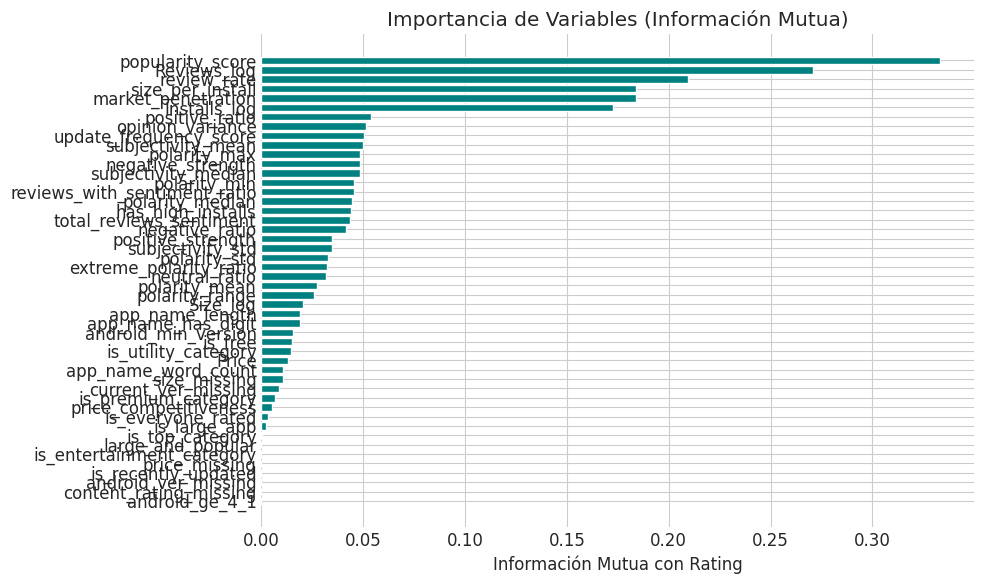


✓ Variables eliminadas por baja MI: 13

✓ Variables eliminadas por baja MI: 13

✓ Variables eliminadas por baja MI: 13

                     PASO 10: ANÁLISIS DE MULTICOLINEALIDAD                     

Pares de variables con alta correlación (|corr| > 0.8):
  • positive_ratio y neutral_ratio: -0.84
  • positive_ratio y polarity_mean: +0.90
  • negative_ratio y polarity_mean: -0.86
  • positive_ratio y polarity_median: +0.88
  • negative_ratio y polarity_median: -0.81
  • polarity_mean y polarity_median: +0.96
  • subjectivity_mean y subjectivity_median: +0.83
  • positive_ratio y positive_strength: +0.85
  • polarity_mean y positive_strength: +0.89
  • polarity_median y positive_strength: +0.85
  • polarity_max y positive_strength: +0.86
  • positive_strength y negative_strength: +0.80
  • polarity_std y opinion_variance: +0.97
  • polarity_mean y extreme_polarity_ratio: +0.86
  • polarity_median y extreme_polarity_ratio: +0.85
  • polarity_max y extreme_polarity_ratio: +0.80
  • posi

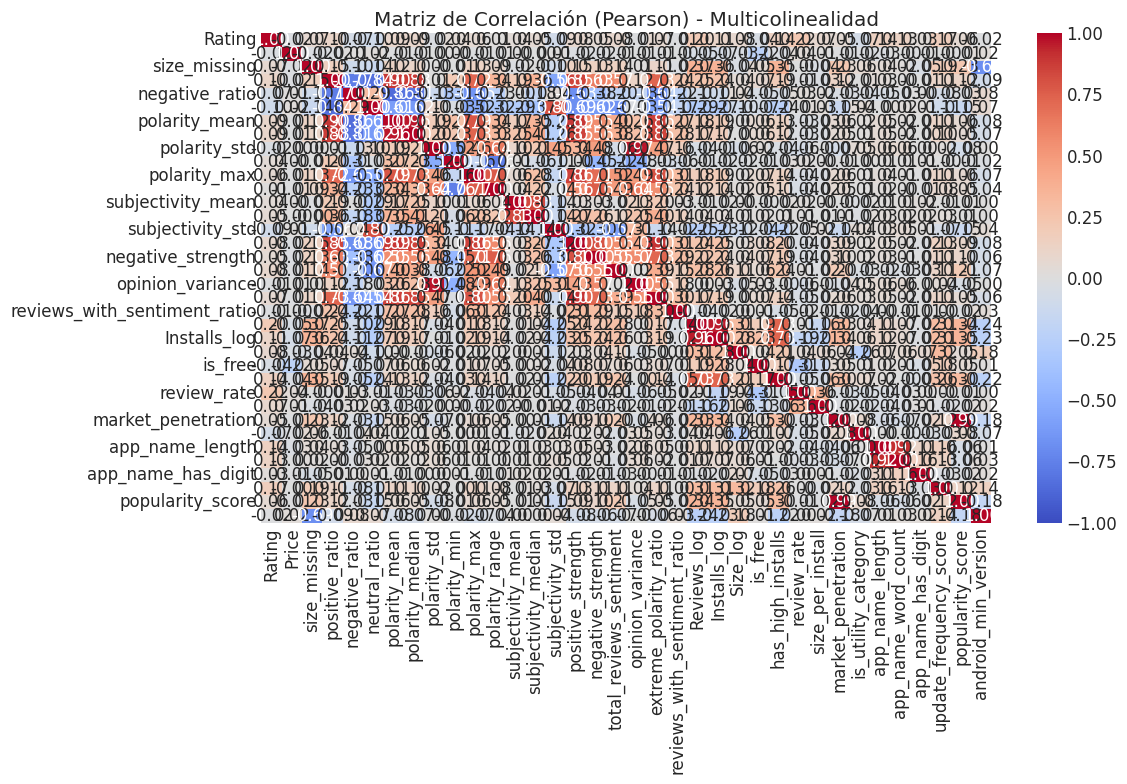


✓ Variables a eliminar por multicolinealidad: ['Installs_log']

✓ Variables eliminadas: ['Installs_log']
✓ Columnas restantes: 39

✓ Variables eliminadas: ['Installs_log']
✓ Columnas restantes: 39

✓ Variables eliminadas: ['Installs_log']
✓ Columnas restantes: 39

             RESUMEN INTERMEDIO: DATASET ANTES DE ONE-HOT ENCODING              

DIMENSIONES DE LOS CONJUNTOS

 Conjunto Registros  Columnas  Duplicados Memoria (MB)
   Train     6,221        39           0         2.80
     Val     1,334        39           0         0.60
    Test     1,333        39           0         0.60

LISTADO COMPLETO DE FEATURES

Total de features: 39
  • Variables numéricas: 35
  • Variables categóricas: 4

--------------------------------------------------------------------------------
VARIABLES NUMÉRICAS (35):
--------------------------------------------------------------------------------
    1. Rating                         | dtype: float64 | unique:     38 | missing: 0
    2. Price         

In [37]:
# ==============================================================================
# PASO 1: PREPARACIÓN DE DATOS
# ==============================================================================
print("\n[PASO 1/3] Preparación de datos...")
print("-" * 90)

# Verificar si ya existen datos procesados
train_path = OUTPUT_DIR / 'train_processed.csv'
val_path = OUTPUT_DIR / 'val_processed.csv'
test_path = OUTPUT_DIR / 'test_processed.csv'

if train_path.exists() and val_path.exists() and test_path.exists():
    print("✓ Datos procesados encontrados. Cargando desde disco...")
    train = pd.read_csv(train_path)
    val = pd.read_csv(val_path)
    test = pd.read_csv(test_path)
    print(f"   Train: {train.shape}")
    print(f"   Val:   {val.shape}")
    print(f"   Test:  {test.shape}")
else:
    print("⚠️  Datos procesados no encontrados. Ejecutando pipeline de preparación...")
    
    # Cargar datos originales
    print(f"\n  Cargando datos desde: {DATA_PATH}")
    df = pd.read_csv(DATA_PATH)
    print(f"  ✓ Datos cargados: {df.shape}")
    
    # Ejecutar pipeline de preparación
    print("\n  Ejecutando GooglePlayDataPreparationPipeline...")
    data_pipeline = GooglePlayDataPreparationPipeline(
        test_size=0.30,
        val_size=0.50,
        category_threshold=70,
        mi_threshold=0.01,
        corr_threshold=0.8,
        vars_to_remove=['Installs_log'],
        reference_date='2025-10-02',
        random_state=RANDOM_STATE,
        verbose=True,
        plot=True,
        reviews_sentiment_path=REVIEWS_SENTIMENT_PATH
    )
    
    train, val, test = data_pipeline.fit_transform(df)
    
    # Guardar datasets procesados
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    train.to_csv(train_path, index=False)
    val.to_csv(val_path, index=False)
    test.to_csv(test_path, index=False)
    print(f"\n  ✓ Datos guardados en {OUTPUT_DIR}")

## Paso 2: Preparar Features y Target

Separamos las features (X) del target (y) para cada conjunto de datos:

- **Features (X)**: Todas las columnas excepto 'Rating' y 'App'
- **Target (y)**: La columna 'Rating' que será transformada a clasificación binaria

Esta separación se realiza para train, validation y test.

In [38]:
# ==============================================================================
# PASO 2: PREPARAR FEATURES Y TARGET
# ==============================================================================
print("\n[PASO 2/3] Preparando features y target...")
print("-" * 90)

columns_to_drop = ['Rating', 'App']
X_train = train.drop(columns=[col for col in columns_to_drop if col in train.columns])
y_train = train['Rating']

X_val = val.drop(columns=[col for col in columns_to_drop if col in val.columns])
y_val = val['Rating']

X_test = test.drop(columns=[col for col in columns_to_drop if col in test.columns])
y_test = test['Rating']

print(f"✓ Features: {X_train.shape[1]}")
print(f"✓ Muestras: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")


[PASO 2/3] Preparando features y target...
------------------------------------------------------------------------------------------
✓ Features: 69
✓ Muestras: Train=6221, Val=1334, Test=1333


## Paso 3: Entrenar Modelos

Entrenamos múltiples familias de modelos de clasificación:

**Familias disponibles**:
- **Trees**: DecisionTree, RandomForest, ExtraTrees, GradientBoosting
- **Linear**: LogisticRegression, SGDClassifier
- **Boosting**: XGBoost, CatBoost

El pipeline realiza:
1. Transformación del target a clasificación binaria
2. Grid search con validación cruzada para cada modelo
3. Optimización de threshold de clasificación
4. Evaluación en conjunto de test
5. Generación de métricas y comparación de modelos

In [39]:
# ==============================================================================
# PASO 3: ENTRENAR MODELOS
# ==============================================================================
print("\n[PASO 3/3] Entrenando modelos...")
print("-" * 90)

start_time = time.time()

# Crear y entrenar pipeline de clasificación
classification_pipeline = ClassificationTrainingPipeline(
    n_bins=N_BINS,
    binning_strategy=BINNING_STRATEGY,
    custom_bins=CUSTOM_BINS,
    custom_labels=CUSTOM_LABELS,
    cv_folds=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=True,
    families=FAMILIES_TO_TRAIN
)

classification_pipeline.fit(X_train, y_train, X_val, y_val, X_test, y_test)
training_time = time.time() - start_time

print(f"\n✓ Entrenamiento completado en {training_time:.2f}s ({training_time/60:.2f} min)")


[PASO 3/3] Entrenando modelos...
------------------------------------------------------------------------------------------

======================= CLASSIFICATION PIPELINE - INICIO =======================

Dimensiones de datos:
  Train: (6221, 69)
  Val:   (1334, 69)
  Test:  (1333, 69)
  CV Folds: 5
  Random State: 42
  Familias a entrenar: ['BOOSTING', 'TREES']

====================== TRANSFORMANDO TARGET A CATEGORÍAS =======================
\n================================================================================
                  TARGET TRANSFORMER: CONVERSIÓN A CATEGORÍAS                   
\nEstrategia: custom
Número de bins: 2

Bin edges calculados:
  Low: [0.000, 4.000)
  High: [4.000, 5.000)

Distribución de clases:
  High: 4483 (72.1%)
  Low: 1738 (27.9%)

Distribución de clases:
  High: 961 (72.0%)
  Low: 373 (28.0%)

Distribución de clases:
  High: 961 (72.1%)
  Low: 372 (27.9%)

✓ Distribución de clases validada (mínimo 1738 muestras por clase)

================

## Guardado de Resultados

Guardamos todos los resultados del entrenamiento:

- **Modelos entrenados**: Archivos pickle de cada modelo
- **Métricas**: CSV con comparación de todos los modelos
- **Matrices de confusión**: Visualizaciones para cada modelo
- **Reportes de clasificación**: Métricas detalladas por clase
- **Feature importance**: Para modelos basados en árboles

In [40]:
# ==============================================================================
# GUARDADO DE RESULTADOS
# ==============================================================================
print("\n" + "=" * 90)
print(" GUARDADO DE RESULTADOS ".center(90, "="))
print("=" * 90)

# Guardar resultados
results_dir = OUTPUT_DIR / 'classification'
results_dir.mkdir(parents=True, exist_ok=True)

classification_pipeline.save_results(output_dir=str(results_dir))


================================= GUARDADO DE RESULTADOS =================================

✓ Resultados guardados en: outputs/classification
  ├─ model_comparison_validation.csv
  ├─ model_comparison_test.csv
  ├─ confusion_matrix_best_model.csv
  └─ training_summary.txt
